In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
from matplotlib.colors import Normalize
from matplotlib.ticker import LogLocator, LogFormatter

In [7]:

columns = [
    "mode", "thread_num", "probe_size", "build_size", "selectivity", "payload_size",
    "probe_distribution", "build_side_hit_ratio", "build_key_pattern", "probe_key_pattern",
    "mat_strat", "queue_thr", "time"
]

# 读取文件并解析数据
data = []
# /home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/benchmark_time_0110_dropcache_copy.txt
with open('/home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/benchmark_time_0110_dropcache_copy.txt', 'r') as file:
    for line in file:
        # 将每行数据拆分为多个字段
        values = line.strip().split()
        # 将字段转换为适当的类型
        values = [int(values[0]), int(values[1]), int(values[2]), int(values[3]), float(values[4]),
                  int(values[5]), values[6], float(values[7]), values[8], values[9], values[10],
                  int(values[11]), float(values[12])]
        data.append(values)

# 将数据转换为 Pandas DataFrame
df = pd.DataFrame(data, columns=columns)

# 输出 DataFrame


In [4]:
#/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/benchmark_time_0129_dropcache.txt
# benchmark_time_0203_dropcache.txt

In [15]:
df.groupby(['probe_distribution','build_side_hit_ratio', 'build_key_pattern','probe_key_pattern'])["time"].min()

probe_distribution  build_side_hit_ratio  build_key_pattern  probe_key_pattern
uniform             0.1                   clustered          random               688.825
                                                             sorted               603.116
                    0.2                   clustered          random               600.603
                                                             sorted               511.770
                    0.4                   clustered          random               588.647
                                                             sorted               508.065
                    0.8                   clustered          random               486.655
                                                             sorted               403.711
                    1.0                   random             random               394.750
                                          sorted             sorted               343.919
zipfian             0

In [16]:
fil_mode = 1
fil_probe_distribution = 'uniform'
fil_build_side_hit_ratio = 1
fil_build_key_pattern = 'random'
fil_probe_key_pattern = 'random'

In [17]:
filtered_df = df[(df['mode'] == fil_mode) & 
                 (df['probe_distribution'] == fil_probe_distribution) & 
                 (df['build_side_hit_ratio'] == fil_build_side_hit_ratio) & 
                 (df['build_key_pattern'] == fil_build_key_pattern) & 
                 (df['probe_key_pattern'] == fil_probe_key_pattern)]
# 取不同 queue_thr 情况下 mat_strat=1 的最小 time
min_time_df = filtered_df[filtered_df['mat_strat'] == "1"].groupby(['build_size','selectivity', 'payload_size'])["time"].min().reset_index()
print(min_time_df)
# 根据 build_size 分块
build_size_groups = filtered_df['build_size'].unique()
build_size_groups = [20000,200000,2000000,4000000,10000000,18000000]


      build_size  selectivity  payload_size       time
0           2000       0.0001             4    467.996
1           2000       0.0001             8    455.745
2           2000       0.0001            10    454.826
3           2000       0.0001            11    473.376
4           2000       0.0001            20    435.679
...          ...          ...           ...        ...
1129    18000000       0.8000            61   8775.350
1130    18000000       0.8000            80   8783.610
1131    18000000       0.8000            81   9651.300
1132    18000000       0.8000           100   9936.810
1133    18000000       0.8000           101  10510.200

[1134 rows x 4 columns]


In [18]:
fil_mode = 1
fil_probe_distribution = 'uniform'
fil_build_side_hit_ratio = 1
fil_build_key_pattern = 'sorted'
fil_probe_key_pattern = 'sorted'

In [19]:
filtered_df2 = df[(df['mode'] == fil_mode) & 
                 (df['probe_distribution'] == fil_probe_distribution) & 
                 (df['build_side_hit_ratio'] == fil_build_side_hit_ratio) & 
                 (df['build_key_pattern'] == fil_build_key_pattern) & 
                 (df['probe_key_pattern'] == fil_probe_key_pattern)& 
(df['build_size'] !=20000) &
(df['build_size'] !=200000) &
(df['build_size'] !=2000000) 
]
# 取不同 queue_thr 情况下 mat_strat=1 的最小 time
min_time_df2 = filtered_df2[filtered_df2['mat_strat'] == "1"].groupby(['build_size','selectivity', 'payload_size'])["time"].min().reset_index()
print(min_time_df2)
# 根据 build_size 分块
build_size_groups = filtered_df['build_size'].unique()
build_size_groups = [20000,200000,2000000,4000000,10000000,18000000]


     build_size  selectivity  payload_size      time
0          2000       0.0001             4   434.197
1          2000       0.0001             8   419.697
2          2000       0.0001            10   411.818
3          2000       0.0001            11   418.283
4          2000       0.0001            20   411.427
..          ...          ...           ...       ...
751    18000000       0.8000            61  5959.790
752    18000000       0.8000            80  7056.960
753    18000000       0.8000            81  6578.510
754    18000000       0.8000           100  8035.160
755    18000000       0.8000           101  7444.340

[756 rows x 4 columns]


/tmp/ipykernel_1486181/179958930.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


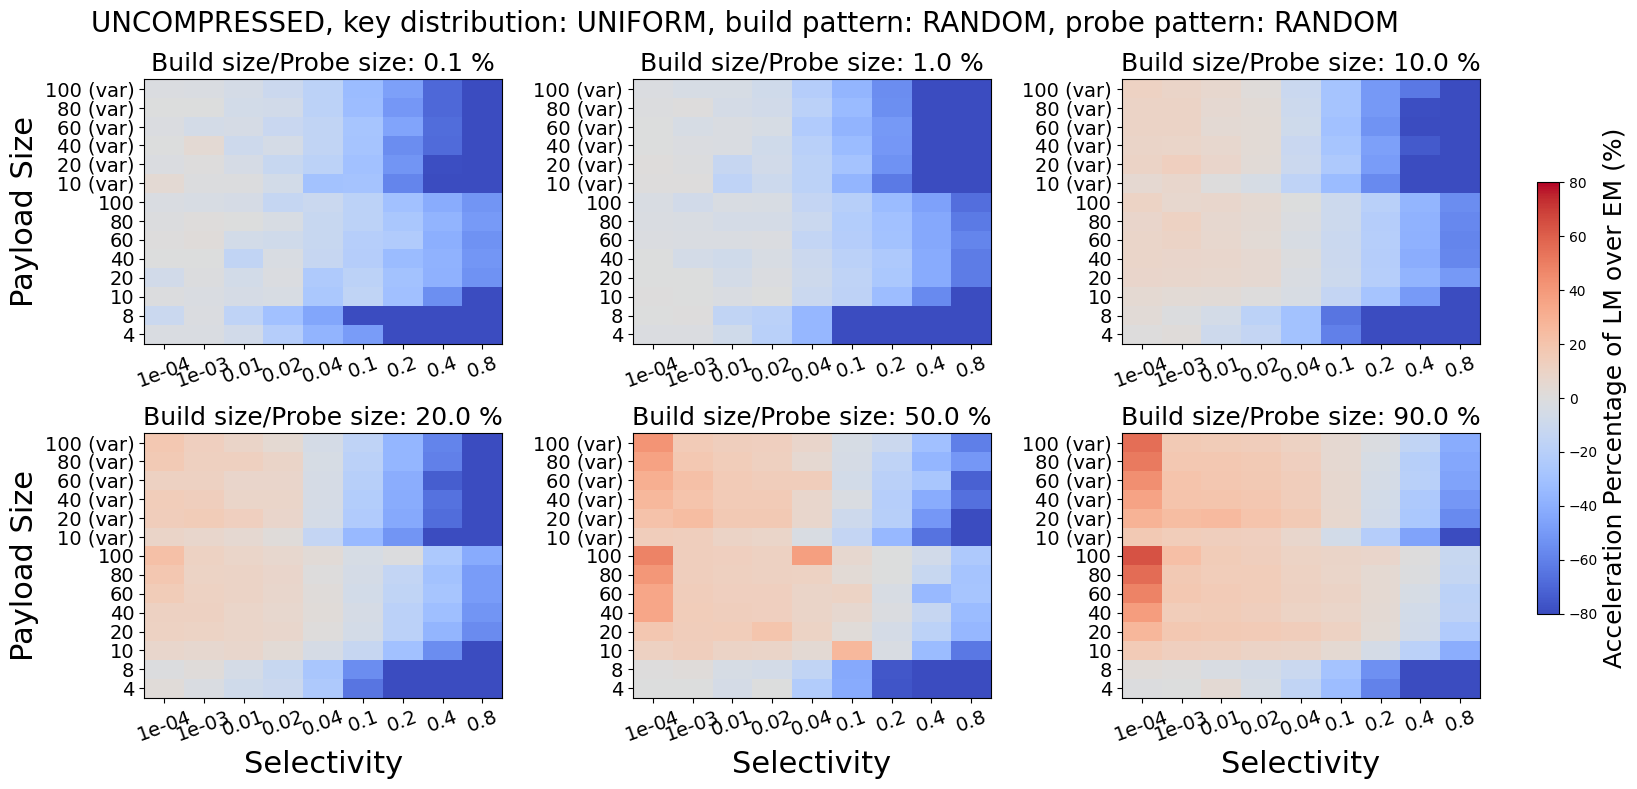

In [13]:

# 创建一个包含多个子图的图形，排成三列
num_plots = len(build_size_groups)
num_cols = 3
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows))


for idx, build_size in enumerate(build_size_groups):
    row = idx // num_cols
    col = idx % num_cols
    ax = axes[row, col] if num_rows > 1 else axes[col]
    # only fixed length string 
    group_df = filtered_df[filtered_df['build_size'] == build_size]

    # 创建一个 NxM 的格子
    selectivities = group_df['selectivity'].unique()
    payload_sizes = group_df['payload_size'].unique()
    selectivities.sort()
    payload_sizes.sort()
    payload_sizes_new = []
    payload_number = []
    for i, payload_size in enumerate(payload_sizes):
        if payload_size<=10 or payload_size%10==0:
            payload_sizes_new.append(payload_size)
            payload_number.append(str(payload_size))
    for i, payload_size in enumerate(payload_sizes):
        if payload_size>10 and payload_size%10!=0:
            tmp_size = (payload_size//10)*10
            payload_sizes_new.append(payload_size)
            payload_number.append(str(tmp_size)+" (var)")
    payload_sizes = payload_sizes_new
    label = []
    for i, selectivity in enumerate(selectivities):
        if selectivity<0.01:
            label.append(str(format(selectivity, ".0e")))
        else:
            label.append(str(selectivity))

    # 创建颜色矩阵
    color_matrix = np.zeros((len(payload_sizes), len(selectivities)))

    for i, payload_size in enumerate(payload_sizes):
        for j, selectivity in enumerate(selectivities):
            time_1 = min_time_df[(min_time_df['selectivity'] == selectivity) & 
                                 (min_time_df['payload_size'] == payload_size) & (min_time_df['build_size'] == build_size)]['time'].min()
            time_0 = group_df[(group_df['selectivity'] == selectivity) & 
                              (group_df['payload_size'] == payload_size) & 
                              (group_df['mat_strat'] == "0")]['time'].min()
            if pd.notna(time_1) and pd.notna(time_0):
                color_matrix[i, j] = (time_0-time_1)/time_0 * 100
                # print(selectivities[j], payload_sizes[i], color_matrix[i, j])

    # 绘制颜色矩阵
    norm = Normalize(vmin=-80, vmax=80)
    c = ax.pcolormesh(label, payload_number, color_matrix, cmap='coolwarm', shading='auto',norm=norm)
    ax.tick_params(axis='x', labelsize=14,rotation=20)
    ax.tick_params(axis='y', labelsize=14)


    if col==0:
        ax.set_ylabel('Payload Size',fontsize=22)
    if row == (num_plots//num_cols -1):
        ax.set_xlabel('Selectivity',fontsize=22)

    ax.set_title(f'Build size/Probe size: {build_size/200000} %',fontsize=18)


cbar = fig.colorbar(c, ax=axes, orientation='vertical',anchor=(2.4,0.5), shrink=0.7)
cbar.set_label('Acceleration Percentage of LM over EM (%)',fontsize=18)
for idx in range(num_plots, num_rows * num_cols):
    fig.delaxes(axes.flatten()[idx])
    
title = f'key distribution: {fil_probe_distribution.upper()}, build pattern: {fil_build_key_pattern.upper()}, probe pattern: {fil_probe_key_pattern.upper()}'
fig_name =  f'{fil_probe_distribution.upper()}_{fil_build_key_pattern.upper()}_{fil_probe_key_pattern.upper()}'

if fil_build_side_hit_ratio!=1:
    title+=f' build hit ratio: {fil_build_side_hit_ratio}'
    fig_name+=f'_{fil_build_side_hit_ratio}'
if fil_mode==1:
    title = 'UNCOMPRESSED, '+title
    fig_name = 'UNCOMPRESSED_'+fig_name
else:
    title = 'COMPRESSED, '+title
    fig_name = 'COMPRESSED_'+fig_name

fig.suptitle(title, fontsize=20)
plt.tight_layout()
plt.savefig(f"/home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/benchmark/paper_figure/micro/{fig_name}.pdf",bbox_inches='tight')
plt.show()


## uniform v.s. sorted row ID

/tmp/ipykernel_1486181/3979744306.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


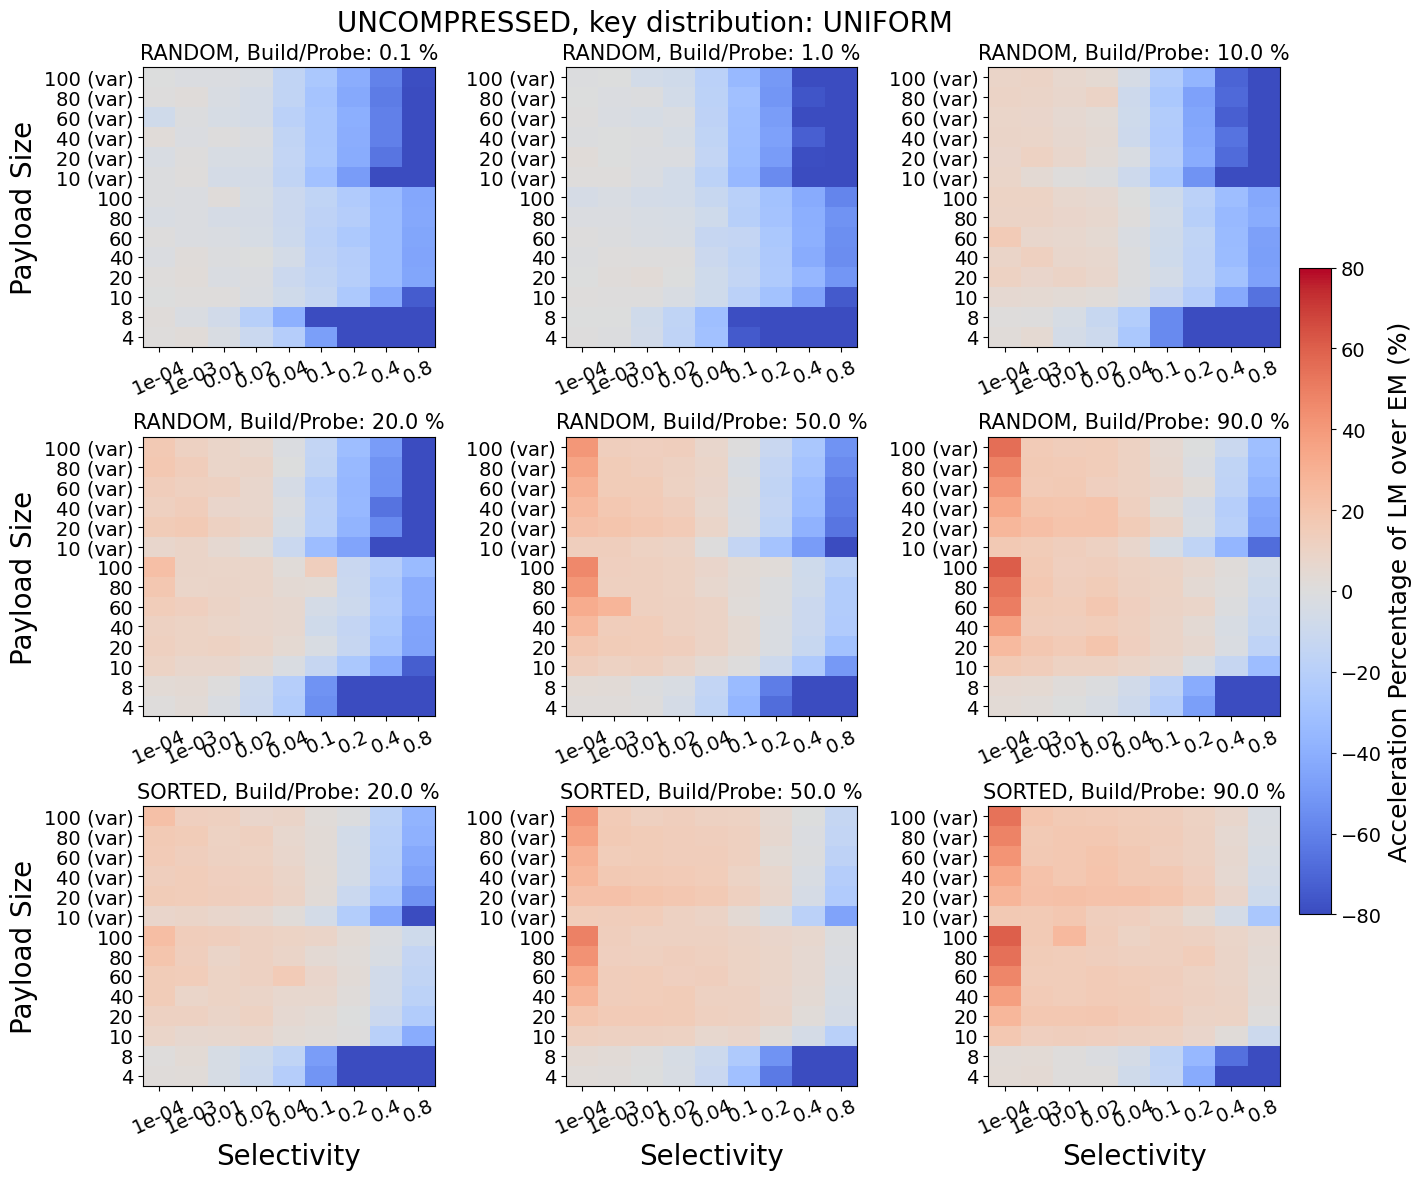

In [20]:

# 创建一个包含多个子图的图形，排成三列
num_plots = 9
num_cols = 3
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(13, 4 * num_rows))

build_size_groups = [20000,200000,2000000,4000000,10000000,18000000]
for idx, build_size in enumerate(build_size_groups):
    row = idx // num_cols
    col = idx % num_cols
    ax = axes[row, col] if num_rows > 1 else axes[col]
    # only fixed length string 
    group_df = filtered_df[filtered_df['build_size'] == build_size]

    # 创建一个 NxM 的格子
    selectivities = group_df['selectivity'].unique()
    payload_sizes = group_df['payload_size'].unique()
    selectivities.sort()
    payload_sizes.sort()
    payload_sizes_new = []
    payload_number = []
    for i, payload_size in enumerate(payload_sizes):
        if payload_size<=10 or payload_size%10==0:
            payload_sizes_new.append(payload_size)
            payload_number.append(str(payload_size))
    for i, payload_size in enumerate(payload_sizes):
        if payload_size>10 and payload_size%10!=0:
            tmp_size = (payload_size//10)*10
            payload_sizes_new.append(payload_size)
            payload_number.append(str(tmp_size)+" (var)")
    payload_sizes = payload_sizes_new
    label = []
    for i, selectivity in enumerate(selectivities):
        if selectivity<0.01:
            label.append(str(format(selectivity, ".0e")))
        else:
            label.append(str(selectivity))

    # 创建颜色矩阵
    color_matrix = np.zeros((len(payload_sizes), len(selectivities)))

    for i, payload_size in enumerate(payload_sizes):
        for j, selectivity in enumerate(selectivities):
            time_1 = min_time_df[(min_time_df['selectivity'] == selectivity) & 
                                 (min_time_df['payload_size'] == payload_size) & (min_time_df['build_size'] == build_size)]['time'].min()
            time_0 = group_df[(group_df['selectivity'] == selectivity) & 
                              (group_df['payload_size'] == payload_size) & 
                              (group_df['mat_strat'] == "0")]['time'].min()
            if pd.notna(time_1) and pd.notna(time_0):
                color_matrix[i, j] = (time_0-time_1)/time_0 * 100
                # print(selectivities[j], payload_sizes[i], color_matrix[i, j])

    # 绘制颜色矩阵
    norm = Normalize(vmin=-80, vmax=80)
    c = ax.pcolormesh(label, payload_number, color_matrix, cmap='coolwarm', shading='auto',norm=norm)
    ax.tick_params(axis='x', labelsize=14,rotation=25)
    ax.tick_params(axis='y', labelsize=14)

    if col==0:
        ax.set_ylabel('Payload Size',fontsize=20)
    # if row == (num_plots//num_cols -1):
    #     ax.set_xlabel('Selectivity',fontsize=20)

    ax.set_title(f'RANDOM, Build/Probe: {build_size/200000} %',fontsize=15)

build_size_groups = [4000000,10000000,18000000]
for idx, build_size in enumerate(build_size_groups):
    row = 2
    col = idx % num_cols
    ax = axes[row, col] if num_rows > 1 else axes[col]
    # only fixed length string 
    group_df = filtered_df2[filtered_df2['build_size'] == build_size]

    # 创建一个 NxM 的格子
    selectivities = group_df['selectivity'].unique()
    payload_sizes = group_df['payload_size'].unique()
    selectivities.sort()
    payload_sizes.sort()
    payload_sizes_new = []
    payload_number = []
    for i, payload_size in enumerate(payload_sizes):
        if payload_size<=10 or payload_size%10==0:
            payload_sizes_new.append(payload_size)
            payload_number.append(str(payload_size))
    for i, payload_size in enumerate(payload_sizes):
        if payload_size>10 and payload_size%10!=0:
            tmp_size = (payload_size//10)*10
            payload_sizes_new.append(payload_size)
            payload_number.append(str(tmp_size)+" (var)")
    payload_sizes = payload_sizes_new
    label = []
    for i, selectivity in enumerate(selectivities):
        if selectivity<0.01:
            label.append(str(format(selectivity, ".0e")))
        else:
            label.append(str(selectivity))

    # 创建颜色矩阵
    color_matrix = np.zeros((len(payload_sizes), len(selectivities)))

    for i, payload_size in enumerate(payload_sizes):
        for j, selectivity in enumerate(selectivities):
            time_1 = min_time_df2[(min_time_df2['selectivity'] == selectivity) & 
                                 (min_time_df2['payload_size'] == payload_size) & (min_time_df2['build_size'] == build_size)]['time'].min()
            time_0 = group_df[(group_df['selectivity'] == selectivity) & 
                              (group_df['payload_size'] == payload_size) & 
                              (group_df['mat_strat'] == "0")]['time'].min()
            if pd.notna(time_1) and pd.notna(time_0):
                color_matrix[i, j] = (time_0-time_1)/time_0 * 100
                
    norm = Normalize(vmin=-80, vmax=80)
    c = ax.pcolormesh(label, payload_number, color_matrix, cmap='coolwarm', shading='auto',norm=norm)
    ax.tick_params(axis='x', labelsize=14,rotation=25)
    ax.tick_params(axis='y', labelsize=14)

    ax.set_xlabel('Selectivity',fontsize=20)
    if col==0:
        ax.set_ylabel('Payload Size',fontsize=20)

    ax.set_title(f'SORTED, Build/Probe: {build_size/200000} %',fontsize=15)


cbar = fig.colorbar(c, ax=axes, orientation='vertical',anchor=(2.4,0.5), shrink=0.7)
cbar.set_label('Acceleration Percentage of LM over EM (%)',fontsize=18)
cbar.ax.tick_params(labelsize=14)  # 这里设置刻度字体大小为14

for idx in range(num_plots, num_rows * num_cols):
    fig.delaxes(axes.flatten()[idx])
    
title = f'key distribution: {fil_probe_distribution.upper()}'
fig_name =  f'{fil_probe_distribution.upper()}_'

if fil_build_side_hit_ratio!=1:
    title+=f' build hit ratio: {fil_build_side_hit_ratio}'
    fig_name+=f'_{fil_build_side_hit_ratio}'
if fil_mode==1:
    title = 'UNCOMPRESSED, '+title
    fig_name = 'UNCOMPRESSED_'+fig_name
else:
    title = 'COMPRESSED, '+title
    fig_name = 'COMPRESSED_'+fig_name
# title = 'UNCOMPRESSED, UNIFORM sort row ID'
fig.suptitle(title, fontsize=20)
plt.tight_layout()
plt.savefig(f"/home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/benchmark/paper_figure/micro/{fig_name}.pdf",bbox_inches='tight')
plt.show()


## zipfian, clustered (fix build/probe)

In [180]:
fil_mode = 1
fil_probe_distribution = 'zipfian'
fil_build_side_hit_ratio = 1
fil_build_key_pattern = 'random'
fil_probe_key_pattern = 'random'
build_size = 10000000

In [181]:
filtered_df = df[(df['mode'] == fil_mode) & 
                (df['build_side_hit_ratio'] == fil_build_side_hit_ratio) & 
                 (df['probe_distribution'] == fil_probe_distribution) & 
                 (df['build_key_pattern'] == fil_build_key_pattern) & 
                 (df['probe_key_pattern'] == fil_probe_key_pattern)& 
                (df['build_size'] == build_size)
]
# 取不同 queue_thr 情况下 mat_strat=1 的最小 time
min_time_df = filtered_df[filtered_df['mat_strat'] == "1"].groupby(['build_size','selectivity', 'payload_size'])["time"].min().reset_index()
print(min_time_df)



     build_size  selectivity  payload_size     time
0      10000000       0.0001             4  1229.94
1      10000000       0.0001             8  1226.68
2      10000000       0.0001            10  1237.20
3      10000000       0.0001            11  1240.41
4      10000000       0.0001            20  1237.89
..          ...          ...           ...      ...
121    10000000       0.8000            61  4291.63
122    10000000       0.8000            80  4586.63
123    10000000       0.8000            81  4713.88
124    10000000       0.8000           100  4889.39
125    10000000       0.8000           101  5088.70

[126 rows x 4 columns]


In [182]:
fil_mode = 1
fil_probe_distribution = 'zipfian'
fil_build_key_pattern = 'clustered'
fil_probe_key_pattern = 'random'
build_size = 10000000

In [183]:
filtered_df2 = df[(df['mode'] == fil_mode) & 
                 (df['probe_distribution'] == fil_probe_distribution) & 
                 (df['build_key_pattern'] == fil_build_key_pattern) & 
                 (df['probe_key_pattern'] == fil_probe_key_pattern)& 
                (df['build_size'] == build_size)
]
# 取不同 queue_thr 情况下 mat_strat=1 的最小 time
min_time_df2 = filtered_df2[filtered_df2['mat_strat'] == "1"].groupby(['build_side_hit_ratio','selectivity', 'payload_size'])["time"].min().reset_index()
print(min_time_df2)

build_hit_ratios = filtered_df2['build_side_hit_ratio'].unique()
build_hit_ratios = [0.8,0.4,0.1]

     build_side_hit_ratio  selectivity  payload_size     time
0                     0.1       0.0001             4  1215.79
1                     0.1       0.0001             8  1224.84
2                     0.1       0.0001            10  1228.76
3                     0.1       0.0001            11  1237.18
4                     0.1       0.0001            20  1236.49
..                    ...          ...           ...      ...
499                   0.8       0.8000            61  3974.75
500                   0.8       0.8000            80  4220.89
501                   0.8       0.8000            81  4366.34
502                   0.8       0.8000           100  4578.89
503                   0.8       0.8000           101  4692.44

[504 rows x 4 columns]


/tmp/ipykernel_3154790/836819542.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


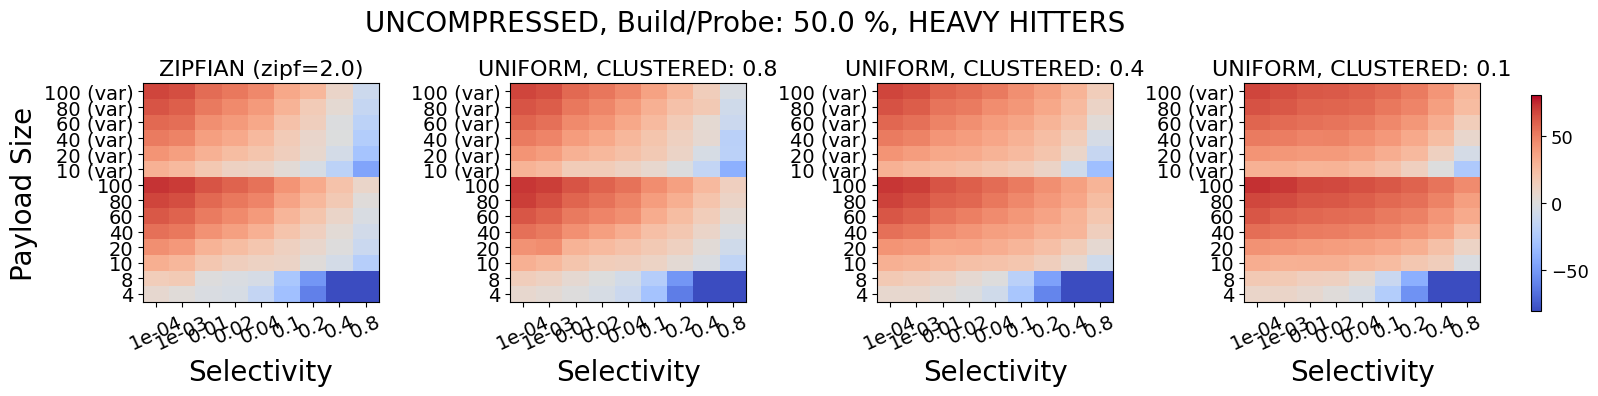

In [187]:

# 创建一个包含多个子图的图形，排成三列
num_plots = 4
num_cols = 4
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows))

hit_ratio = [1]
for idx, hit in enumerate(hit_ratio):
    row = idx // num_cols
    col = idx % num_cols
    ax = axes[row, col] if num_rows > 1 else axes[col]
    # only fixed length string 
    group_df = filtered_df

    selectivities = group_df['selectivity'].unique()
    payload_sizes = group_df['payload_size'].unique()
    selectivities.sort()
    payload_sizes.sort()
    payload_sizes_new = []
    payload_number = []
    for i, payload_size in enumerate(payload_sizes):
        if payload_size<=10 or payload_size%10==0:
            payload_sizes_new.append(payload_size)
            payload_number.append(str(payload_size))
    for i, payload_size in enumerate(payload_sizes):
        if payload_size>10 and payload_size%10!=0:
            tmp_size = (payload_size//10)*10
            payload_sizes_new.append(payload_size)
            payload_number.append(str(tmp_size)+" (var)")
    payload_sizes = payload_sizes_new
    label = []
    for i, selectivity in enumerate(selectivities):
        if selectivity<0.01:
            label.append(str(format(selectivity, ".0e")))
        else:
            label.append(str(selectivity))

    # 创建颜色矩阵
    color_matrix = np.zeros((len(payload_sizes), len(selectivities)))

    for i, payload_size in enumerate(payload_sizes):
        for j, selectivity in enumerate(selectivities):
            time_1 = min_time_df[(min_time_df['selectivity'] == selectivity) & 
                                 (min_time_df['payload_size'] == payload_size)]['time'].min()
            time_0 = group_df[(group_df['selectivity'] == selectivity) & 
                              (group_df['payload_size'] == payload_size) & 
                              (group_df['mat_strat'] == "0")]['time'].min()
            if pd.notna(time_1) and pd.notna(time_0):
                color_matrix[i, j] = (time_0-time_1)/time_0 * 100
                # print(selectivities[j], payload_sizes[i], color_matrix[i, j])

    # 绘制颜色矩阵
    norm = Normalize(vmin=-80, vmax=80)
    c = ax.pcolormesh(label, payload_number, color_matrix, cmap='coolwarm', shading='auto',norm=norm)
    ax.tick_params(axis='x', labelsize=14,rotation=25)
    ax.tick_params(axis='y', labelsize=14)

    if col==0:
        ax.set_ylabel('Payload Size',fontsize=20)
    ax.set_xlabel('Selectivity',fontsize=20)
    # if row == (num_plots//num_cols -1):
    #     ax.set_xlabel('Selectivity',fontsize=20)

    ax.set_title(f'ZIPFIAN (zipf=2.0)',fontsize=16)

build_hit_ratios = [0.8,0.4,0.1]
for idx, build_hit in enumerate(build_hit_ratios):
    col = idx % num_cols+1
    ax = axes[col]
    # only fixed length string 
    group_df = filtered_df2[filtered_df2['build_side_hit_ratio'] == build_hit]

    # 创建一个 NxM 的格子
    selectivities = group_df['selectivity'].unique()
    payload_sizes = group_df['payload_size'].unique()
    selectivities.sort()
    payload_sizes.sort()
    payload_sizes_new = []
    payload_number = []
    for i, payload_size in enumerate(payload_sizes):
        if payload_size<=10 or payload_size%10==0:
            payload_sizes_new.append(payload_size)
            payload_number.append(str(payload_size))
    for i, payload_size in enumerate(payload_sizes):
        if payload_size>10 and payload_size%10!=0:
            tmp_size = (payload_size//10)*10
            payload_sizes_new.append(payload_size)
            payload_number.append(str(tmp_size)+" (var)")
    payload_sizes = payload_sizes_new
    label = []
    for i, selectivity in enumerate(selectivities):
        if selectivity<0.01:
            label.append(str(format(selectivity, ".0e")))
        else:
            label.append(str(selectivity))

    # 创建颜色矩阵
    color_matrix = np.zeros((len(payload_sizes), len(selectivities)))

    for i, payload_size in enumerate(payload_sizes):
        for j, selectivity in enumerate(selectivities):
            time_1 = min_time_df2[(min_time_df2['selectivity'] == selectivity) & 
                                 (min_time_df2['payload_size'] == payload_size) & (min_time_df2['build_side_hit_ratio'] == build_hit)]['time'].min()
            time_0 = group_df[(group_df['selectivity'] == selectivity) & 
                              (group_df['payload_size'] == payload_size) & 
                              (group_df['mat_strat'] == "0")]['time'].min()
            if pd.notna(time_1) and pd.notna(time_0):
                color_matrix[i, j] = (time_0-time_1)/time_0 * 100
                
    norm = Normalize(vmin=-80, vmax=80)
    c = ax.pcolormesh(label, payload_number, color_matrix, cmap='coolwarm', shading='auto',norm=norm)
    ax.tick_params(axis='x', labelsize=14,rotation=25)
    ax.tick_params(axis='y', labelsize=14)

    ax.set_xlabel('Selectivity',fontsize=20)
    if col==0:
        ax.set_ylabel('Payload Size',fontsize=20)

    ax.set_title(f'UNIFORM, CLUSTERED: {build_hit}',fontsize=16)


cbar = fig.colorbar(c, ax=axes, orientation='vertical',anchor=(2.2,0.5), shrink=0.7)
# cbar.set_label('Acceleration Percentage of LM over EM (%)',fontsize=15)
cbar.ax.tick_params(labelsize=13) 

for idx in range(num_plots, num_rows * num_cols):
    fig.delaxes(axes.flatten()[idx])
    
title = f'Build/Probe: {build_size/200000} %, HEAVY HITTERS'
fig_name =  f'heavy_hitter_'

if fil_build_side_hit_ratio!=1:
    title+=f' build hit ratio: {fil_build_side_hit_ratio}'
    fig_name+=f'_{fil_build_side_hit_ratio}'
if fil_mode==1:
    title = 'UNCOMPRESSED, '+title
    fig_name = 'UNCOMPRESSED_'+fig_name
else:
    title = 'COMPRESSED, '+title
    fig_name = 'COMPRESSED_'+fig_name
# title = 'UNCOMPRESSED, UNIFORM sort row ID'
fig.suptitle(title, fontsize=20)
plt.tight_layout()
plt.savefig(f"/home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/benchmark/paper_figure/micro/{fig_name}.pdf",bbox_inches='tight')
plt.show()


# multi thread

In [8]:

columns = [
    "mode", "thread_num", "probe_size", "build_size", "selectivity", "payload_size",
    "probe_distribution", "build_side_hit_ratio", "build_key_pattern", "probe_key_pattern",
    "mat_strat", "queue_thr", "time"
]

# 读取文件并解析数据
data = []
with open('/home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/benchmark_time_multithread_dropcache.txt', 'r') as file:
    for line in file:
        # 将每行数据拆分为多个字段
        values = line.strip().split()
        # 将字段转换为适当的类型
        values = [int(values[0]), int(values[1]), int(values[2]), int(values[3]), float(values[4]),
                  int(values[5]), values[6], float(values[7]), values[8], values[9], values[10],
                  int(values[11]), float(values[12])]
        data.append(values)

# 将数据转换为 Pandas DataFrame
df_mul = pd.DataFrame(data, columns=columns)


df_total = pd.concat([df, df_mul])
df_total=df_mul

In [9]:
df_mul.groupby(['probe_distribution','build_side_hit_ratio', 'build_key_pattern','probe_key_pattern'])["time"].min()

probe_distribution  build_side_hit_ratio  build_key_pattern  probe_key_pattern
uniform             1.0                   random             random               0.129883
                                          sorted             sorted               0.130127
Name: time, dtype: float64

In [10]:
fil_mode = 1
fil_probe_distribution = 'uniform'
fil_build_side_hit_ratio = 1
fil_build_key_pattern = 'random'
fil_probe_key_pattern = 'random'
fil_build_size = 18000000

In [11]:
filtered_df = df_total[(df_total['mode'] == fil_mode) & 
                 (df_total['probe_distribution'] == fil_probe_distribution) & 
                 (df_total['build_side_hit_ratio'] == fil_build_side_hit_ratio) & 
                 (df_total['build_key_pattern'] == fil_build_key_pattern) & 
                 (df_total['probe_key_pattern'] == fil_probe_key_pattern) &
(df_total['build_size'] == fil_build_size)
]

min_time_df = filtered_df[filtered_df['mat_strat'] == "1"].groupby(['thread_num','build_size','selectivity', 'payload_size'])["time"].min().reset_index()
print(min_time_df)
threadnum_groups = filtered_df['thread_num'].unique()
print(threadnum_groups)

     thread_num  build_size  selectivity  payload_size     time
0             1    18000000       0.0001             4  1943.14
1             1    18000000       0.0001             8  2111.45
2             1    18000000       0.0001            10  2370.70
3             1    18000000       0.0001            11  2282.81
4             1    18000000       0.0001            20  2626.70
..          ...         ...          ...           ...      ...
625          16    18000000       0.8000            61  1870.78
626          16    18000000       0.8000            80  1961.17
627          16    18000000       0.8000            81  2395.51
628          16    18000000       0.8000           100  2419.53
629          16    18000000       0.8000           101  2370.17

[630 rows x 5 columns]
[ 1  2  4  8 16]


/tmp/ipykernel_1824283/1087241045.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


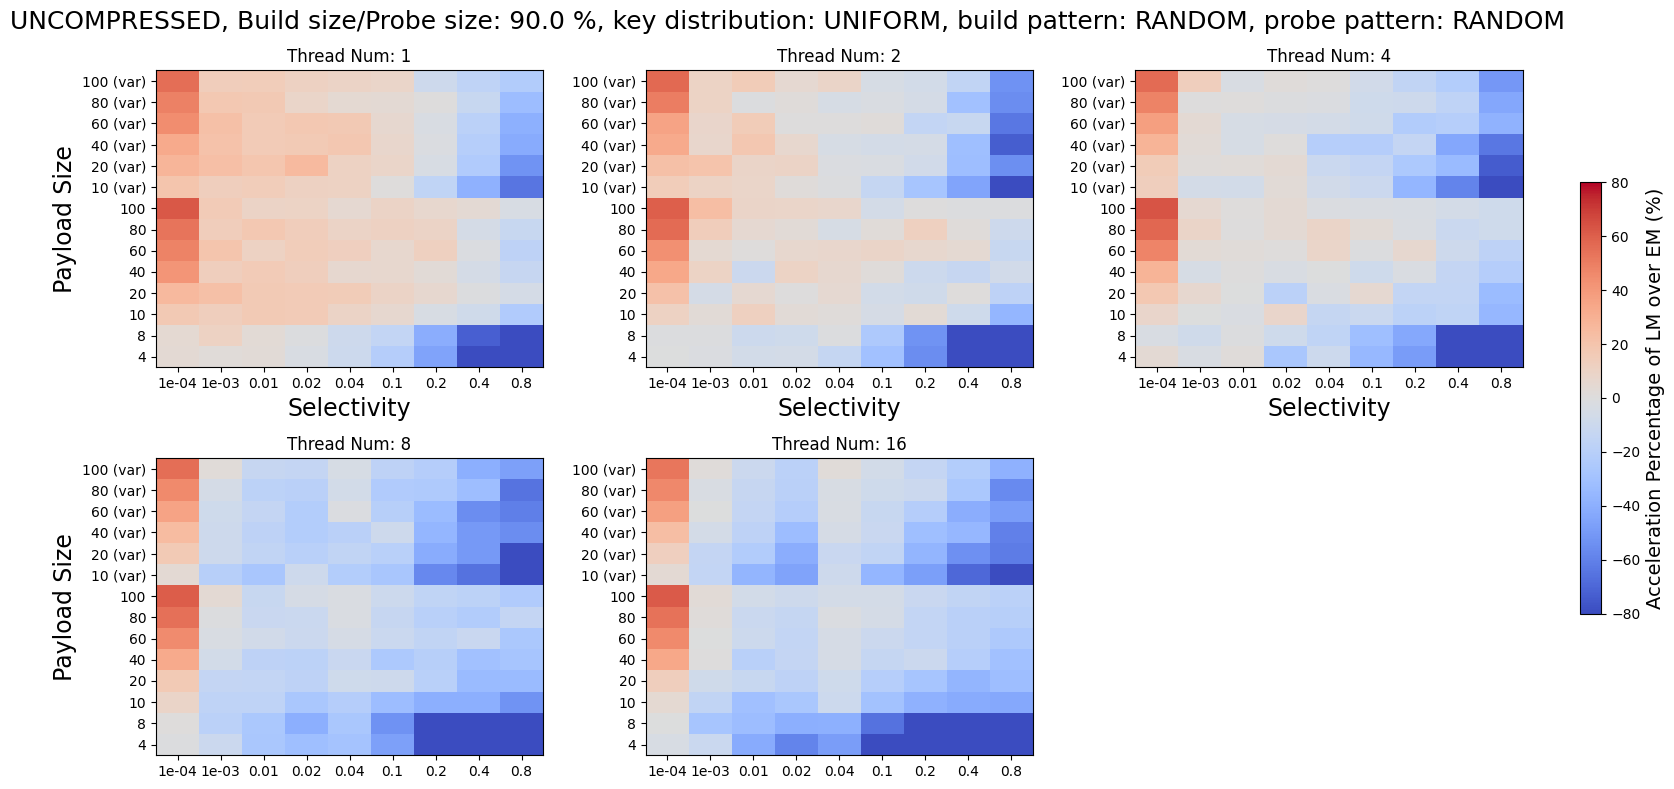

In [12]:

# 创建一个包含多个子图的图形，排成三列
num_plots = len(threadnum_groups)
num_cols = 3
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows))


for idx, thread_num in enumerate(threadnum_groups):
    row = idx // num_cols
    col = idx % num_cols
    ax = axes[row, col] if num_rows > 1 else axes[col]
    # only fixed length string 
    group_df = filtered_df[filtered_df['thread_num'] == thread_num]
    selectivities = group_df['selectivity'].unique()
    payload_sizes = group_df['payload_size'].unique()
    selectivities.sort()
    payload_sizes.sort()
    payload_sizes_new = []
    payload_number = []
    for i, payload_size in enumerate(payload_sizes):
        if payload_size<=10 or payload_size%10==0:
            payload_sizes_new.append(payload_size)
            payload_number.append(str(payload_size))
    for i, payload_size in enumerate(payload_sizes):
        if payload_size>10 and payload_size%10!=0:
            tmp_size = (payload_size//10)*10
            payload_sizes_new.append(payload_size)
            payload_number.append(str(tmp_size)+" (var)")
    payload_sizes = payload_sizes_new
    label = []
    for i, selectivity in enumerate(selectivities):
        if selectivity<0.01:
            label.append(str(format(selectivity, ".0e")))
        else:
            label.append(str(selectivity))

    # 创建颜色矩阵
    color_matrix = np.zeros((len(payload_sizes), len(selectivities)))

    for i, payload_size in enumerate(payload_sizes):
        for j, selectivity in enumerate(selectivities):
            time_1 = min_time_df[(min_time_df['selectivity'] == selectivity) & 
                                 (min_time_df['payload_size'] == payload_size) & (min_time_df['thread_num'] == thread_num)]['time'].min()
            time_0 = group_df[(group_df['selectivity'] == selectivity) & 
                              (group_df['payload_size'] == payload_size) & 
                              (group_df['mat_strat'] == "0")]['time'].min()
            if pd.notna(time_1) and pd.notna(time_0):
                color_matrix[i, j] = (time_0-time_1)/time_0 * 100
                # print(selectivities[j], payload_sizes[i], color_matrix[i, j])

    # 绘制颜色矩阵
    norm = Normalize(vmin=-80, vmax=80)
    c = ax.pcolormesh(label, payload_number, color_matrix, cmap='coolwarm', shading='auto',norm=norm)

    if col==0:
        ax.set_ylabel('Payload Size',fontsize=17)
    if row == (num_plots//num_cols -1):
        ax.set_xlabel('Selectivity',fontsize=17)

    ax.set_title(f'Thread Num: {thread_num}')



cbar = fig.colorbar(c, ax=axes, orientation='vertical',anchor=(2.4,0.5), shrink=0.7)
cbar.set_label('Acceleration Percentage of LM over EM (%)',fontsize=14)
for idx in range(num_plots, num_rows * num_cols):
    fig.delaxes(axes.flatten()[idx])
    
title = f'Build size/Probe size: {fil_build_size/200000} %, key distribution: {fil_probe_distribution.upper()}, build pattern: {fil_build_key_pattern.upper()}, probe pattern: {fil_probe_key_pattern.upper()}'
if fil_build_side_hit_ratio!=1:
    title+=f' build hit ratio: {fil_build_side_hit_ratio}'
if fil_mode==1:
    title = 'UNCOMPRESSED, '+title
else:
    title = 'COMPRESSED, '+title

fig.suptitle(title, fontsize=18)
plt.tight_layout()
plt.show()

# multi columns

In [5]:

columns = [
    "mode", "thread_num", "probe_size", "build_size", "selectivity", "payload_size",
    "probe_distribution", "build_side_hit_ratio", "build_key_pattern", "probe_key_pattern",
    "mat_strat", "queue_thr", "column_num", "time"
]

# 读取文件并解析数据
data = []
with open('/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/benchmark_multicol_dropcache.txt', 'r') as file:
    for line in file:
        # 将每行数据拆分为多个字段
        values = line.strip().split()
        # 将字段转换为适当的类型
        values = [int(values[0]), int(values[1]), int(values[2]), int(values[3]), float(values[4]),
                  int(values[5]), values[6], float(values[7]), values[8], values[9], values[10],
                  int(values[11]), int(values[12]),float(values[13])]
        data.append(values)

# 将数据转换为 Pandas DataFrame
df_mul = pd.DataFrame(data, columns=columns)


df_total = pd.concat([df, df_mul])
df_total=df_mul

In [6]:
df_mul.groupby(['probe_distribution','build_side_hit_ratio', 'build_key_pattern','probe_key_pattern','column_num'])["time"].min()

probe_distribution  build_side_hit_ratio  build_key_pattern  probe_key_pattern  column_num
uniform             1.0                   random             random             2              21.6731
                                                                                4              22.3091
                                                                                6              22.1589
                                                                                8              22.4900
                                                                                10             22.3621
                                          sorted             sorted             2             635.7110
                                                                                4             689.1690
                                                                                6             731.6570
                                                                                8    

In [13]:
fil_mode = 1
fil_probe_distribution = 'uniform'
fil_build_side_hit_ratio = 1
fil_build_key_pattern = 'random'
fil_probe_key_pattern = 'random'
fil_build_size = 10000000

In [14]:
filtered_df = df_total[(df_total['mode'] == fil_mode) & 
                 (df_total['probe_distribution'] == fil_probe_distribution) & 
                 (df_total['build_side_hit_ratio'] == fil_build_side_hit_ratio) & 
                 (df_total['build_key_pattern'] == fil_build_key_pattern) & 
                 (df_total['probe_key_pattern'] == fil_probe_key_pattern) &
(df_total['build_size'] == fil_build_size)
]

min_time_df = filtered_df[filtered_df['mat_strat'] == "1"].groupby(['thread_num','build_size','selectivity', 'payload_size','column_num'])["time"].min().reset_index()
payload_groups = filtered_df['payload_size'].unique()

/tmp/ipykernel_3189098/575777187.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


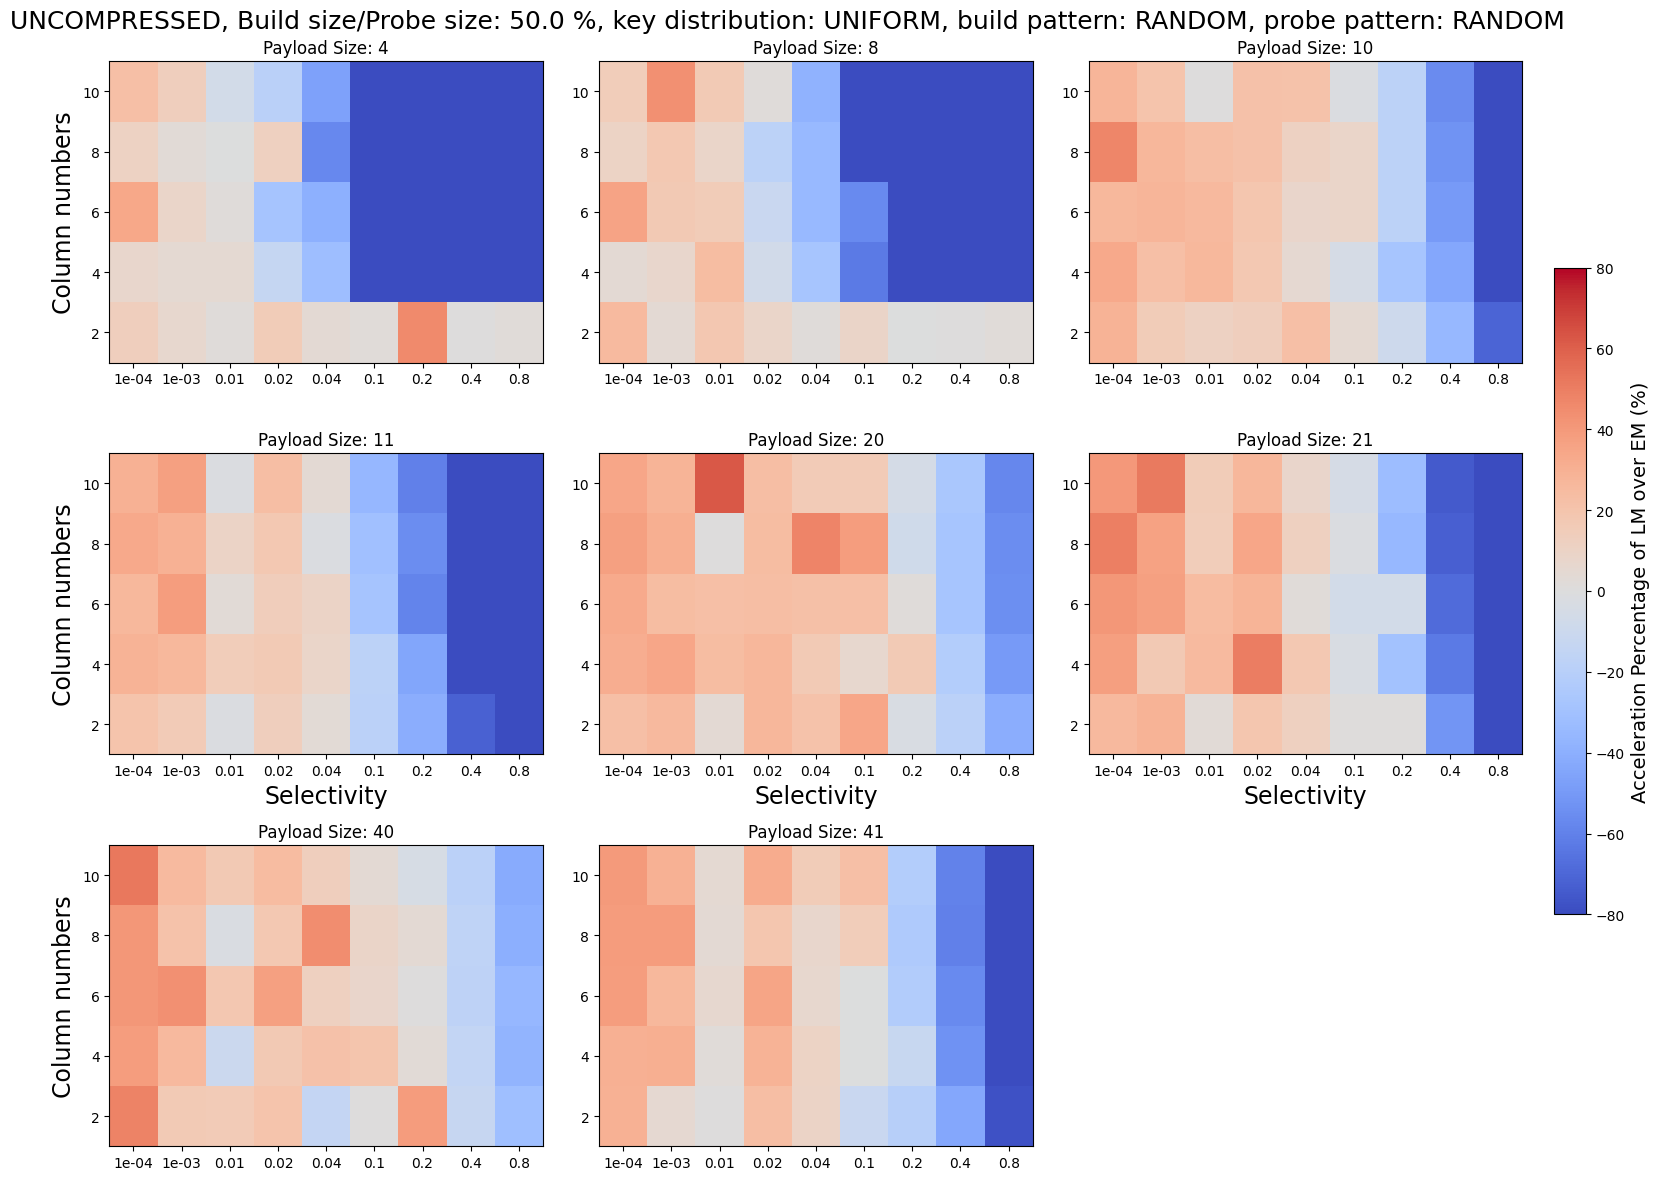

In [15]:

# 创建一个包含多个子图的图形，排成三列
num_plots = len(payload_groups)
num_cols = 3
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows))


for idx, payload_size in enumerate(payload_groups):
    row = idx // num_cols
    col = idx % num_cols
    ax = axes[row, col] if num_rows > 1 else axes[col]
    # only fixed length string 
    group_df = filtered_df[filtered_df['payload_size'] == payload_size]
    selectivities = group_df['selectivity'].unique()
    column_nums = group_df['column_num'].unique()
    selectivities.sort()
    column_nums.sort()

    label = []
    for i, selectivity in enumerate(selectivities):
        if selectivity<0.01:
            label.append(str(format(selectivity, ".0e")))
        else:
            label.append(str(selectivity))

    # 创建颜色矩阵
    color_matrix = np.zeros((len(column_nums), len(selectivities)))

    for i, column_num in enumerate(column_nums):
        for j, selectivity in enumerate(selectivities):
            time_1 = min_time_df[(min_time_df['selectivity'] == selectivity) & 
                                 (min_time_df['column_num'] == column_num) & (min_time_df['payload_size'] == payload_size)]['time'].min()
            time_0 = group_df[(group_df['selectivity'] == selectivity) & 
                              (group_df['column_num'] == column_num) & 
                              (group_df['mat_strat'] == "0")]['time'].min()
            if pd.notna(time_1) and pd.notna(time_0):
                color_matrix[i, j] = (time_0-time_1)/time_0 * 100
                # print(selectivities[j], payload_sizes[i], color_matrix[i, j])

    # 绘制颜色矩阵
    norm = Normalize(vmin=-80, vmax=80)
    c = ax.pcolormesh(label, column_nums, color_matrix, cmap='coolwarm', shading='auto',norm=norm)

    if col==0:
        ax.set_ylabel('Column numbers',fontsize=17)
    if row == (num_plots//num_cols -1):
        ax.set_xlabel('Selectivity',fontsize=17)

    ax.set_title(f'Payload Size: {payload_size}')



cbar = fig.colorbar(c, ax=axes, orientation='vertical',anchor=(2.4,0.5), shrink=0.7)
cbar.set_label('Acceleration Percentage of LM over EM (%)',fontsize=14)
for idx in range(num_plots, num_rows * num_cols):
    fig.delaxes(axes.flatten()[idx])
    
title = f'Build size/Probe size: {fil_build_size/200000} %, key distribution: {fil_probe_distribution.upper()}, build pattern: {fil_build_key_pattern.upper()}, probe pattern: {fil_probe_key_pattern.upper()}'
if fil_build_side_hit_ratio!=1:
    title+=f' build hit ratio: {fil_build_side_hit_ratio}'
if fil_mode==1:
    title = 'UNCOMPRESSED, '+title
else:
    title = 'COMPRESSED, '+title

fig.suptitle(title, fontsize=18)
plt.tight_layout()
plt.show()

# compressed storage (real payload)

In [195]:

columns = [
    "mode", "thread_num", "probe_size", "build_size", "selectivity", "payload_size",
    "probe_distribution", "build_side_hit_ratio", "build_key_pattern", "probe_key_pattern",
    "mat_strat", "queue_thr", "payload_file", "time"
]

# 读取文件并解析数据
data = []
with open('/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/benchmark_realpayload_comrpessed_dropcache.txt', 'r') as file:
    for line in file:
        # 将每行数据拆分为多个字段
        values = line.strip().split()
        # 将字段转换为适当的类型
        values = [int(values[0]), int(values[1]), int(values[2]), int(values[3]), float(values[4]),
                  int(values[5]), values[6], float(values[7]), values[8], values[9], values[10],
                  int(values[11]), values[12],float(values[13])]
        data.append(values)

# 将数据转换为 Pandas DataFrame
df_mul = pd.DataFrame(data, columns=columns)


df_total = pd.concat([df, df_mul])
df_total=df_mul
df_mul.groupby(['probe_distribution','build_side_hit_ratio', 'build_key_pattern','probe_key_pattern','payload_file'])["time"].min()

probe_distribution  build_side_hit_ratio  build_key_pattern  probe_key_pattern  payload_file      
uniform             1.0                   random             random             books_200M_uint64     462.822
                                                                                email                 459.565
                                                                                genome_200M_uint64    465.796
                                                                                house_price           466.960
                                                                                hu_freq               467.601
                                                                                japanese              464.268
                                                                                movieid               465.182
                                                                                ps_comment            470.153
                     

In [196]:
fil_mode = 2
fil_probe_distribution = 'uniform'
fil_build_side_hit_ratio = 1
fil_build_key_pattern = 'random'
fil_probe_key_pattern = 'random'
fil_payload_size = 0

filtered_df = df_total[(df_total['mode'] == fil_mode) & 
                 (df_total['probe_distribution'] == fil_probe_distribution) & 
                 (df_total['build_side_hit_ratio'] == fil_build_side_hit_ratio) & 
                 (df_total['build_key_pattern'] == fil_build_key_pattern) & 
                 (df_total['probe_key_pattern'] == fil_probe_key_pattern) &
                 (df_total['payload_size'] == fil_payload_size)
]

min_time_df = filtered_df[filtered_df['mat_strat'] == "1"].groupby(['thread_num','build_size','selectivity', 'payload_size','payload_file'])["time"].min().reset_index()
payload_groups = filtered_df['payload_file'].unique()

/tmp/ipykernel_3154790/4277202806.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


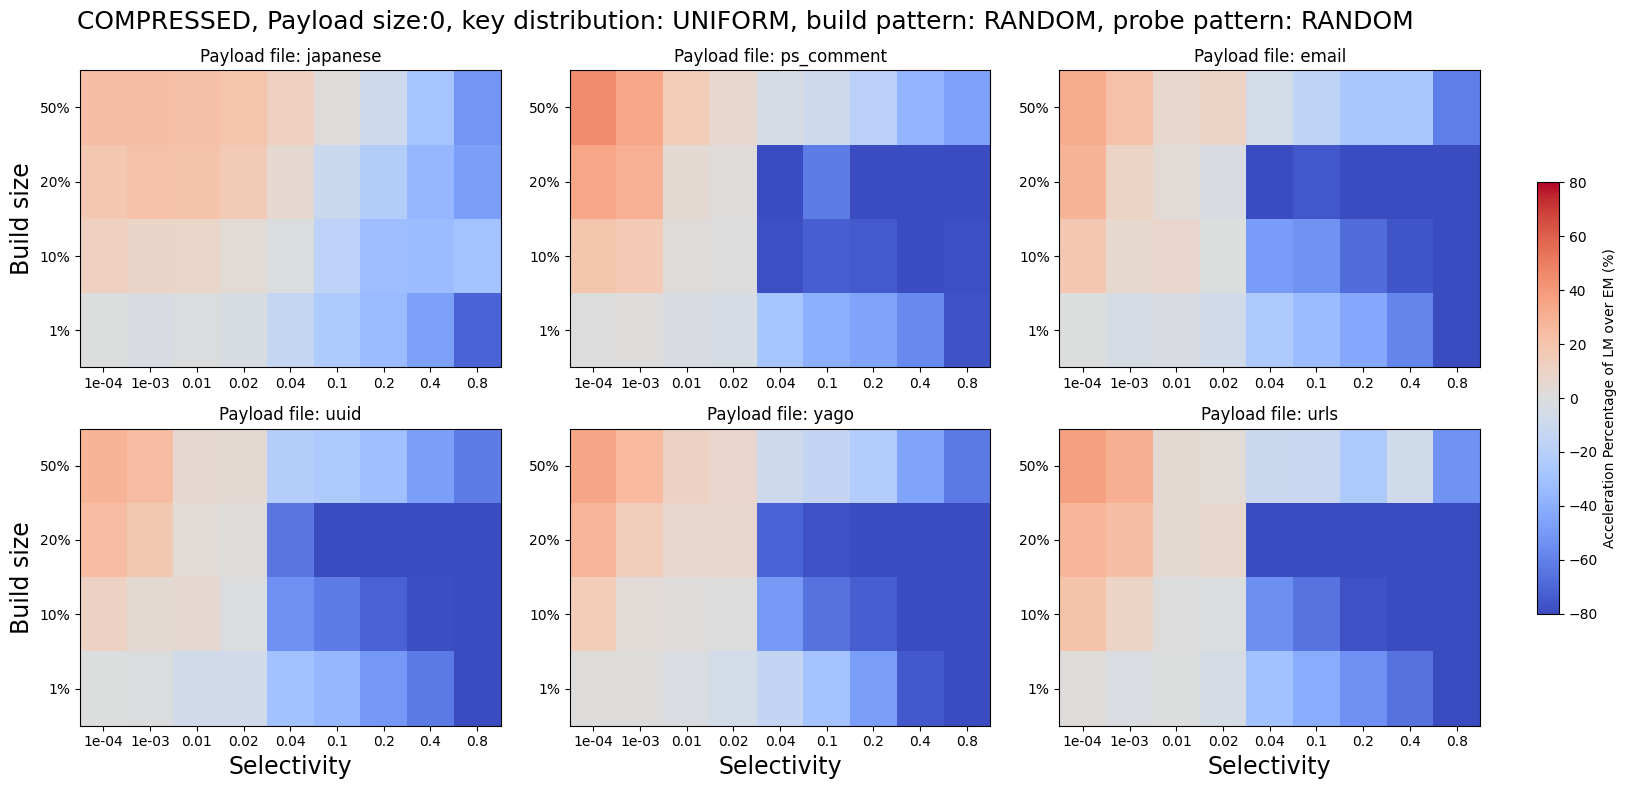

In [197]:

# 创建一个包含多个子图的图形，排成三列
num_plots = len(payload_groups)
num_cols = 3
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows))


for idx, payload_file in enumerate(payload_groups):
    row = idx // num_cols
    col = idx % num_cols
    ax = axes[row, col] if num_rows > 1 else axes[col]
    # only fixed length string 
    group_df = filtered_df[filtered_df['payload_file'] == payload_file]
    selectivities = group_df['selectivity'].unique()
    build_size = group_df['build_size'].unique()
    selectivities.sort()
    build_size.sort()
    build_size_new = []
    # for b in build_size:
    #     build_size_new.append(str(b))
    build_size_new = ['1%','10%','20%','50%']

    label = []
    for i, selectivity in enumerate(selectivities):
        if selectivity<0.01:
            label.append(str(format(selectivity, ".0e")))
        else:
            label.append(str(selectivity))

    # 创建颜色矩阵
    color_matrix = np.zeros((len(build_size), len(selectivities)))

    for i, build in enumerate(build_size):
        for j, selectivity in enumerate(selectivities):
            time_1 = min_time_df[(min_time_df['selectivity'] == selectivity) & 
                                 (min_time_df['build_size'] == build) & (min_time_df['payload_file'] == payload_file)]['time'].min()
            time_0 = group_df[(group_df['selectivity'] == selectivity) & 
                              (group_df['build_size'] == build) & 
                              (group_df['mat_strat'] == "0")]['time'].min()
            if pd.notna(time_1) and pd.notna(time_0):
                color_matrix[i, j] = (time_0-time_1)/time_0 * 100
                # print(selectivities[j], payload_sizes[i], color_matrix[i, j])

    # 绘制颜色矩阵
    norm = Normalize(vmin=-80, vmax=80)
    c = ax.pcolormesh(label, build_size_new, color_matrix, cmap='coolwarm', shading='auto',norm=norm)

    if col==0:
        ax.set_ylabel('Build size',fontsize=17)
    if row == (num_plots//num_cols -1):
        ax.set_xlabel('Selectivity',fontsize=17)

    ax.set_title(f'Payload file: {payload_file}')



cbar = fig.colorbar(c, ax=axes, orientation='vertical',anchor=(2.4,0.5), shrink=0.7)
cbar.set_label('Acceleration Percentage of LM over EM (%)',fontsize=10)
for idx in range(num_plots, num_rows * num_cols):
    fig.delaxes(axes.flatten()[idx])
    
title = f'Payload size:{fil_payload_size}, key distribution: {fil_probe_distribution.upper()}, build pattern: {fil_build_key_pattern.upper()}, probe pattern: {fil_probe_key_pattern.upper()}'
if fil_build_side_hit_ratio!=1:
    title+=f' build hit ratio: {fil_build_side_hit_ratio}'
if fil_mode==1:
    title = 'UNCOMPRESSED, '+title
else:
    title = 'COMPRESSED, '+title

fig.suptitle(title, fontsize=18)
plt.tight_layout()
plt.show()

# Breakdown (different build size)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def parse_file(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[0])
            queue_thr = int(line1[1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])


## fixed build size, fix payloads, different selectivity.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

def parse_file_multi(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[-2])
            queue_thr = int(line1[-1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])

line_color = ['#90C9E6','#02304A','#219EBC','#FEB705','#FA8600']
def plot_data(df):
    color_map = ['darkblue','skyblue','lightgreen','yellow','gold']
    color_map = ['#35BBCA','#0191B4','#D3DD18','#F8D90F','#FE7A15']
    color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    # color_map=['#02304A','#219EBC','#90CBE6','#FEB705','#FA8600']
    # color_map=['#4B74B2','#90BEE0','#FFDF92','#FC8C5A','#DB3124']
    build_sizes = df['build_size'].unique()
    build_sizes = [10000000]
    payload_size = 40
    num_plots = len(build_sizes)
    num_cols = 1
    num_rows = (num_plots + num_cols - 1) // num_cols
    
    fig = plt.figure(figsize=(8, 6))
    for idx, build_size in enumerate(build_sizes):
        row = idx // num_cols
        col = idx % num_cols
        # ax = axes[col]
        df_build = df[(df['build_size'] == build_size)&(df['payload_size'] ==payload_size)]
        selectivities = df_build['selectivity'].unique()
        selectivities = selectivities[:-1]
        print(selectivities)
        indices = np.arange(len(selectivities))
        indices = 5.0*indices
        bar_width = 0.8
        latencies_0 = []
        latencies_1 = []
        latencies_2 = []
        latencies_3 = []
        latencies_4 = []
        for i, selectivity in enumerate(selectivities):
            df_sel = df_build[df_build['selectivity'] == selectivity]
            df_sel_1 = df_sel[df_sel['mat_strat'] == 0]
            df_sel_0 = df_sel[df_sel['mat_strat'] == 1].nsmallest(1, 'latency')
            df_sel_2 = df_sel[df_sel['mat_strat'] == 2]
            df_sel_3 = df_sel[df_sel['mat_strat'] == 3].nsmallest(1, 'latency')
            df_sel_4 = df_sel[df_sel['mat_strat'] == 4].nsmallest(1, 'latency')
            index = i * 5
            if not df_sel_0.empty:
                #late mat(batch)
                plt.bar(index, df_sel_0['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                plt.bar(index, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                plt.bar(index, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                plt.bar(index, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                plt.bar(index, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                latencies_0.append(df_sel_0['latency'].values[0])
            if not df_sel_3.empty:
                #late mat(batch)
                plt.bar(index + bar_width, df_sel_3['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                plt.bar(index + bar_width, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0],color = color_map[1],edgecolor='grey')
                plt.bar(index + bar_width, df_sel_3['hash_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0],color = color_map[2],edgecolor='grey')
                plt.bar(index + bar_width, df_sel_3['materialize_time'].values[0] , bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                plt.bar(index + bar_width, df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[4],edgecolor='grey')
                latencies_3.append(df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0]+df_sel_3['map_build_time'].values[0])
            if not df_sel_1.empty:
                # early
                plt.bar(index + bar_width*4, df_sel_1['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                plt.bar(index + bar_width*4, df_sel_1['others'].values[0], bar_width, bottom=df_sel_1['io'].values[0], color = color_map[1],edgecolor='grey')
                plt.bar(index + bar_width*4, df_sel_1['hash_build_time'].values[0], bar_width, bottom=df_sel_1['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                latencies_1.append(df_sel_1['latency'].values[0])
            if not df_sel_2.empty:
                #late mat
                plt.bar(index+ bar_width*3, df_sel_2['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                plt.bar(index+ bar_width*3, df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0],  color = color_map[1],edgecolor='grey')
                plt.bar(index+ bar_width*3, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[2],edgecolor='grey')
                plt.bar(index+ bar_width*3, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                latencies_2.append(df_sel_2['latency'].values[0])
            if not df_sel_4.empty:
                #late mat(batch)
                # if abs(df_sel_4['io'].values[0]+df_sel_4['others'].values[0]+df_sel_4['hash_build_time'].values[0]+df_sel_4['materialize_time'].values[0]+ df_sel_4['map_build_time'].values[0] - df_sel_4['latency'].values[0])<0.2:
                plt.bar(index + bar_width*2, df_sel_4['io'].values[0], bar_width,  color = color_map[0],edgecolor='grey')
                plt.bar(index + bar_width*2, df_sel_4['others'].values[0], bar_width, bottom=df_sel_4['io'].values[0], color = color_map[1],edgecolor='grey')
                plt.bar(index + bar_width*2, df_sel_4['hash_build_time'].values[0], bar_width, bottom=df_sel_4['io'].values[0] + df_sel_4['others'].values[0], color = color_map[2],edgecolor='grey')
                plt.bar(index + bar_width*2, df_sel_4['materialize_time'].values[0] , bar_width, bottom=df_sel_4['io'].values[0] + df_sel_4['others'].values[0] + df_sel_4['hash_build_time'].values[0], color = color_map[3],edgecolor='grey')
                plt.bar(index + bar_width*2, df_sel_4['map_build_time'].values[0], bar_width, bottom=df_sel_4['io'].values[0] + df_sel_4['others'].values[0] + df_sel_4['hash_build_time'].values[0]+ df_sel_4['materialize_time'].values[0],  color = color_map[4],edgecolor='grey')
                latencies_4.append(df_sel_4['latency'].values[0])
                
        plt.plot(indices, np.array(latencies_0)*1.01, marker='v', markeredgewidth=2,ms=7,linewidth=2.3,color=line_color[0], label='Late materialize (batch)')
        plt.plot(indices+ bar_width, np.array(latencies_3)*1.01, marker='o',markeredgewidth=2,ms=8,linewidth=2.3, color=line_color[1], label='Late materialize (unique)')
        plt.plot(indices+ bar_width*2, np.array(latencies_4)*1.01, marker='*',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[2], label='Late materialize (sort)')
        plt.plot(indices+ bar_width*3, np.array(latencies_2)*1.01, marker='s',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[3], label='Late materialize (naive)')
        plt.plot(indices + bar_width*4, np.array(latencies_1)*1.01, marker='^',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[4], label='Early materialize')
        plt.xlabel('Selectivity',fontsize=17)
        plt.ylabel('Latency',fontsize=17)
        plt.title(f'Build/Probe: {build_size/200000}% Payload_size: {payload_size}',fontsize=16)
        plt.xticks([i * 5 + 1.5*bar_width for i in range(len(selectivities))],selectivities,fontsize=14)
        plt.yticks(fontsize=13)


        # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15)
        plt.legend(fontsize=12)
    fig_name = 'different_sel'
    plt.tight_layout()
    plt.savefig(f"/home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/benchmark/paper_figure/micro/{fig_name}.pdf",bbox_inches='tight')
    plt.show()



[1.e-04 1.e-03 1.e-02 2.e-02 4.e-02 1.e-01 2.e-01 4.e-01]


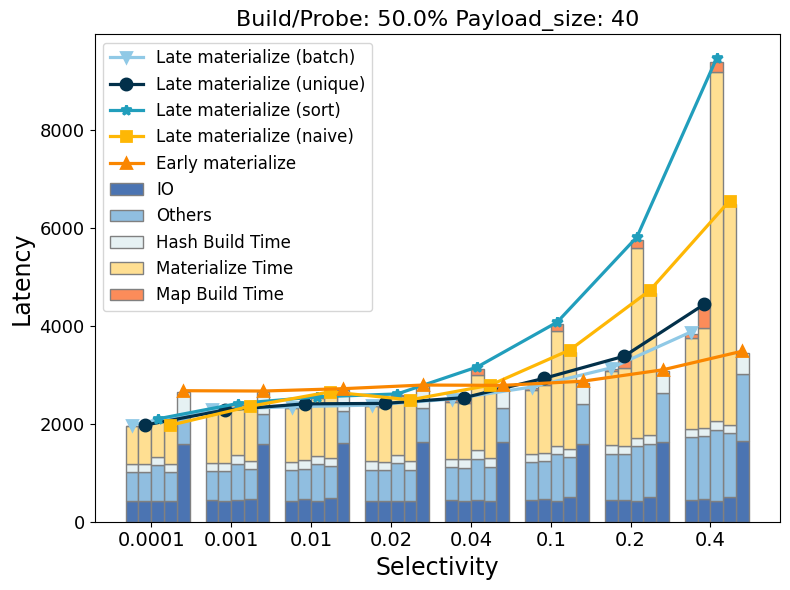

,mat_strat,queue_thr,build_size,selectivity,payload_size,map_build_time,materialize_time,hash_build_time,others,io,latency
0,3,100,2000000,0.0001,4,0.26,22.34,35.38,475.28,350.27,860.93
1,3,1000,2000000,0.0001,4,0.90,20.77,34.89,464.14,291.68,790.72
2,3,2000,2000000,0.0001,4,0.58,23.73,35.31,475.94,329.84,841.09
3,3,100,2000000,0.0001,8,0.25,44.11,34.47,492.00,317.68,844.16
4,3,1000,2000000,0.0001,8,0.58,42.92,35.80,501.00,290.85,827.65
...,...,...,...,...,...,...,...,...,...,...,...
18,4,20000,2000000,0.0400,20,134.01,498.69,36.69,633.58,245.08,1548.04
19,4,20000,4000000,0.0400,20,133.79,594.24,72.76,728.56,288.91,1818.26
20,4,20000,10000000,0.0400,20,134.35,942.31,173.74,822.28,430.70,2503.38
21,4,20000,15000000,0.0400,20,146.47,862.22,256.87,1130.22,502.30,2898.08


In [18]:
# Example usage
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0115.txt'  # Replace with your file path
df_batch = parse_file(file_path)
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0115_unique.txt'  # Replace with your file path
df = parse_file(file_path)

file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/benchmark_sort_0206.log'  # Replace with your file path
df_sort = parse_file_multi(file_path)

df_total = pd.concat([df, df_batch,df_sort],axis=0)
plot_data(df_total)
df_total

## fixed build size, fix selectivity, different payloads.

In [39]:
line_color = ['#90C9E6','#02304A','#219EBC','#FEB705','#FA8600']
def plot_data(df):
    color_map = ['darkblue','skyblue','lightgreen','yellow','gold']
    color_map = ['#35BBCA','#0191B4','#D3DD18','#F8D90F','#FE7A15']
    color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    # color_map=['#02304A','#219EBC','#90CBE6','#FEB705','#FA8600']
    # color_map=['#4B74B2','#90BEE0','#FFDF92','#FC8C5A','#DB3124']
    build_sizes = df['build_size'].unique()
    build_sizes = [10000000]
    selectivity = 0.02
    num_plots = len(build_sizes)
    num_cols = 1
    num_rows = (num_plots + num_cols - 1) // num_cols
    
    fig = plt.figure(figsize=(8, 6))
    for idx, build_size in enumerate(build_sizes):
        row = idx // num_cols
        col = idx % num_cols
        # ax = axes[col]
        df_build = df[(df['build_size'] == build_size)&(df['selectivity'] ==selectivity)]
        payload_size = df_build['payload_size'].unique()
        payload_size = [4,8,10,20,40,60,80]
        indices = np.arange(len(payload_size))
        indices = 5.0*indices
        bar_width = 0.8
        latencies_0 = []
        latencies_1 = []
        latencies_2 = []
        latencies_3 = []
        latencies_4 = []
        for i, pay in enumerate(payload_size):
            df_sel = df_build[df_build['payload_size'] == pay]
            df_sel_1 = df_sel[df_sel['mat_strat'] == 0]
            df_sel_0 = df_sel[df_sel['mat_strat'] == 1].nsmallest(1, 'latency')
            df_sel_2 = df_sel[df_sel['mat_strat'] == 2]
            df_sel_3 = df_sel[df_sel['mat_strat'] == 3].nsmallest(1, 'latency')
            df_sel_4 = df_sel[df_sel['mat_strat'] == 4].nsmallest(1, 'latency')
            index = i * 5
            if not df_sel_0.empty:
                #late mat(batch)
                if abs(df_sel_0['io'].values[0]+df_sel_0['others'].values[0]+df_sel_0['hash_build_time'].values[0]+df_sel_0['materialize_time'].values[0]+ df_sel_0['map_build_time'].values[0] -df_sel_0['latency'].values[0])<1:
                    plt.bar(index, df_sel_0['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index, df_sel_0['others'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                else:
                    plt.bar(index, df_sel_0['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                latencies_0.append(df_sel_0['latency'].values[0])
            if not df_sel_3.empty:
                #late mat(batch)
                if abs(df_sel_3['io'].values[0]+df_sel_3['others'].values[0]+df_sel_3['hash_build_time'].values[0]+df_sel_3['materialize_time'].values[0]+ df_sel_3['map_build_time'].values[0] - df_sel_3['latency'].values[0])<0.2:
                    plt.bar(index + bar_width, df_sel_3['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['others'].values[0], bar_width, bottom=df_sel_3['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['hash_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_3['others'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['materialize_time'].values[0] , bar_width, bottom=df_sel_3['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                    latencies_3.append(df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]+df_sel_3['map_build_time'].values[0])
                else:
                    plt.bar(index + bar_width, df_sel_3['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0],color = color_map[1],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['hash_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0],color = color_map[2],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['materialize_time'].values[0] , bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[4],edgecolor='grey')
                    latencies_3.append(df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0]+df_sel_3['map_build_time'].values[0])
            if not df_sel_1.empty:
                # early
                plt.bar(index + bar_width*4, df_sel_1['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                plt.bar(index + bar_width*4, df_sel_1['others'].values[0], bar_width, bottom=df_sel_1['io'].values[0], color = color_map[1],edgecolor='grey')
                plt.bar(index + bar_width*4, df_sel_1['hash_build_time'].values[0], bar_width, bottom=df_sel_1['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                latencies_1.append(df_sel_1['latency'].values[0])
            if not df_sel_2.empty:
                #late mat
                if abs(df_sel_2['io'].values[0]+df_sel_2['others'].values[0]+df_sel_2['hash_build_time'].values[0]+df_sel_2['materialize_time'].values[0]+ df_sel_2['map_build_time'].values[0]-df_sel_2['latency'].values[0])<1:
                    plt.bar(index+ bar_width*3, df_sel_2['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width*3, df_sel_2['others'].values[0], bar_width, bottom=df_sel_2['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width*3, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width*3, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index+ bar_width*3, df_sel_2['map_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]+ df_sel_2['materialize_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                else:
                    plt.bar(index+ bar_width*3, df_sel_2['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width*3, df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0],  color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width*3, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width*3, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                latencies_2.append(df_sel_2['latency'].values[0])
            if not df_sel_4.empty:
                #late mat(batch)
                # if abs(df_sel_4['io'].values[0]+df_sel_4['others'].values[0]+df_sel_4['hash_build_time'].values[0]+df_sel_4['materialize_time'].values[0]+ df_sel_4['map_build_time'].values[0] - df_sel_4['latency'].values[0])<0.2:
                plt.bar(index + bar_width*2, df_sel_4['io'].values[0], bar_width,  color = color_map[0],edgecolor='grey')
                plt.bar(index + bar_width*2, df_sel_1['others'].values[0], bar_width, bottom=df_sel_4['io'].values[0], color = color_map[1],edgecolor='grey')
                plt.bar(index + bar_width*2, df_sel_4['hash_build_time'].values[0], bar_width, bottom=df_sel_4['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                plt.bar(index + bar_width*2, df_sel_4['materialize_time'].values[0] , bar_width, bottom=df_sel_4['io'].values[0] + df_sel_1['others'].values[0] + df_sel_4['hash_build_time'].values[0], color = color_map[3],edgecolor='grey')
                plt.bar(index + bar_width*2, df_sel_4['map_build_time'].values[0], bar_width, bottom=df_sel_4['io'].values[0] + df_sel_1['others'].values[0] + df_sel_4['hash_build_time'].values[0]+ df_sel_4['materialize_time'].values[0],  color = color_map[4],edgecolor='grey')
                latencies_4.append(df_sel_4['latency'].values[0]+df_sel_1['others'].values[0]-df_sel_4['others'].values[0])
        plt.plot(indices, np.array(latencies_0)*1.01, marker='v', markeredgewidth=2,ms=7,linewidth=2.3,color=line_color[0], label='Late materialize (batch)')
        plt.plot(indices+ bar_width, np.array(latencies_3)*1.01, marker='o',markeredgewidth=2,ms=8,linewidth=2.3, color=line_color[1], label='Late materialize (unique)')
        plt.plot(indices+ bar_width*2, np.array(latencies_4)*1.01, marker='*',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[2], label='Late materialize (sort)')
        plt.plot(indices+ bar_width*3, np.array(latencies_2)*1.01, marker='s',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[3], label='Late materialize (naive)')
        plt.plot(indices + bar_width*4, np.array(latencies_1)*1.01, marker='^',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[4], label='Early materialize')
        plt.xlabel('Payload size',fontsize=17)
        plt.ylabel('Latency',fontsize=17)
        plt.title(f'Build/Probe: {build_size/200000}% Selectivity: {selectivity}',fontsize=16)
        plt.xticks([i * 5 + 1.5*bar_width for i in range(len(payload_size))],payload_size,fontsize=14)
        plt.yticks(fontsize=13)


        # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15)
        plt.legend(fontsize=11.5)
    fig_name = 'different_payload'
    plt.tight_layout()
    plt.savefig(f"/home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/benchmark/paper_figure/micro/{fig_name}.pdf",bbox_inches='tight')
    plt.show()



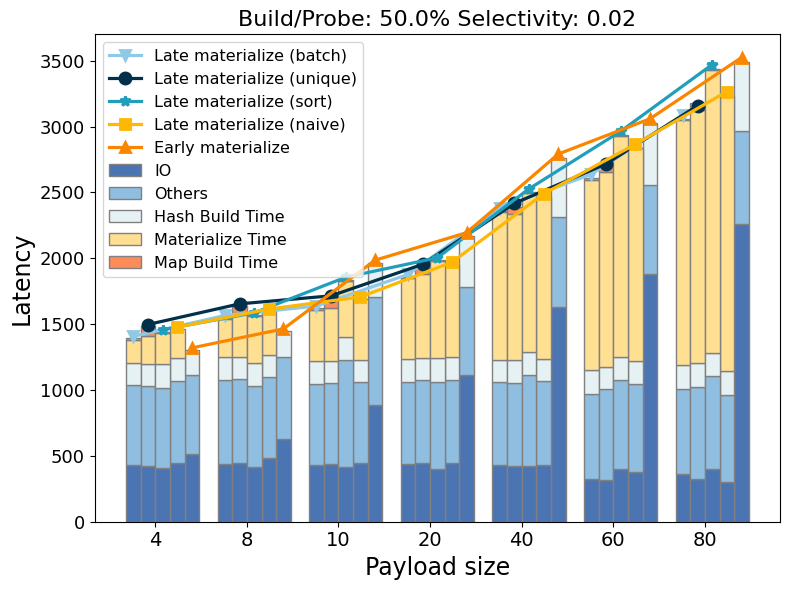

In [40]:
# Example usage
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0115.txt'  # Replace with your file path
df_batch = parse_file(file_path)
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0115_unique.txt'  # Replace with your file path
df = parse_file(file_path)
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/benchmark_sort_0206.log'  # Replace with your file path
df_sort = parse_file_multi(file_path)

df_total = pd.concat([df, df_batch,df_sort],axis=0)
plot_data(df_total)

## fixed payload, fix selectivity, different build size.

In [46]:
line_color = ['#90C9E6','#02304A','#219EBC','#FEB705','#FA8600']
def plot_data(df):
    color_map = ['darkblue','skyblue','lightgreen','yellow','gold']
    color_map = ['#35BBCA','#0191B4','#D3DD18','#F8D90F','#FE7A15']
    color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    # color_map=['#02304A','#219EBC','#90CBE6','#FEB705','#FA8600']
    # color_map=['#4B74B2','#90BEE0','#FFDF92','#FC8C5A','#DB3124']
    build_sizes = df['build_size'].unique()
    build_sizes.sort()
    selectivity = 0.04
    payload_sizes = [20]
    num_plots = len(build_sizes)
    num_cols = 1
    num_rows = (num_plots + num_cols - 1) // num_cols
    
    fig = plt.figure(figsize=(8, 6))
    label = []
    for i, build in enumerate(build_sizes):
        ratio = build/200000
        if ratio < 1:
            label.append(str(format(ratio, ".0e")))
        else:
            label.append(str(int(ratio)))

    for idx, payload_size in enumerate(payload_sizes):
        row = idx // num_cols
        col = idx % num_cols
        # ax = axes[col]
        df_build = df[(df['payload_size'] == payload_size)&(df['selectivity'] ==selectivity)]
        indices = np.arange(len(build_sizes))
        indices = 5.0*indices
        bar_width = 0.8
        latencies_0 = []
        latencies_1 = []
        latencies_2 = []
        latencies_3 = []
        latencies_4 = []
        for i, build in enumerate(build_sizes):
            df_sel = df_build[df_build['build_size'] == build]
            df_sel_1 = df_sel[df_sel['mat_strat'] == 0]
            df_sel_0 = df_sel[df_sel['mat_strat'] == 1].nsmallest(1, 'latency')
            df_sel_2 = df_sel[df_sel['mat_strat'] == 2]
            df_sel_3 = df_sel[df_sel['mat_strat'] == 3].nsmallest(1, 'latency')
            df_sel_4 = df_sel[df_sel['mat_strat'] == 4].nsmallest(1, 'latency')
            index = i * 5
            if not df_sel_0.empty:
                #late mat(batch)
                if abs(df_sel_0['io'].values[0]+df_sel_0['others'].values[0]+df_sel_0['hash_build_time'].values[0]+df_sel_0['materialize_time'].values[0]+ df_sel_0['map_build_time'].values[0] -df_sel_0['latency'].values[0])<1:
                    plt.bar(index, df_sel_0['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index, df_sel_0['others'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                else:
                    plt.bar(index, df_sel_0['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                latencies_0.append(df_sel_0['latency'].values[0])
            if not df_sel_3.empty:
                #late mat(batch)
                if abs(df_sel_3['io'].values[0]+df_sel_3['others'].values[0]+df_sel_3['hash_build_time'].values[0]+df_sel_3['materialize_time'].values[0]+ df_sel_3['map_build_time'].values[0] - df_sel_3['latency'].values[0])<0.2:
                    plt.bar(index + bar_width, df_sel_3['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['others'].values[0], bar_width, bottom=df_sel_3['io'].values[0], color = color_map[1],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['hash_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_3['others'].values[0], color = color_map[2],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['materialize_time'].values[0] , bar_width, bottom=df_sel_3['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0], color = color_map[3],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0], color = color_map[4],edgecolor='grey')
                    latencies_3.append(df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]+df_sel_3['map_build_time'].values[0])
                else:
                    plt.bar(index + bar_width, df_sel_3['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0],color = color_map[1],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['hash_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0],color = color_map[2],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['materialize_time'].values[0] , bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[4],edgecolor='grey')
                    latencies_3.append(df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0]+df_sel_3['map_build_time'].values[0])
            if not df_sel_1.empty:
                # early
                plt.bar(index + bar_width*3, df_sel_1['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                plt.bar(index + bar_width*3, df_sel_1['others'].values[0], bar_width, bottom=df_sel_1['io'].values[0], color = color_map[1],edgecolor='grey')
                plt.bar(index + bar_width*3, df_sel_1['hash_build_time'].values[0], bar_width, bottom=df_sel_1['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                latencies_1.append(df_sel_1['latency'].values[0])
            if not df_sel_2.empty:
                #late mat
                if abs(df_sel_2['io'].values[0]+df_sel_2['others'].values[0]+df_sel_2['hash_build_time'].values[0]+df_sel_2['materialize_time'].values[0]+ df_sel_2['map_build_time'].values[0]-df_sel_2['latency'].values[0])<1:
                    plt.bar(index+ bar_width*2, df_sel_2['io'].values[0], bar_width,  color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['others'].values[0], bar_width, bottom=df_sel_2['io'].values[0], color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0], color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0], color = color_map[3],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['map_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]+ df_sel_2['materialize_time'].values[0], color = color_map[4],edgecolor='grey')
                else:
                    plt.bar(index+ bar_width*2, df_sel_2['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0],  color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                latencies_2.append(df_sel_2['latency'].values[0])
            if not df_sel_4.empty:
                    #late mat(batch)
                    # if abs(df_sel_4['io'].values[0]+df_sel_4['others'].values[0]+df_sel_4['hash_build_time'].values[0]+df_sel_4['materialize_time'].values[0]+ df_sel_4['map_build_time'].values[0] - df_sel_4['latency'].values[0])<0.2:
                    plt.bar(index + bar_width*2, df_sel_4['io'].values[0], bar_width,  color = color_map[0],edgecolor='grey')
                    plt.bar(index + bar_width*2, df_sel_1['others'].values[0], bar_width, bottom=df_sel_4['io'].values[0], color = color_map[1],edgecolor='grey')
                    plt.bar(index + bar_width*2, df_sel_4['hash_build_time'].values[0], bar_width, bottom=df_sel_4['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                    plt.bar(index + bar_width*2, df_sel_4['materialize_time'].values[0] , bar_width, bottom=df_sel_4['io'].values[0] + df_sel_1['others'].values[0] + df_sel_4['hash_build_time'].values[0], color = color_map[3],edgecolor='grey')
                    plt.bar(index + bar_width*2, df_sel_4['map_build_time'].values[0], bar_width, bottom=df_sel_4['io'].values[0] + df_sel_1['others'].values[0] + df_sel_4['hash_build_time'].values[0]+ df_sel_4['materialize_time'].values[0],  color = color_map[4],edgecolor='grey')
                    latencies_4.append(df_sel_4['latency'].values[0]+df_sel_1['others'].values[0]-df_sel_4['others'].values[0])
        plt.plot(indices, np.array(latencies_0)*1.01, marker='v', markeredgewidth=2,ms=7,linewidth=2.3,color=line_color[0], label='Late materialize (batch)')
        plt.plot(indices+ bar_width, np.array(latencies_3)*1.01, marker='o',markeredgewidth=2,ms=8,linewidth=2.3, color=line_color[1], label='Late materialize (unique)')
        plt.plot(indices+ bar_width*2, np.array(latencies_4)*1.01, marker='*',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[2], label='Late materialize (sort)')
        plt.plot(indices+ bar_width*3, np.array(latencies_2)*1.01, marker='s',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[3], label='Late materialize (naive)')
        plt.plot(indices + bar_width*4, np.array(latencies_1)*1.01, marker='^',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[4], label='Early materialize')
        plt.xlabel('Build/Probe (%)',fontsize=17)
        plt.ylabel('Latency',fontsize=17)
        plt.title(f'Payload size: {payload_size} Selectivity: {selectivity}',fontsize=16)
        plt.xticks([i * 5 + 1.5*bar_width for i in range(len(build_sizes))],label,fontsize=14)
        plt.yticks(fontsize=13)


        # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15)
    plt.legend(fontsize=13)
    fig_name = 'different_buildsize'
    plt.tight_layout()
    plt.savefig(f"/home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/benchmark/paper_figure/micro/{fig_name}.pdf",bbox_inches='tight')
    plt.show()



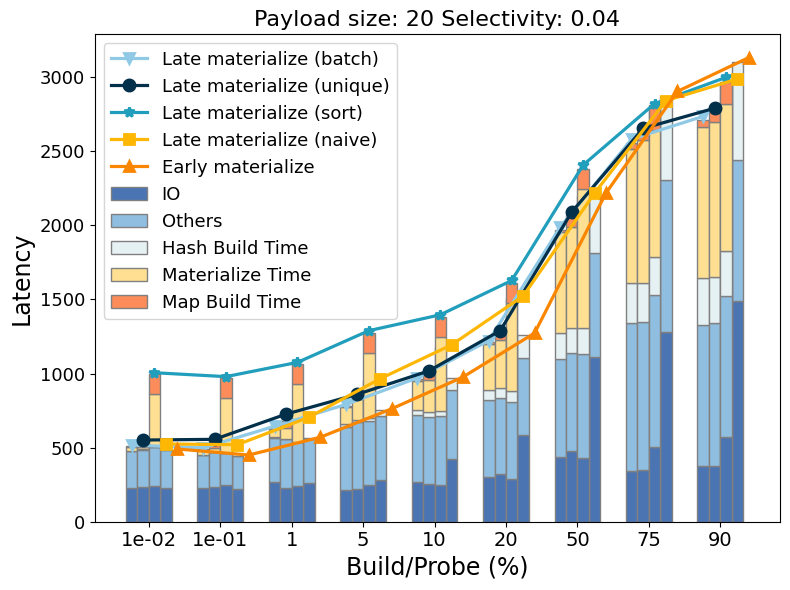

In [47]:
# Example usage
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0204.txt'  # Replace with your file path
df_batch = parse_file(file_path)
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0204_unique.txt'  # Replace with your file path
df = parse_file(file_path)
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/benchmark_sort_0206.log'  # Replace with your file path
df_sort = parse_file_multi(file_path)

df_total = pd.concat([df, df_batch,df_sort],axis=0)
plot_data(df_total)

## [TODO] breakdown skew + unique (fix sel, payload size, build size)

In [170]:
def parse_file_multi(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[0])
            queue_thr = int(line1[1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            skew = float(line1[5])
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, skew, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'skew', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])

def parse_file_single(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[0])
            queue_thr = int(line1[1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            skew = 0
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, skew, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'skew', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])


line_color = ['#02304A','#219EBC','#FEB705','#FA8600']
def plot_data(df):
    color_map = ['darkblue','skyblue','lightgreen','yellow','gold']
    color_map = ['#35BBCA','#0191B4','#D3DD18','#F8D90F','#FE7A15']
    color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    # color_map=['#02304A','#219EBC','#90CBE6','#FEB705','#FA8600']
    # color_map=['#4B74B2','#90BEE0','#FFDF92','#FC8C5A','#DB3124']
    build_sizes = df['build_size'].unique()
    build_sizes = [10000000]
    selectivity = 0.04
    payload_size = 10
    num_plots = len(build_sizes)
    num_cols = 1
    num_rows = (num_plots + num_cols - 1) // num_cols
    skews= [0,1,0.8,0.4,0.2,0.1]
    fig = plt.figure(figsize=(8, 4.5))
    for idx, build_size in enumerate(build_sizes):
        row = idx // num_cols
        col = idx % num_cols
        # ax = axes[col]
        df_build = df[(df['build_size'] == build_size)&(df['selectivity'] ==selectivity) & (df['payload_size'] ==payload_size)]
        skews= [0,1,0.8,0.4,0.1]
        indices = np.arange(len(skews))
        indices = 4.0*indices
        bar_width = 0.8
        latencies_0 = []
        latencies_1 = []
        latencies_2 = []
        latencies_3 = []
        labels = ['uniform','zipfian','cluster\n(0.8)','cluster\n(0.4)','cluster\n(0.2)','cluster\n(0.1)']
        labels = ['uniform','zipfian','cluster\n(0.8)','cluster\n(0.4)','cluster\n(0.1)']    
        for i, skew in enumerate(skews):
            df_sel = df_build[df_build['skew'] == skew]
            df_sel_1 = df_sel[df_sel['mat_strat'] == 0]
            df_sel_0 = df_sel[df_sel['mat_strat'] == 1].nsmallest(1, 'latency')
            df_sel_2 = df_sel[df_sel['mat_strat'] == 2]
            df_sel_3 = df_sel[df_sel['mat_strat'] == 3].nsmallest(1, 'latency')

            index = i * 4
            if not df_sel_0.empty:
                #late mat(batch)
                if abs(df_sel_0['io'].values[0]+df_sel_0['others'].values[0]+df_sel_0['hash_build_time'].values[0]+df_sel_0['materialize_time'].values[0]+ df_sel_0['map_build_time'].values[0] -df_sel_0['latency'].values[0])<1:
                    plt.bar(index, df_sel_0['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index, df_sel_0['others'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                else:
                    plt.bar(index, df_sel_0['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                latencies_0.append(df_sel_0['latency'].values[0])
            if not df_sel_3.empty:
                #late mat(batch)
                if abs(df_sel_3['io'].values[0]+df_sel_3['others'].values[0]+df_sel_3['hash_build_time'].values[0]+df_sel_3['materialize_time'].values[0]+ df_sel_3['map_build_time'].values[0] - df_sel_3['latency'].values[0])<1:
                    plt.bar(index + bar_width, df_sel_0['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['others'].values[0], bar_width, bottom=df_sel_0['io'].values[0], color = color_map[1],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_3['others'].values[0], color = color_map[2],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0], color = color_map[3],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0], color = color_map[4],edgecolor='grey')
                    latencies_3.append(df_sel_0['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]+df_sel_3['map_build_time'].values[0])
                else:
                    plt.bar(index + bar_width, df_sel_3['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0],color = color_map[1],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['hash_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0],color = color_map[2],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['materialize_time'].values[0] , bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[4],edgecolor='grey')
                    latencies_3.append(df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0]+df_sel_3['map_build_time'].values[0])
            if not df_sel_1.empty:
                # early
                plt.bar(index + bar_width*3, df_sel_1['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                plt.bar(index + bar_width*3, df_sel_1['others'].values[0], bar_width, bottom=df_sel_1['io'].values[0], color = color_map[1],edgecolor='grey')
                plt.bar(index + bar_width*3, df_sel_1['hash_build_time'].values[0], bar_width, bottom=df_sel_1['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                latencies_1.append(df_sel_1['latency'].values[0])
            if not df_sel_2.empty:
                #late mat
                if abs(df_sel_2['io'].values[0]+df_sel_2['others'].values[0]+df_sel_2['hash_build_time'].values[0]+df_sel_2['materialize_time'].values[0]+ df_sel_2['map_build_time'].values[0]-df_sel_2['latency'].values[0])<1:
                    plt.bar(index+ bar_width*2, df_sel_2['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['others'].values[0], bar_width, bottom=df_sel_2['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['map_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]+ df_sel_2['materialize_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                else:
                    plt.bar(index+ bar_width*2, df_sel_2['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0],  color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                latencies_2.append(df_sel_2['latency'].values[0])
        plt.plot(indices, np.array(latencies_0)*1.01, marker='v', markeredgewidth=2,ms=7,linewidth=2.3,color=line_color[0], label='LM (batch)')
        plt.plot(indices+ bar_width, np.array(latencies_3)*1.01, marker='o',markeredgewidth=2,ms=8,linewidth=2.3, color=line_color[1], label='LM (unique)')
        plt.plot(indices+ bar_width*2, np.array(latencies_2)*1.01, marker='s',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[2], label='LM (naive)')
        plt.plot(indices + bar_width*3, np.array(latencies_1)*1.01, marker='^',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[3], label='EM')
        plt.xlabel('Skew distribution',fontsize=17)
        plt.ylabel('Latency',fontsize=17)
        plt.title(f'Build/Probe: {build_size/200000}% Selectivity: {selectivity}, Payload size: {payload_size}',fontsize=15)
        plt.xticks([i * 4 + 1.5*bar_width for i in range(len(skews))],labels,fontsize=14)
        plt.yticks(fontsize=13)


        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=11.5)
        # plt.legend(fontsize=11.5)
    fig_name = 'skew_breakdown'
    plt.tight_layout()
    plt.savefig(f"/home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/benchmark/paper_figure/micro/{fig_name}.pdf",bbox_inches='tight')
    plt.show()


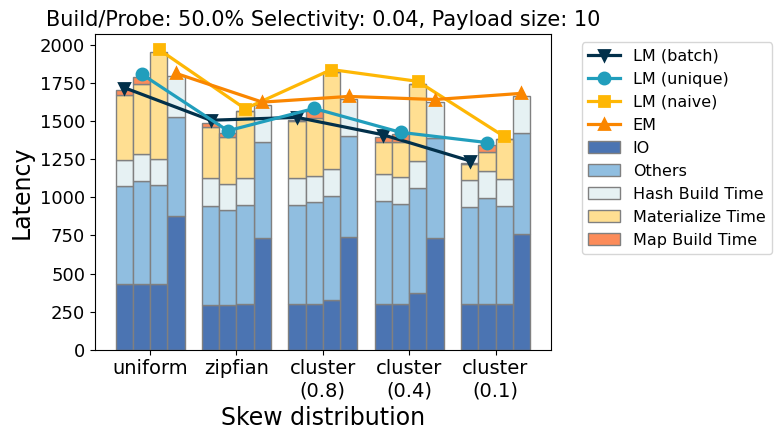

In [171]:
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_skew.txt'  # Replace with your file path
df_batch = parse_file_multi(file_path)
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0204.txt'  # Replace with your file path
df = parse_file_single(file_path)
df = df[df['build_size']==10000000]

df_total = pd.concat([df, df_batch],axis=0)
plot_data(df_total)



## Multi column

In [188]:
import pandas as pd
import matplotlib.pyplot as plt

def parse_file_multi(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[0])
            queue_thr = int(line1[1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            column_num = int(line1[5])
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, column_num, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'column_num', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])

def parse_file_single(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[0])
            queue_thr = int(line1[1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            column_num = 1
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, column_num, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'column_num', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])


line_color = ['#02304A','#219EBC','#FEB705','#FA8600']
def plot_data(df):
    color_map = ['darkblue','skyblue','lightgreen','yellow','gold']
    color_map = ['#35BBCA','#0191B4','#D3DD18','#F8D90F','#FE7A15']
    color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    # color_map=['#02304A','#219EBC','#90CBE6','#FEB705','#FA8600']
    # color_map=['#4B74B2','#90BEE0','#FFDF92','#FC8C5A','#DB3124']
    build_sizes = df['build_size'].unique()
    build_sizes = [10000000]
    selectivity = 0.1
    payload_size = 10
    num_plots = len(build_sizes)
    num_cols = 1
    num_rows = (num_plots + num_cols - 1) // num_cols
    
    fig = plt.figure(figsize=(8, 4.5))
    for idx, build_size in enumerate(build_sizes):
        row = idx // num_cols
        col = idx % num_cols
        # ax = axes[col]
        df_build = df[(df['build_size'] == build_size)&(df['selectivity'] ==selectivity) & (df['payload_size'] ==payload_size)]
        column_number = [1,2,4,6,8,10]
        indices = np.arange(len(column_number))
        indices = 4.0*indices
        bar_width = 0.8
        latencies_0 = []
        latencies_1 = []
        latencies_2 = []
        latencies_3 = []
        for i, cols in enumerate(column_number):
            df_sel = df_build[df_build['column_num'] == cols]
            df_sel_1 = df_sel[df_sel['mat_strat'] == 0]
            df_sel_0 = df_sel[df_sel['mat_strat'] == 1].nsmallest(1, 'latency')
            df_sel_2 = df_sel[df_sel['mat_strat'] == 2]
            # df_sel_3 = df_sel[df_sel['mat_strat'] == 3].nsmallest(1, 'latency')
            index = i * 4
            if not df_sel_0.empty:
                #late mat(batch)
                if abs(df_sel_0['io'].values[0]+df_sel_0['others'].values[0]+df_sel_0['hash_build_time'].values[0]+df_sel_0['materialize_time'].values[0]+ df_sel_0['map_build_time'].values[0] -df_sel_0['latency'].values[0])<1:
                    plt.bar(index, df_sel_0['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index, df_sel_0['others'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                else:
                    plt.bar(index, df_sel_0['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                latencies_0.append(df_sel_0['latency'].values[0])
            if not df_sel_1.empty:
                # early
                plt.bar(index + bar_width*2, df_sel_1['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                plt.bar(index + bar_width*2, df_sel_1['others'].values[0], bar_width, bottom=df_sel_1['io'].values[0], color = color_map[1],edgecolor='grey')
                plt.bar(index + bar_width*2, df_sel_1['hash_build_time'].values[0], bar_width, bottom=df_sel_1['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                latencies_1.append(df_sel_1['latency'].values[0])
            if not df_sel_2.empty:
                #late mat
                if abs(df_sel_2['io'].values[0]+df_sel_2['others'].values[0]+df_sel_2['hash_build_time'].values[0]+df_sel_2['materialize_time'].values[0]+ df_sel_2['map_build_time'].values[0]-df_sel_2['latency'].values[0])<1:
                    plt.bar(index+ bar_width, df_sel_2['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_2['others'].values[0], bar_width, bottom=df_sel_2['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_2['map_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]+ df_sel_2['materialize_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                else:
                    plt.bar(index+ bar_width, df_sel_2['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0],  color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                latencies_2.append(df_sel_2['latency'].values[0])
        plt.plot(indices, np.array(latencies_0)*1.01, marker='v', markeredgewidth=2,ms=7,linewidth=2.3,color=line_color[0], label='Late materialize (batch)')
        # plt.plot(indices+ bar_width, np.array(latencies_3)*1.01, marker='o',markeredgewidth=2,ms=8,linewidth=2.3, color=line_color[1], label='Late materialize (unique)')
        plt.plot(indices+ bar_width, np.array(latencies_2)*1.01, marker='s',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[2], label='Late materialize (naive)')
        plt.plot(indices + bar_width*2, np.array(latencies_1)*1.01, marker='^',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[3], label='Early materialize')
        plt.xlabel('Number of columns',fontsize=17)
        plt.ylabel('Latency',fontsize=17)
        plt.title(f'Build/Probe: {build_size/200000}% Selectivity: {selectivity}, Payload size: {payload_size}',fontsize=16)
        plt.xticks([i * 4 + 1.5*bar_width for i in range(len(column_number))],column_number,fontsize=14)
        plt.yticks(fontsize=13)


        # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15)
        plt.legend(fontsize=11.5)
    fig_name = 'multi_column_breakdown'
    plt.tight_layout()
    plt.savefig(f"/home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/benchmark/paper_figure/micro/{fig_name}.pdf",bbox_inches='tight')
    plt.show()



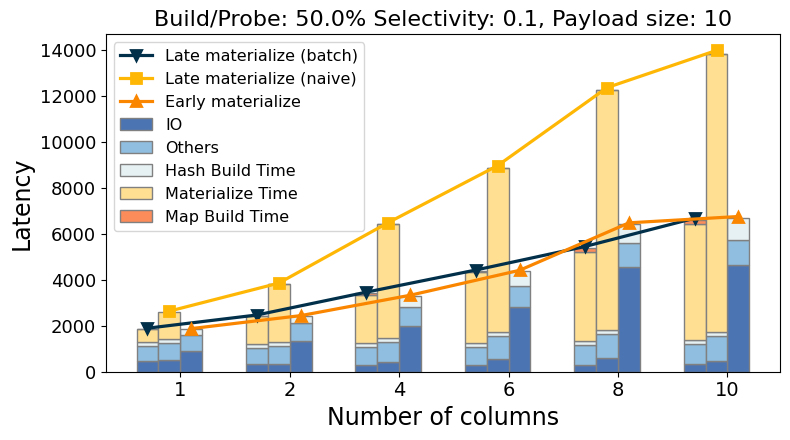

In [189]:
# Example usage
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0204_multicol.txt'  # Replace with your file path
df_batch = parse_file_multi(file_path)
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0204.txt'  # Replace with your file path
df = parse_file_single(file_path)
df = df[df['build_size']==10000000]

df_total = pd.concat([df, df_batch],axis=0)
plot_data(df_total)

In [190]:
fil_mode = 1
fil_probe_distribution = 'uniform'
fil_build_side_hit_ratio = 1
fil_build_key_pattern = 'random'
fil_probe_key_pattern = 'random'
fil_build_size = 10000000

In [191]:
df_total

,mat_strat,queue_thr,build_size,selectivity,payload_size,column_num,map_build_time,materialize_time,hash_build_time,others,io,latency
4230,0,0,10000000,0.0001,4,1,0.00,0.00,191.19,580.31,511.61,1283.11
4231,1,10,10000000,0.0001,4,1,0.07,90.75,171.94,697.20,419.72,1288.86
4232,1,100,10000000,0.0001,4,1,0.07,91.70,170.03,679.68,418.52,1268.23
4233,1,1000,10000000,0.0001,4,1,0.42,89.38,173.25,718.77,418.91,1310.93
4234,1,2000,10000000,0.0001,4,1,0.39,90.37,170.81,687.64,421.19,1279.64
...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,10000000,0.1000,41,10,0.00,0.00,2950.24,1812.89,9161.57,13924.70
996,2,0,10000000,0.1000,41,10,0.00,21037.90,182.34,1933.90,598.26,23752.40
997,1,100,10000000,0.1000,41,10,34.81,13898.80,199.77,1748.63,563.69,16445.70
998,1,1000,10000000,0.1000,41,10,121.02,14178.70,182.54,1793.71,346.43,16622.40


In [192]:
filtered_df = df_total

min_time_df = filtered_df[filtered_df['mat_strat'] == 1].groupby(['build_size','selectivity', 'payload_size','column_num'])["latency"].min().reset_index()
selectivities = [0.01,0.02,0.04,0.1]
min_time_df

,build_size,selectivity,payload_size,column_num,latency
0,10000000,0.0001,4,1,1268.23
1,10000000,0.0001,8,1,1378.67
2,10000000,0.0001,10,1,1518.56
3,10000000,0.0001,11,1,1489.70
4,10000000,0.0001,20,1,1710.23
...,...,...,...,...,...
321,10000000,0.8000,61,1,6825.11
322,10000000,0.8000,80,1,7476.43
323,10000000,0.8000,81,1,7462.27
324,10000000,0.8000,100,1,7398.43


4


/tmp/ipykernel_3154790/3856694942.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


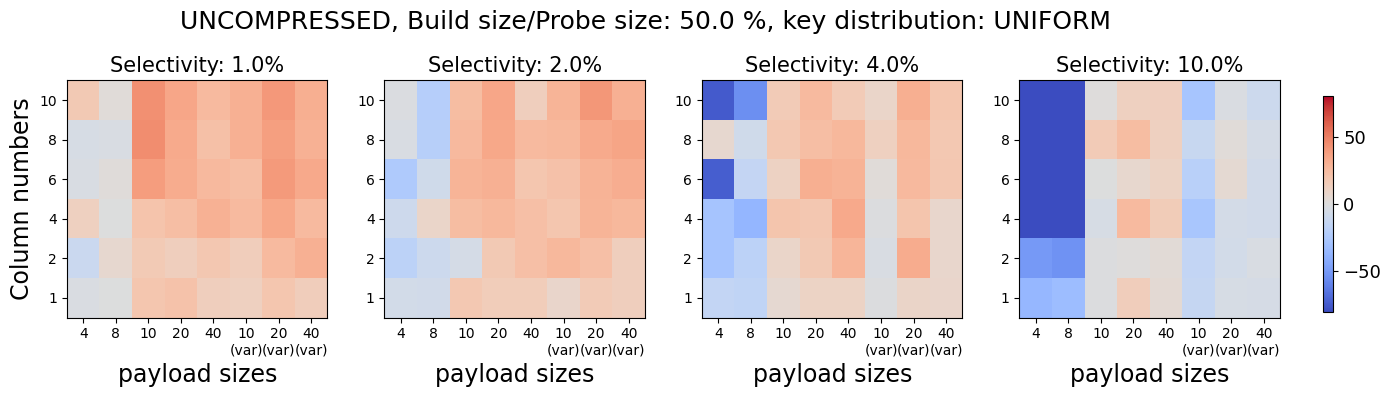

In [194]:

# 创建一个包含多个子图的图形，排成三列
num_plots = len(selectivities)
print(num_plots)
num_cols = 4
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(13, 4 * num_rows))


for idx, selectivity in enumerate(selectivities):
    row = idx // num_cols
    col = idx % num_cols
    ax = axes[row, col] if num_rows > 1 else axes[col]
    # only fixed length string 
    group_df = filtered_df[filtered_df['selectivity'] == selectivity]
    payload_sizes = group_df['payload_size'].unique()
    payload_sizes = [4,8,10,20,40,11,21,41]
    column_nums = group_df['column_num'].unique()
    selectivities.sort()
    column_nums.sort()

    label = []
    for i, payload_size in enumerate(payload_sizes):
        if payload_size%10==1:
            label.append(str(payload_size//10 * 10)+ '\n(var)')
        else:
            label.append(str(payload_size))

    column_str = []
    for i, column_num in enumerate(column_nums):
        column_str.append(str(column_num))

    # 创建颜色矩阵
    color_matrix = np.zeros((len(column_nums), len(payload_sizes)))

    for i, column_num in enumerate(column_nums):
        for j, payload_size in enumerate(payload_sizes):
            time_1 = min_time_df[(min_time_df['payload_size'] == payload_size) & 
                                 (min_time_df['column_num'] == column_num) & (min_time_df['selectivity'] == selectivity)]['latency'].min()
            time_0 = group_df[(group_df['payload_size'] == payload_size) & 
                              (group_df['column_num'] == column_num) & 
                              (group_df['mat_strat'] == 0)]['latency'].min()
            if pd.notna(time_1) and pd.notna(time_0):
                color_matrix[i, j] = (time_0-time_1)/time_0 * 100
        

    # 绘制颜色矩阵
    norm = Normalize(vmin=-80, vmax=80)
    c = ax.pcolormesh(label, column_str, color_matrix, cmap='coolwarm', shading='auto',norm=norm)

    if col==0:
        ax.set_ylabel('Column numbers',fontsize=17)
    if row == (num_plots//num_cols -1):
        ax.set_xlabel('payload sizes',fontsize=17)

    ax.set_title(f'Selectivity: {selectivity*100.0}%',fontsize=15)



cbar = fig.colorbar(c, ax=axes, orientation='vertical',anchor=(2.2,0.5), shrink=0.7)
cbar.ax.tick_params(labelsize=13) 
# cbar.set_label('Acceleration Percentage of LM over EM (%)',fontsize=14)

for idx in range(num_plots, num_rows * num_cols):
    fig.delaxes(axes.flatten()[idx])
    
title = f'Build size/Probe size: {fil_build_size/200000} %, key distribution: {fil_probe_distribution.upper()}'
if fil_build_side_hit_ratio!=1:
    title+=f' build hit ratio: {fil_build_side_hit_ratio}'
if fil_mode==1:
    title = 'UNCOMPRESSED, '+title
else:
    title = 'COMPRESSED, '+title

fig.suptitle(title, fontsize=18)
fig_name = 'multi_column_heatmap'
plt.tight_layout()
plt.savefig(f"/home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/benchmark/paper_figure/micro/{fig_name}.pdf",bbox_inches='tight')
plt.show()


## compressed storage

In [2]:
def parse_file_multi(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[0])
            queue_thr = int(line1[1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            data_name = (line1[5])
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, data_name, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'data_name', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])


In [77]:
def plot_data(df):
    line_color = ['#02304A','#219EBC','#FEB705','#FA8600']
    color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    build_sizes = [10000000]
    payload_size = 20
    selectivity = 0.04
    num_plots = 1
    num_cols = 1
    num_rows = (num_plots + num_cols - 1) // num_cols
    # fig, axes = plt.subplots(num_cols,num_rows,figsize=(14, 10))
    fig = plt.figure(figsize=(10, 5))
    thre = 10000
    for idx, build_size in enumerate(build_sizes):
        row = idx // num_cols
        col = idx % num_cols
        df_build = df[(df['build_size'] == build_size)& (df['selectivity'] == selectivity)]
   
        data_names = ['movieid','house_price','books_200M_uint64','genome_200M_uint64','japanese','ps_comment','email','uuid','yago','urls' ]
        data_names_label = ['movieid\nint32\n(50%)','  houseprice\nint32\n(33%)','books\nint64\n(50%)','genome\nint64\n(38%)','japanese\nstring\n(13%)','  comment\nstring\n(31%)','email\nstring\n(42%)','uuid\nstring\n(42%)','yago\nstring\n(56%)','urls\nstring\n(44%)' ]
       
        indices = np.arange(len(data_names))
        indices = 4.0*indices
        bar_width = 0.8
        latencies_0 = []
        latencies_1 = []
        latencies_2 = []
        latencies_3 = []
        for i, data_name in enumerate(data_names):
            df_sel = df_build[df_build['data_name'] == data_name]
            df_sel_1 = df_sel[df_sel['mat_strat'] == 0]
            df_sel_0 = df_sel[df_sel['mat_strat'] == 1].nsmallest(1, 'latency')
            df_sel_2 = df_sel[df_sel['mat_strat'] == 2]
            df_sel_3 = df_sel[df_sel['mat_strat'] == 3].nsmallest(1, 'latency')

            index = i * 4
            if not df_sel_0.empty:
                #late mat(batch)
                if abs(df_sel_0['io'].values[0]+df_sel_0['others'].values[0]+df_sel_0['hash_build_time'].values[0]+df_sel_0['materialize_time'].values[0]+ df_sel_0['map_build_time'].values[0] -df_sel_0['latency'].values[0])<1:
                    plt.bar(index, df_sel_0['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index, df_sel_0['others'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                else:
                    plt.bar(index, df_sel_0['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                    plt.bar(index, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                    plt.bar(index, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                    plt.bar(index, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                    plt.bar(index, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                latencies_0.append(df_sel_0['latency'].values[0])
                if df_sel_0['latency'].values[0]>thre:
                    plt.text(index-bar_width, thre*0.95, str(int(df_sel_0['latency'].values[0])))
            if not df_sel_3.empty:
                #late mat(batch)
                if abs(df_sel_3['io'].values[0]+df_sel_3['others'].values[0]+df_sel_3['hash_build_time'].values[0]+df_sel_3['materialize_time'].values[0]+ df_sel_3['map_build_time'].values[0] - df_sel_3['latency'].values[0])<1:
                    plt.bar(index + bar_width, df_sel_0['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['others'].values[0], bar_width, bottom=df_sel_0['io'].values[0], color = color_map[1],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_3['others'].values[0], color = color_map[2],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0], color = color_map[3],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0], color = color_map[4],edgecolor='grey')
                    latencies_3.append(df_sel_0['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]+df_sel_3['map_build_time'].values[0])
                else:
                    plt.bar(index + bar_width, df_sel_3['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0],color = color_map[1],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['hash_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0],color = color_map[2],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['materialize_time'].values[0] , bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                    plt.bar(index + bar_width, df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[4],edgecolor='grey')
                    latencies_3.append(df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0]+df_sel_3['map_build_time'].values[0])
                if df_sel_3['latency'].values[0]>thre:
                    plt.text(index, thre*0.95, str(int(df_sel_3['latency'].values[0])),fontsize=13)
            if not df_sel_1.empty:
                # early
                plt.bar(index + bar_width*3, df_sel_1['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                plt.bar(index + bar_width*3, df_sel_1['others'].values[0], bar_width, bottom=df_sel_1['io'].values[0], color = color_map[1],edgecolor='grey')
                plt.bar(index + bar_width*3, df_sel_1['hash_build_time'].values[0], bar_width, bottom=df_sel_1['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                latencies_1.append(df_sel_1['latency'].values[0])
            if not df_sel_2.empty:
                #late mat
                if abs(df_sel_2['io'].values[0]+df_sel_2['others'].values[0]+df_sel_2['hash_build_time'].values[0]+df_sel_2['materialize_time'].values[0]+ df_sel_2['map_build_time'].values[0]-df_sel_2['latency'].values[0])<1:
                    plt.bar(index+ bar_width*2, df_sel_2['io'].values[0], bar_width,  color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['others'].values[0], bar_width, bottom=df_sel_2['io'].values[0], color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0], color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0], color = color_map[3],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['map_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]+ df_sel_2['materialize_time'].values[0], color = color_map[4],edgecolor='grey')
                else:
                    plt.bar(index+ bar_width*2, df_sel_2['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0],  color = color_map[1],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[2],edgecolor='grey')
                    plt.bar(index+ bar_width*2, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                latencies_2.append(df_sel_2['latency'].values[0])
                if df_sel_2['latency'].values[0]>thre:
                    plt.text(index+ bar_width, thre*0.9, str(int(df_sel_2['latency'].values[0])),fontsize=13)
        plt.plot(indices, np.array(latencies_0)*1.01, marker='v', markeredgewidth=2,ms=7,linewidth=2.3,color=line_color[0], label='LM (batch)')
        plt.plot(indices+ bar_width, np.array(latencies_3)*1.01, marker='o',markeredgewidth=2,ms=8,linewidth=2.3, color=line_color[1], label='LM (batch wo full \ndecompression)')
        plt.plot(indices+ bar_width*2, np.array(latencies_2)*1.01, marker='s',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[2], label='LM (naive)')
        plt.plot(indices + bar_width*3, np.array(latencies_1)*1.01, marker='^',markeredgewidth=2,ms=7,linewidth=2.3, color=line_color[3], label='EM')
        plt.xlabel('Datasets',fontsize=17)
        plt.ylabel('Latency',fontsize=17)
        plt.title(f'Build/Probe: {build_size/200000}% Compressed Real-world Datasets',fontsize=17)
        plt.xticks([i * 4 + bar_width for i in range(len(data_names))],data_names_label,fontsize=13)
        plt.ylim([0,thre])


    # plt.legend(bbox_to_anchor=(1.0, 0.9), loc='upper left',fontsize=12)

    plt.legend(fontsize=11.5, bbox_to_anchor=(0.5, 0.26))
    fig_name = 'compressed_breakdown'
    plt.tight_layout()
    plt.savefig(f"/home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/benchmark/paper_figure/micro/{fig_name}.pdf",bbox_inches='tight')
    plt.show()



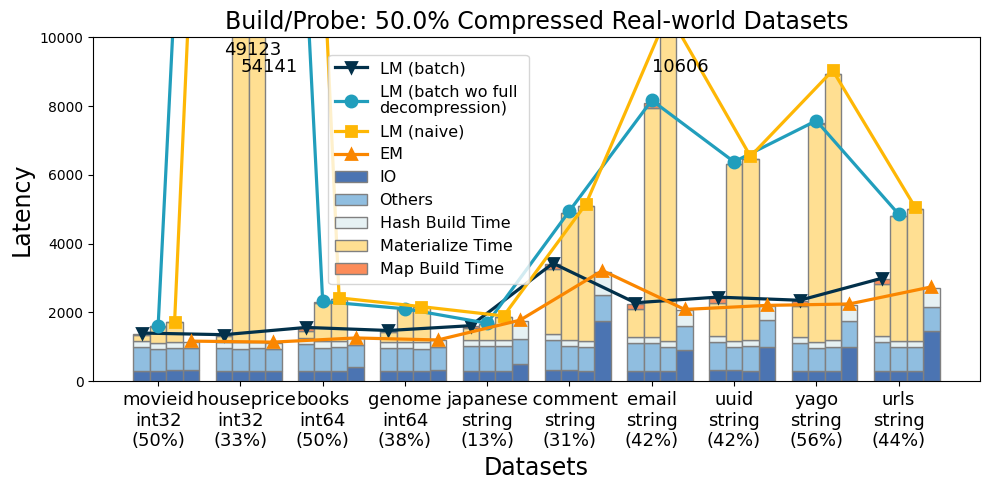

,mat_strat,queue_thr,build_size,selectivity,payload_size,data_name,map_build_time,materialize_time,hash_build_time,others,io,latency
0,3,100,10000000,0.0001,4,movieid,0.07,45.50,180.13,581.51,282.95,1090.17
1,3,1000,10000000,0.0001,4,movieid,0.37,45.15,178.65,601.33,278.06,1103.56
2,3,2000,10000000,0.0001,4,movieid,0.37,44.20,176.62,584.68,278.51,1084.38
3,3,20000,10000000,0.0001,4,movieid,0.38,44.91,179.50,673.10,281.35,1179.23
4,3,50000,10000000,0.0001,4,movieid,0.38,46.92,179.62,826.55,281.64,1335.10
...,...,...,...,...,...,...,...,...,...,...,...,...
688,1,1000,10000000,0.8000,0,urls,322.72,10571.00,180.56,2040.93,338.79,13454.00
689,1,2000,10000000,0.8000,0,urls,356.51,6599.59,181.32,2060.11,330.68,9528.22
690,1,20000,10000000,0.8000,0,urls,551.73,3184.06,181.00,2108.28,308.41,6333.48
691,1,50000,10000000,0.8000,0,urls,562.23,3327.46,179.07,2378.58,319.95,6767.29


In [78]:

file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_compress_real_0204_new.txt'  # Replace with your file path
df_batch = parse_file_multi(file_path)
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_compress_real_0204_no_full.txt'  # Replace with your file path
df = parse_file_multi(file_path)
df_total = pd.concat([df, df_batch],axis=0)
plot_data(df_total)
df_total

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def parse_file(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[0])
            queue_thr = int(line1[1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])

def plot_data(df):
    color_map = ['darkblue','skyblue','lightgreen','yellow','gold']
    build_sizes = df['build_size'].unique()
    payload_size = 40
    num_plots = len(build_sizes)
    num_cols = 2
    num_rows = (num_plots + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_cols,num_rows,figsize=(14, 10))
    for idx, build_size in enumerate(build_sizes):
        row = idx // num_cols
        col = idx % num_cols
        ax = axes[row, col] if num_rows > 1 else axes[col]
        df_build = df[(df['build_size'] == build_size)&(df['payload_size'] ==payload_size)]
        selectivities = df_build['selectivity'].unique()
        selectivities = selectivities[:-1]
        indices = np.arange(len(selectivities))
        indices = 3.0*indices
        bar_width = 0.8
        latencies_0 = []
        latencies_1 = []
        latencies_2 = []
        for i, selectivity in enumerate(selectivities):
            df_sel = df_build[df_build['selectivity'] == selectivity]
            df_sel_1 = df_sel[df_sel['mat_strat'] == 0]
            df_sel_0 = df_sel[df_sel['mat_strat'] == 1].nsmallest(1, 'latency')
            df_sel_2 = df_sel[df_sel['mat_strat'] == 2]
            index = i * 3
            if not df_sel_0.empty:
                #late mat(batch)
                ax.bar(index, df_sel_0['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                ax.bar(index, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                ax.bar(index, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                ax.bar(index, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                ax.bar(index, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                latencies_0.append(df_sel_0['latency'].values[0])
            if not df_sel_1.empty:
                # early
                ax.bar(index + bar_width*2, df_sel_1['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                ax.bar(index + bar_width*2, df_sel_1['others'].values[0], bar_width, bottom=df_sel_1['io'].values[0], color = color_map[1],edgecolor='grey')
                ax.bar(index + bar_width*2, df_sel_1['hash_build_time'].values[0], bar_width, bottom=df_sel_1['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                latencies_1.append(df_sel_1['latency'].values[0])
            if not df_sel_2.empty:
                #late mat
                ax.bar(index+ bar_width, df_sel_2['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                ax.bar(index+ bar_width, df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0],  color = color_map[1],edgecolor='grey')
                ax.bar(index+ bar_width, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[2],edgecolor='grey')
                ax.bar(index+ bar_width, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                latencies_2.append(df_sel_2['latency'].values[0])
        ax.plot(indices, np.array(latencies_0)*1.01, marker='o', color='blue', label='Late materialize (batch)')
        ax.plot(indices+ bar_width, np.array(latencies_2)*1.01, marker='o', color='green', label='Late materialize (naive)')
        ax.plot(indices + bar_width*2, np.array(latencies_1)*1.01, marker='o', color='orange', label='Early materialize')
        ax.set_xlabel('Selectivity')
        ax.set_ylabel('Latency')
        ax.set_title(f'Build Size/Probe Size: {build_size/200000}% Payload_size: {payload_size}')
        ax.set_xticks([i * 3 + bar_width for i in range(len(selectivities))])
        ax.set_xticklabels(selectivities)
        if row==0 and col==num_cols-1:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15)
    plt.show()



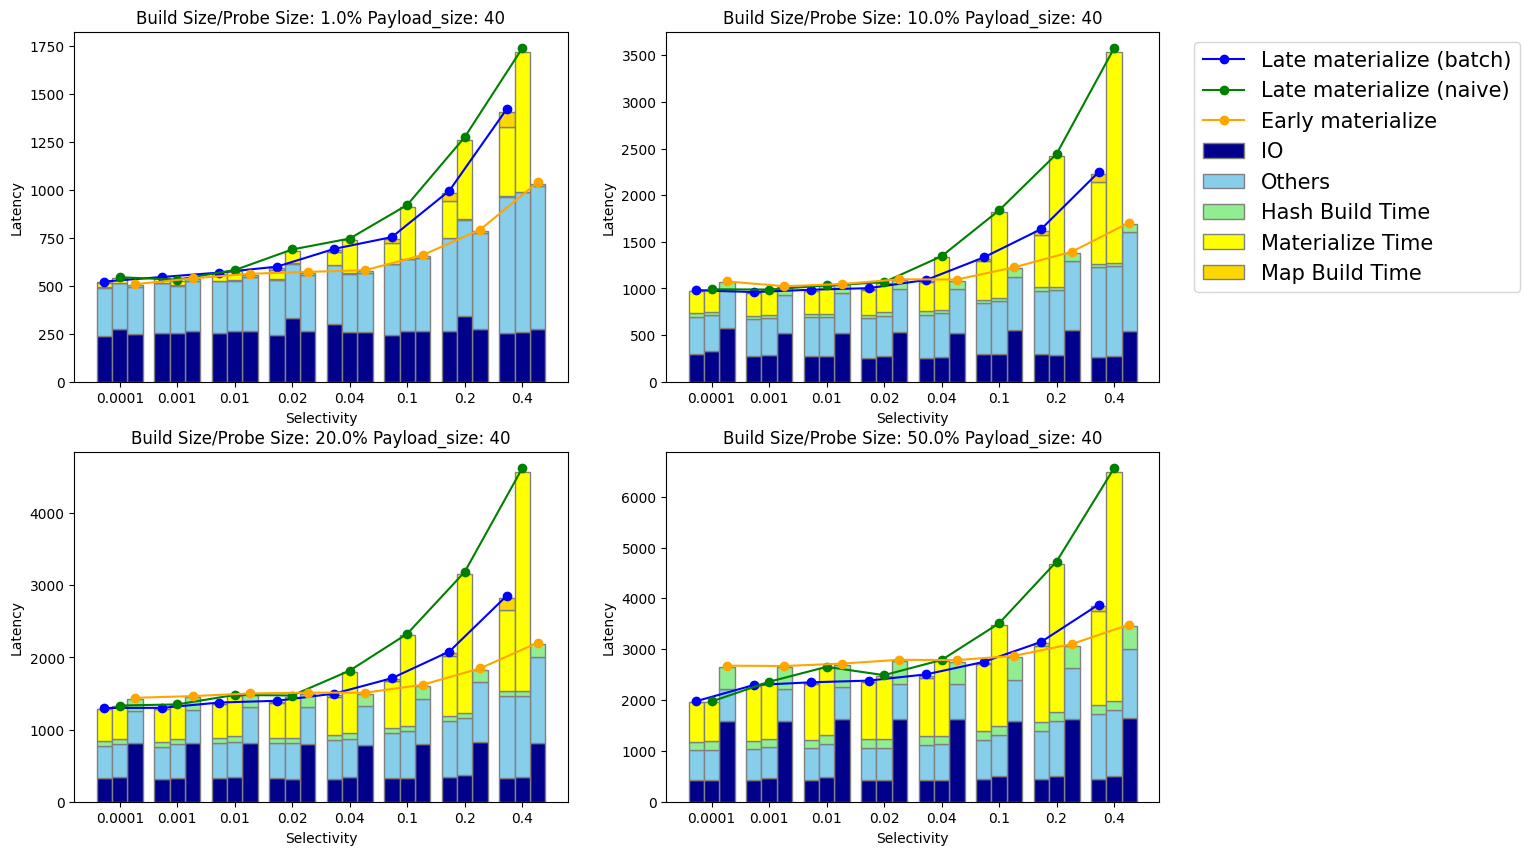

In [3]:
# Example usage
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0115.txt'  # Replace with your file path
df = parse_file(file_path)
plot_data(df)

## compressed storage breakdown

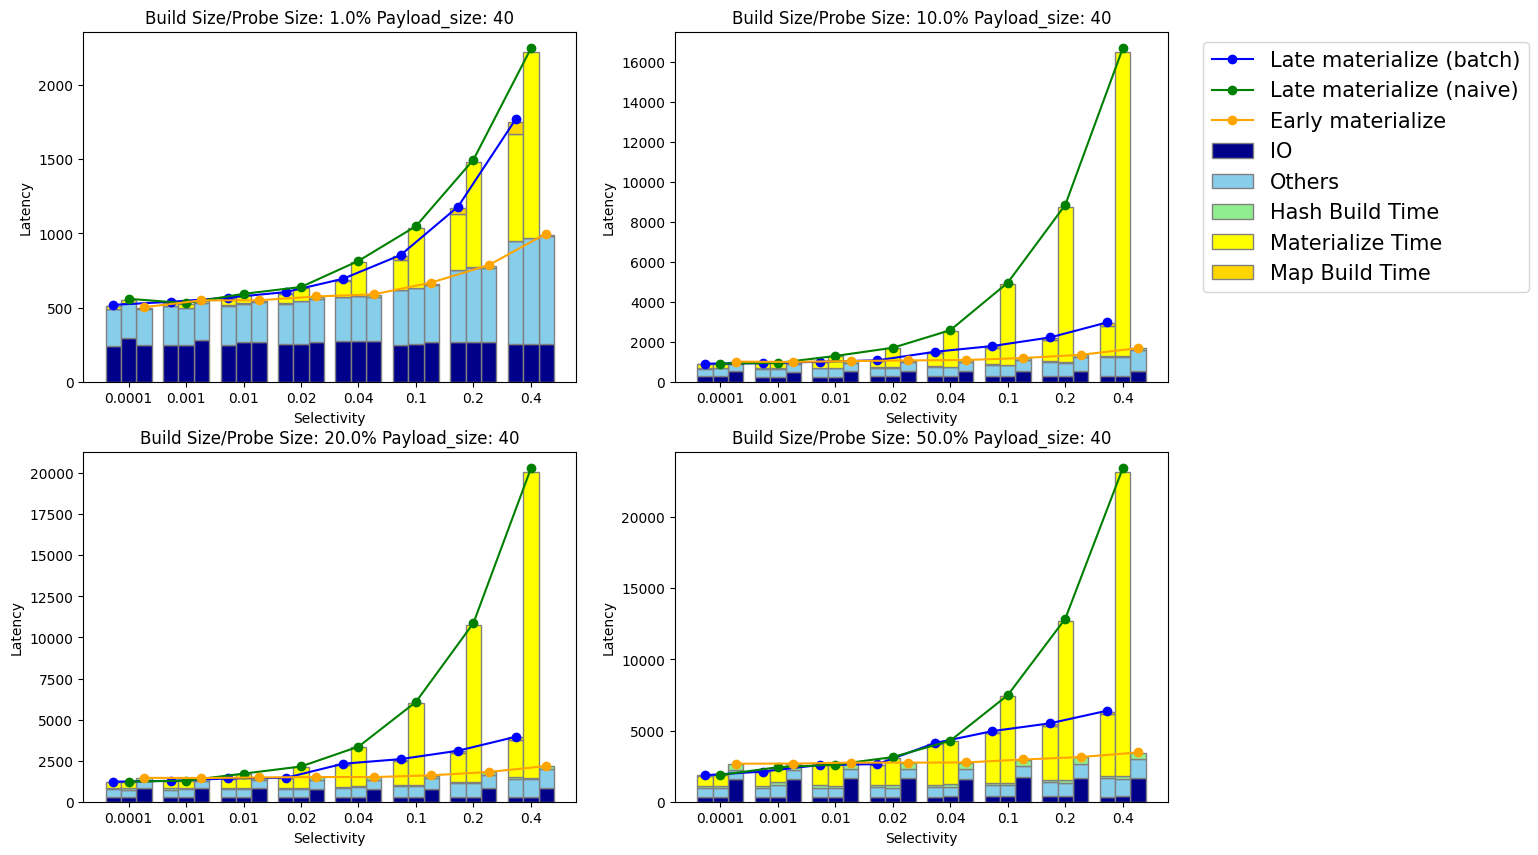

In [4]:
# Example usage
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0115_com.txt'  # Replace with your file path
df = parse_file(file_path)
plot_data(df)

## + unique

In [240]:
import pandas as pd
import matplotlib.pyplot as plt

def parse_file(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[0])
            queue_thr = int(line1[1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])

def plot_data(df):
    color_map = ['darkblue','skyblue','lightgreen','yellow','gold']
    build_sizes = df['build_size'].unique()
    build_sizes.sort()
    payload_size = 40
    num_plots = len(build_sizes)
    num_cols = 2
    num_rows = (num_plots + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_cols,num_rows,figsize=(14, 10))
    for idx, build_size in enumerate(build_sizes):
        row = idx // num_cols
        col = idx % num_cols
        ax = axes[row, col] if num_rows > 1 else axes[col]
        df_build = df[(df['build_size'] == build_size)&(df['payload_size'] ==payload_size)]
        selectivities = df_build['selectivity'].unique()
        selectivities = selectivities[:-1]
        indices = np.arange(len(selectivities))
        indices = 4.0*indices
        bar_width = 0.8
        latencies_0 = []
        latencies_1 = []
        latencies_2 = []
        latencies_3 = []
        for i, selectivity in enumerate(selectivities):
            df_sel = df_build[df_build['selectivity'] == selectivity]
            df_sel_1 = df_sel[df_sel['mat_strat'] == 0]
            df_sel_0 = df_sel[df_sel['mat_strat'] == 1].nsmallest(1, 'latency')
            df_sel_2 = df_sel[df_sel['mat_strat'] == 2]
            df_sel_3 = df_sel[df_sel['mat_strat'] == 3].nsmallest(1, 'latency')
            index = i * 4
            if not df_sel_0.empty:
                #late mat(batch)
                ax.bar(index, df_sel_0['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                ax.bar(index, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                ax.bar(index, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                ax.bar(index, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                ax.bar(index, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                latencies_0.append(df_sel_0['latency'].values[0])
            if not df_sel_3.empty:
                #late mat(batch)
                ax.bar(index + bar_width, df_sel_3['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                ax.bar(index + bar_width, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0],color = color_map[1],edgecolor='grey')
                ax.bar(index + bar_width, df_sel_3['hash_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0],color = color_map[2],edgecolor='grey')
                ax.bar(index + bar_width, df_sel_3['materialize_time'].values[0] , bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                ax.bar(index + bar_width, df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[4],edgecolor='grey')
                latencies_3.append(df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0]+df_sel_3['map_build_time'].values[0])
            if not df_sel_1.empty:
                # early
                ax.bar(index + bar_width*3, df_sel_1['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                ax.bar(index + bar_width*3, df_sel_1['others'].values[0], bar_width, bottom=df_sel_1['io'].values[0], color = color_map[1],edgecolor='grey')
                ax.bar(index + bar_width*3, df_sel_1['hash_build_time'].values[0], bar_width, bottom=df_sel_1['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                latencies_1.append(df_sel_1['latency'].values[0])
            if not df_sel_2.empty:
                #late mat
                ax.bar(index+ bar_width*2, df_sel_2['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                ax.bar(index+ bar_width*2, df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0],  color = color_map[1],edgecolor='grey')
                ax.bar(index+ bar_width*2, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[2],edgecolor='grey')
                ax.bar(index+ bar_width*2, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                latencies_2.append(df_sel_2['latency'].values[0])
        ax.plot(indices, np.array(latencies_0)*1.01, marker='o', color='blue', label='Late materialize (batch)')
        ax.plot(indices+ bar_width, np.array(latencies_3)*1.01, marker='o', color='lightblue', label='Late materialize (unique)')
        ax.plot(indices+ bar_width*2, np.array(latencies_2)*1.01, marker='o', color='green', label='Late materialize (naive)')
        ax.plot(indices + bar_width*3, np.array(latencies_1)*1.01, marker='o', color='orange', label='Early materialize')
        ax.set_xlabel('Selectivity')
        ax.set_ylabel('Latency')
        ax.set_title(f'Build Size/Probe Size: {build_size/200000}% Payload_size: {payload_size}')
        ax.set_xticks([i * 4 + bar_width for i in range(len(selectivities))])
        ax.set_xticklabels(selectivities)
        if row==0 and col==num_cols-1:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15)
    plt.show()



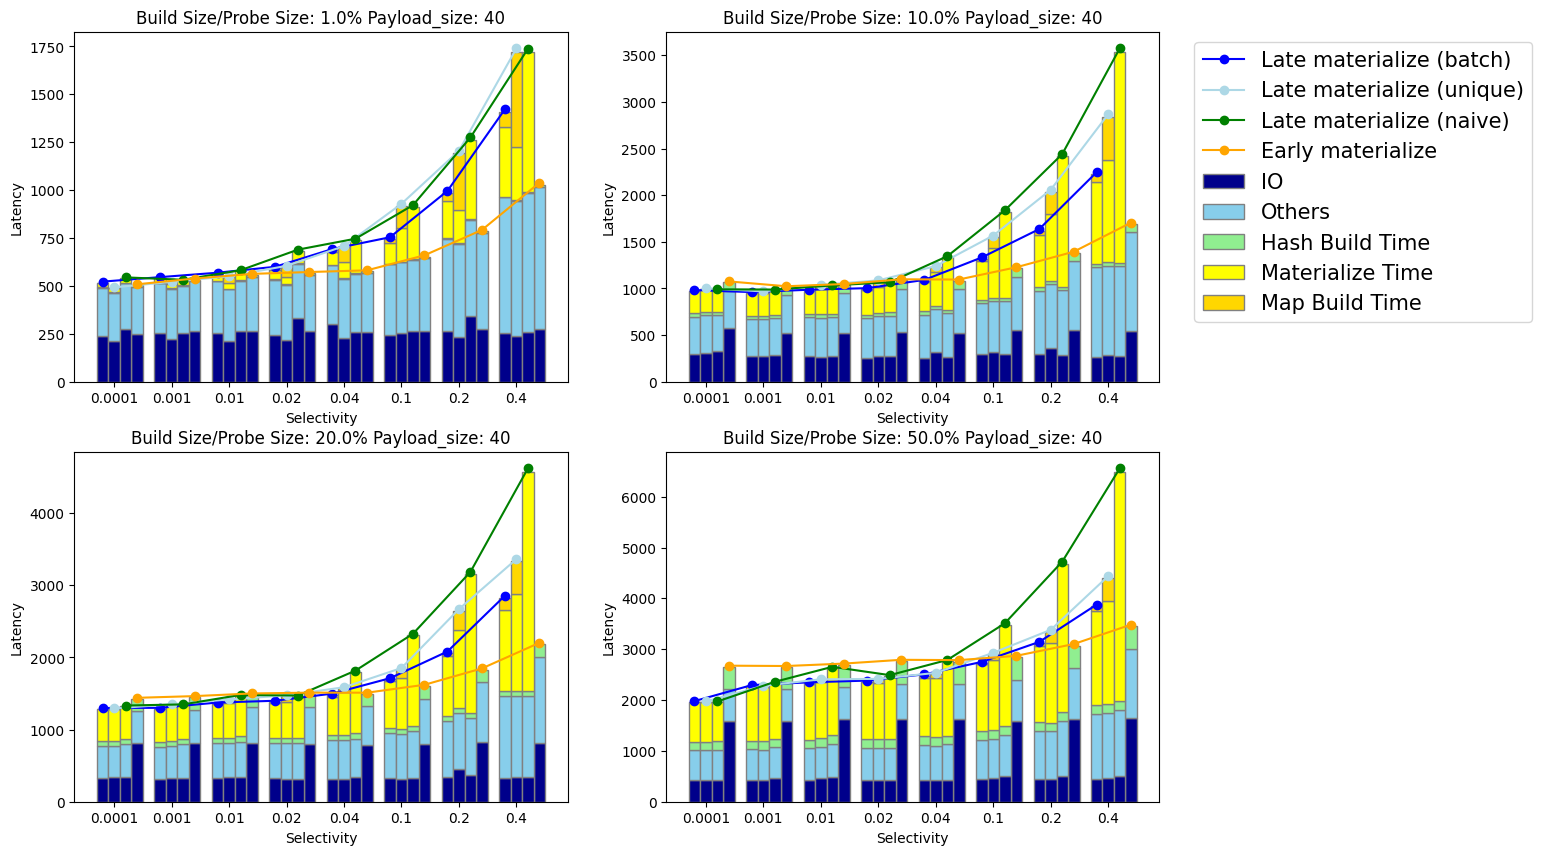

In [241]:
# Example usage
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0115.txt'  # Replace with your file path
df_batch = parse_file(file_path)
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0115_unique.txt'  # Replace with your file path
df = parse_file(file_path)

df_total = pd.concat([df, df_batch],axis=0)
plot_data(df_total)

# breakdown (different payload size)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def parse_file(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip().split()
            line2 = lines[i+1].strip().split()
            mat_strat = int(line1[0])
            queue_thr = int(line1[1])
            build_size = int(line1[2])
            selectivity = float(line1[3])
            payload_size = int(line1[4])
            map_build_time = float(line2[0])
            materialize_time = float(line2[1])
            hash_build_time = float(line2[2])
            others = float(line2[3])
            io = float(line2[4])
            latency = float(line2[5])
            data.append([mat_strat, queue_thr, build_size, selectivity, payload_size, map_build_time, materialize_time, hash_build_time, others, io, latency])
    return pd.DataFrame(data, columns=['mat_strat', 'queue_thr', 'build_size', 'selectivity', 'payload_size', 'map_build_time', 'materialize_time', 'hash_build_time', 'others', 'io', 'latency'])

def plot_data(df):
    color_map = ['darkblue','skyblue','lightgreen','yellow','gold']
    payload_sizes = df['payload_size'].unique()
    payload_sizes = [4,8,10,20,40,41]
    build_size = 4000000
    num_plots = len(payload_sizes)
    num_cols = 3
    num_rows = (num_plots + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows,num_cols,figsize=(15, 10))
    for idx,payload_size in enumerate(payload_sizes):
        row = idx // num_cols
        col = idx % num_cols
        ax = axes[row, col] if num_rows > 1 else axes[col]
        df_build = df[(df['build_size'] == build_size)&(df['payload_size'] ==payload_size)]
        selectivities = df_build['selectivity'].unique()
        selectivities = selectivities[:-1]
        indices = np.arange(len(selectivities))
        indices = 3.0*indices
        bar_width = 0.8
        latencies_0 = []
        latencies_1 = []
        latencies_2 = []
        for i, selectivity in enumerate(selectivities):
            df_sel = df_build[df_build['selectivity'] == selectivity]
            df_sel_1 = df_sel[df_sel['mat_strat'] == 0]
            df_sel_0 = df_sel[df_sel['mat_strat'] == 1].nsmallest(1, 'latency')
            df_sel_2 = df_sel[df_sel['mat_strat'] == 2]
            index = i * 3
            if not df_sel_0.empty:
                #late mat(batch)
                ax.bar(index, df_sel_0['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                ax.bar(index, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                ax.bar(index, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                ax.bar(index, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                ax.bar(index, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                latencies_0.append(df_sel_0['latency'].values[0])
            if not df_sel_1.empty:
                # early
                ax.bar(index + bar_width*2, df_sel_1['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                ax.bar(index + bar_width*2, df_sel_1['others'].values[0], bar_width, bottom=df_sel_1['io'].values[0], color = color_map[1],edgecolor='grey')
                ax.bar(index + bar_width*2, df_sel_1['hash_build_time'].values[0], bar_width, bottom=df_sel_1['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                latencies_1.append(df_sel_1['latency'].values[0])
            if not df_sel_2.empty:
                #late mat
                ax.bar(index+ bar_width, df_sel_2['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                ax.bar(index+ bar_width, df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0],  color = color_map[1],edgecolor='grey')
                ax.bar(index+ bar_width, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[2],edgecolor='grey')
                ax.bar(index+ bar_width, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                latencies_2.append(df_sel_2['latency'].values[0])
        ax.plot(indices, np.array(latencies_0)*1.01, marker='o', color='blue', label='Late materialize (batch)')
        ax.plot(indices+ bar_width, np.array(latencies_2)*1.01, marker='o', color='green', label='Late materialize (naive)')
        ax.plot(indices + bar_width*2, np.array(latencies_1)*1.01, marker='o', color='orange', label='Early materialize')
        ax.set_xlabel('Selectivity')
        ax.set_ylabel('Latency')
        ax.set_title(f'Build Size/Probe Size: {build_size/200000}% Payload_size: {payload_size}')
        ax.set_xticks([i * 3 + bar_width for i in range(len(selectivities))])
        ax.set_xticklabels(selectivities)
        if row==0 and col==num_cols-1:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=14)
    plt.show()



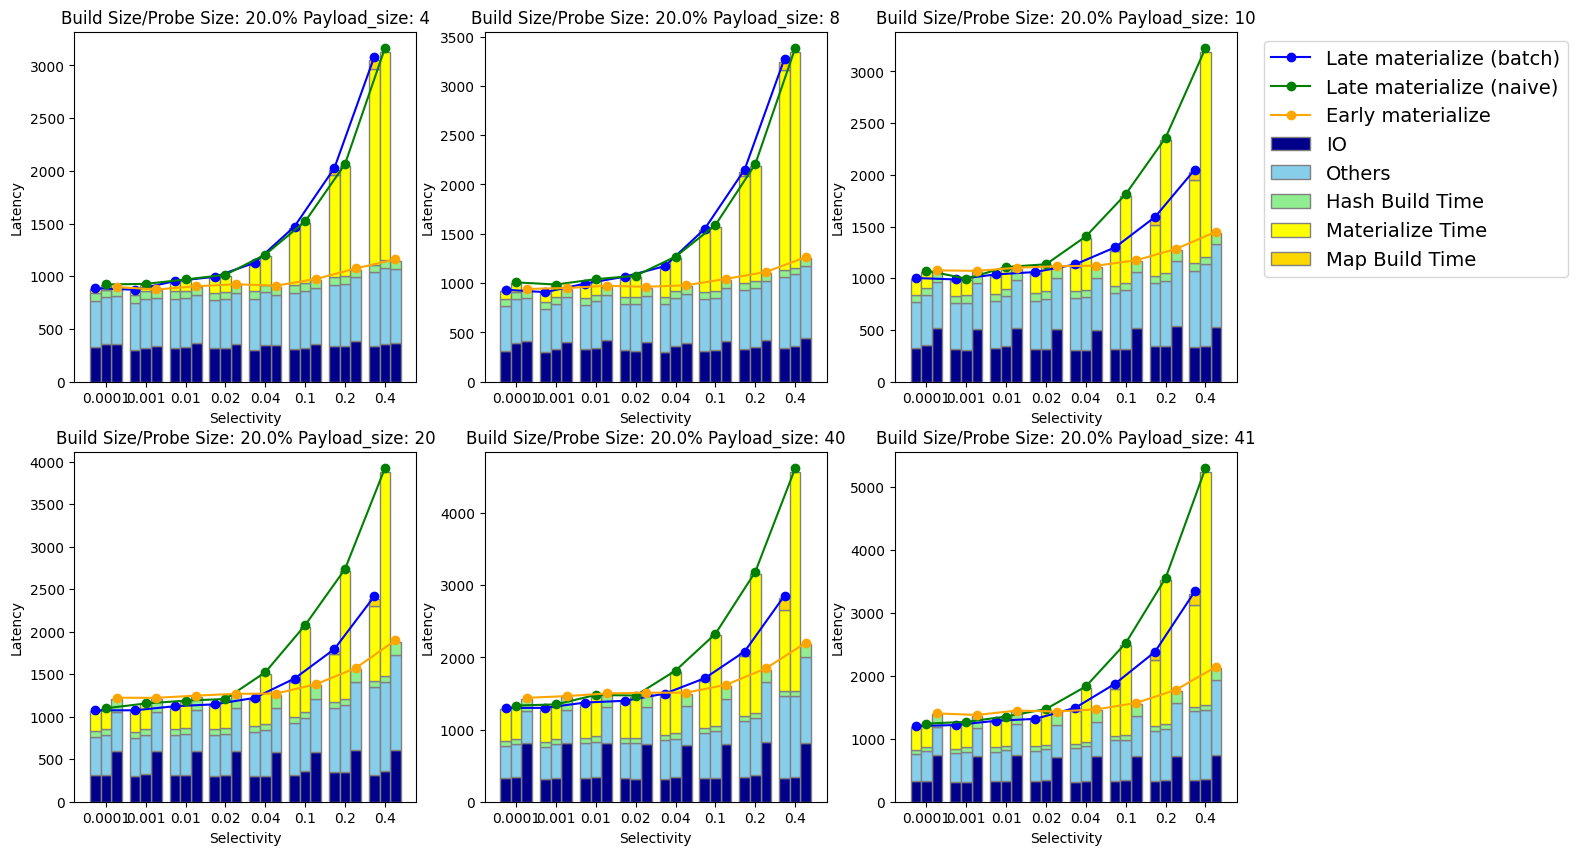

In [10]:
# Example usage
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0115.txt'  # Replace with your file path
df = parse_file(file_path)
plot_data(df)

## compressed storage breakdown

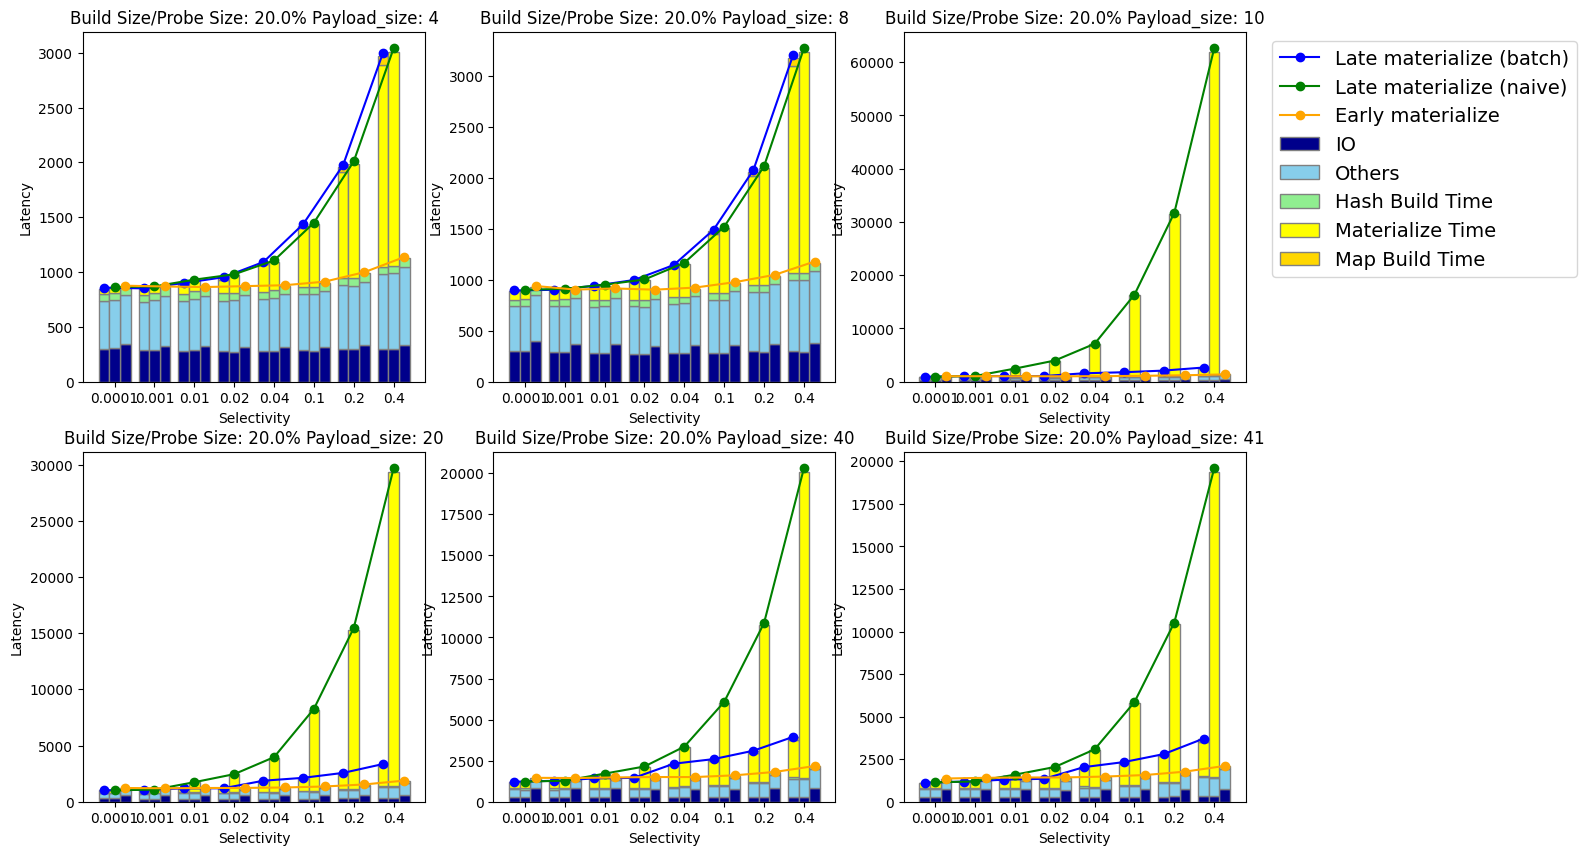

In [11]:
# Example usage
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0115_com.txt'  # Replace with your file path
df = parse_file(file_path)
plot_data(df)

# skew + unique

In [120]:
# Example usage
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0115_skew_batch.txt'  # Replace with your file path
df_batch = parse_file(file_path)
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0115_skew.txt'  # Replace with your file path
df = parse_file(file_path)

df_total = pd.concat([df, df_batch],axis=0)
df_total

,mat_strat,queue_thr,build_size,selectivity,payload_size,map_build_time,materialize_time,hash_build_time,others,io,latency
0,0,0,2000000,0.0001,4,0.00,0.00,38.69,442.30,293.14,774.13
1,2,0,2000000,0.0001,4,0.00,3.53,35.29,442.23,289.37,766.90
2,1,100,2000000,0.0001,4,0.05,3.18,34.84,440.29,286.62,761.75
3,1,1000,2000000,0.0001,4,0.67,2.98,35.82,434.27,288.25,758.34
4,1,2000,2000000,0.0001,4,0.38,3.07,35.35,467.41,295.83,798.60
...,...,...,...,...,...,...,...,...,...,...,...
643,3,1000,10000000,0.8000,40,238.75,647.53,170.81,2033.98,439.52,2644.31
644,3,2000,10000000,0.8000,40,261.62,701.44,176.51,2113.26,437.19,2726.97
645,3,100,10000000,0.8000,41,158.65,992.17,172.64,2269.25,435.68,2877.57
646,3,1000,10000000,0.8000,41,238.67,1021.81,170.50,2382.50,446.18,2999.18


In [5]:
def plot_data(df):
    color_map = ['darkblue','skyblue','lightgreen','yellow','gold']
    payload_sizes = df['payload_size'].unique()
    payload_sizes = [4,8,10,20,40,41]
    build_size = 4000000
    num_plots = len(payload_sizes)
    num_cols = 3
    num_rows = (num_plots + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows,num_cols,figsize=(18, 10))
    for idx,payload_size in enumerate(payload_sizes):
        row = idx // num_cols
        col = idx % num_cols
        ax = axes[row, col] if num_rows > 1 else axes[col]
        df_build = df[(df['build_size'] == build_size)&(df['payload_size'] ==payload_size)]
        selectivities = df_build['selectivity'].unique()
        # selectivities = selectivities[:-1]
        indices = np.arange(len(selectivities))
        indices = 4.0*indices
        bar_width = 0.8
        latencies_0 = []
        latencies_1 = []
        latencies_2 = []
        latencies_3 = []
        for i, selectivity in enumerate(selectivities):
            df_sel = df_build[df_build['selectivity'] == selectivity]
            df_sel_1 = df_sel[df_sel['mat_strat'] == 0]
            df_sel_0 = df_sel[df_sel['mat_strat'] == 1].nsmallest(1, 'latency')
            df_sel_2 = df_sel[df_sel['mat_strat'] == 2]
            df_sel_3 = df_sel[df_sel['mat_strat'] == 3].nsmallest(1, 'latency')
            index = i * 4
            if not df_sel_0.empty:
                #late mat(batch)
                ax.bar(index, df_sel_0['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                ax.bar(index, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                ax.bar(index, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                ax.bar(index, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                ax.bar(index, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                latencies_0.append(df_sel_0['latency'].values[0])
            if not df_sel_3.empty:
                #late mat(batch)
                ax.bar(index+ bar_width, df_sel_3['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                ax.bar(index+ bar_width, df_sel_3['others'].values[0]-df_sel_3['materialize_time'].values[0]-df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0],color = color_map[1],edgecolor='grey')
                ax.bar(index+ bar_width, df_sel_3['hash_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_3['others'].values[0]-df_sel_3['materialize_time'].values[0]-df_sel_3['map_build_time'].values[0],color = color_map[2],edgecolor='grey')
                ax.bar(index+ bar_width, df_sel_3['materialize_time'].values[0] , bar_width, bottom=df_sel_3['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0]-df_sel_3['materialize_time'].values[0]-df_sel_3['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                ax.bar(index+ bar_width, df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_3['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_3['materialize_time'].values[0]-df_sel_3['map_build_time'].values[0], color = color_map[4],edgecolor='grey')
                latencies_3.append(df_sel_3['latency'].values[0])
            if not df_sel_1.empty:
                # early
                ax.bar(index + bar_width*3, df_sel_1['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                ax.bar(index + bar_width*3, df_sel_1['others'].values[0], bar_width, bottom=df_sel_1['io'].values[0], color = color_map[1],edgecolor='grey')
                ax.bar(index + bar_width*3, df_sel_1['hash_build_time'].values[0], bar_width, bottom=df_sel_1['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                latencies_1.append(df_sel_1['latency'].values[0])
            if not df_sel_2.empty:
                #late mat
                ax.bar(index+ bar_width*2, df_sel_2['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                ax.bar(index+ bar_width*2, df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0],  color = color_map[1],edgecolor='grey')
                ax.bar(index+ bar_width*2, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[2],edgecolor='grey')
                ax.bar(index+ bar_width*2, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                latencies_2.append(df_sel_2['latency'].values[0])
        ax.plot(indices, np.array(latencies_0)*1.01, marker='o', color='blue', label='Late materialize (batch+ unique)')
        ax.plot(indices+ bar_width, np.array(latencies_3)*1.01, marker='o', color='lightblue', label='Late materialize (batch)')
        ax.plot(indices+ bar_width*2, np.array(latencies_2)*1.01, marker='o', color='green', label='Late materialize (naive)')
        ax.plot(indices + bar_width*3, np.array(latencies_1)*1.01, marker='o', color='orange', label='Early materialize')
        ax.set_xlabel('Selectivity')
        ax.set_ylabel('Latency')
        ax.set_title(f'Build Size/Probe Size: {build_size/200000}% Payload_size: {payload_size}, Zipfian skew')
        ax.set_xticks([i * 4 + bar_width for i in range(len(selectivities))])
        ax.set_xticklabels(selectivities)
        if row==0 and col==num_cols-1:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=14)
    plt.show()



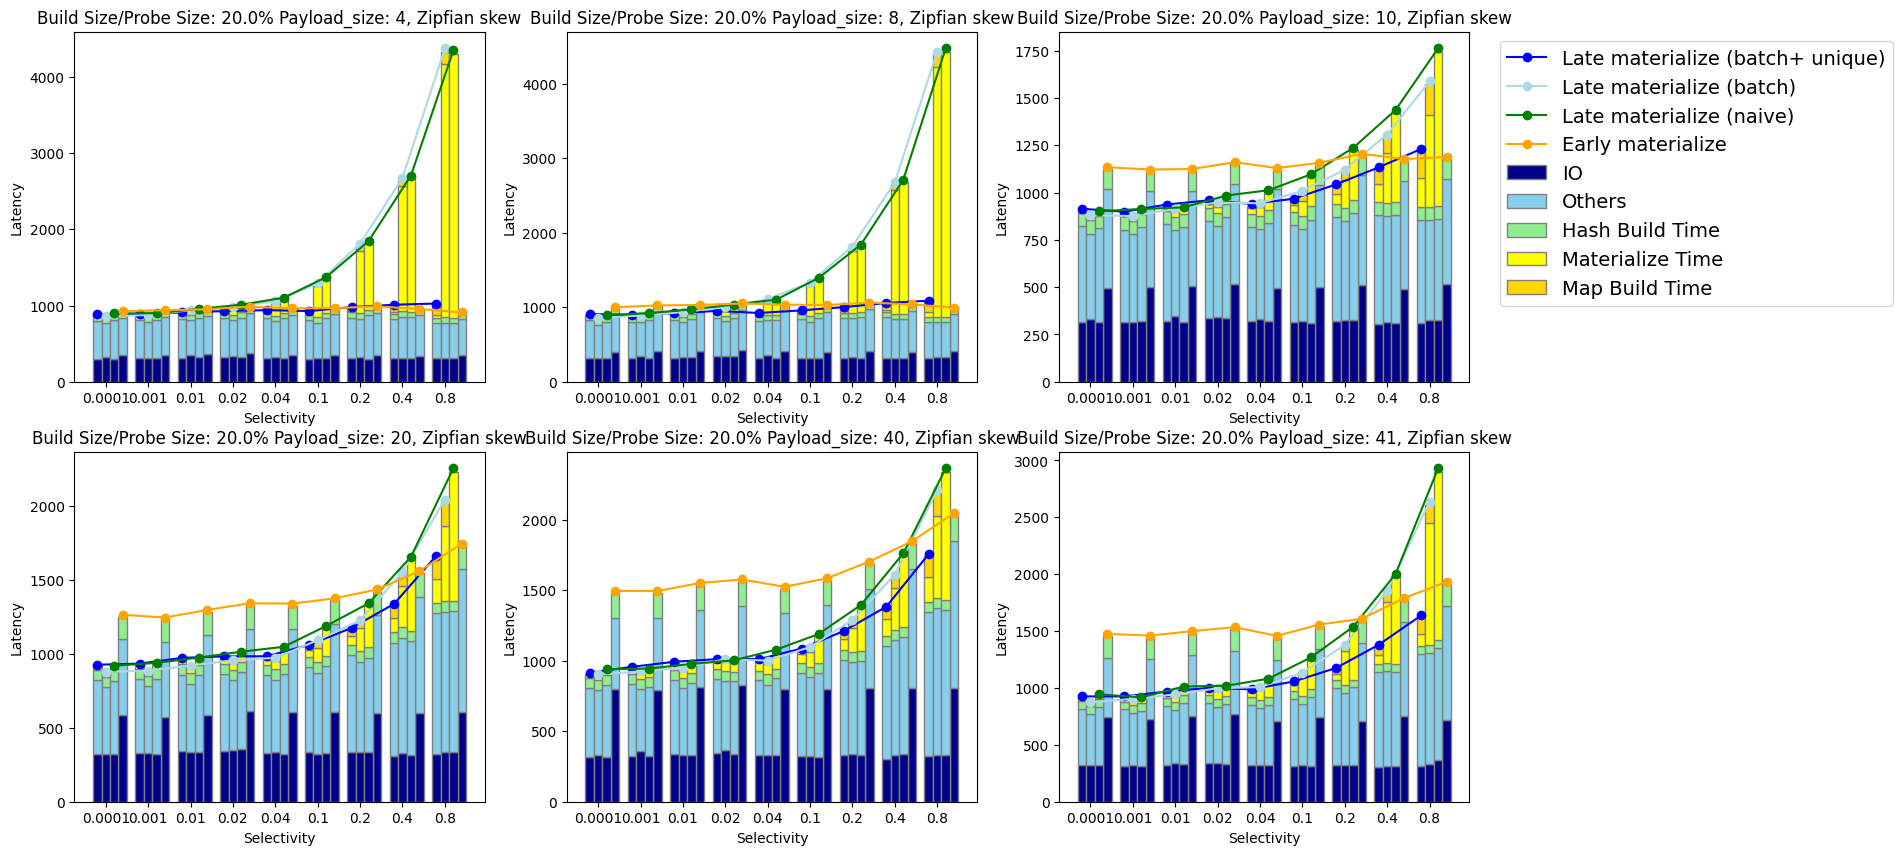

In [6]:
plot_data(df_total)

## +unique

In [10]:
def plot_data(df):
    color_map = ['darkblue','skyblue','lightgreen','yellow','gold']
    payload_sizes = df['payload_size'].unique()
    payload_sizes = [4,8,10,20,40,41]
    build_size = 10000000
    num_plots = len(payload_sizes)
    num_cols = 3
    num_rows = (num_plots + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows,num_cols,figsize=(18, 10))
    for idx,payload_size in enumerate(payload_sizes):
        row = idx // num_cols
        col = idx % num_cols
        ax = axes[row, col] if num_rows > 1 else axes[col]
        df_build = df[(df['build_size'] == build_size)&(df['payload_size'] ==payload_size)]
        selectivities = df_build['selectivity'].unique()
        selectivities = selectivities[:-1]
        indices = np.arange(len(selectivities))
        indices = 4.0*indices
        bar_width = 0.8
        latencies_0 = []
        latencies_1 = []
        latencies_2 = []
        latencies_3 = []
        for i, selectivity in enumerate(selectivities):
            df_sel = df_build[df_build['selectivity'] == selectivity]
            df_sel_1 = df_sel[df_sel['mat_strat'] == 0]
            df_sel_0 = df_sel[df_sel['mat_strat'] == 1].nsmallest(1, 'latency')
            df_sel_2 = df_sel[df_sel['mat_strat'] == 2]
            df_sel_3 = df_sel[df_sel['mat_strat'] == 3].nsmallest(1, 'latency')
            index = i * 4
            if not df_sel_0.empty:
                #late mat(batch)
                ax.bar(index+ bar_width, df_sel_0['io'].values[0], bar_width, label='IO' if i == 0 else "", color = color_map[0],edgecolor='grey')
                ax.bar(index+ bar_width, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0], label='Others' if i == 0 else "", color = color_map[1],edgecolor='grey')
                ax.bar(index+ bar_width, df_sel_0['hash_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Hash Build Time' if i == 0 else "", color = color_map[2],edgecolor='grey')
                ax.bar(index+ bar_width, df_sel_0['materialize_time'].values[0] , bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Materialize Time' if i == 0 else "", color = color_map[3],edgecolor='grey')
                ax.bar(index+ bar_width, df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_0['io'].values[0] + df_sel_0['others'].values[0] + df_sel_0['hash_build_time'].values[0]+ df_sel_0['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], label='Map Build Time' if i == 0 else "", color = color_map[4],edgecolor='grey')
                latencies_0.append(df_sel_0['latency'].values[0])
            if not df_sel_3.empty:
                #late mat(batch)
                ax.bar(index, df_sel_3['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                ax.bar(index, df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0],color = color_map[1],edgecolor='grey')
                ax.bar(index, df_sel_3['hash_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0],color = color_map[2],edgecolor='grey')
                ax.bar(index, df_sel_3['materialize_time'].values[0] , bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                ax.bar(index, df_sel_3['map_build_time'].values[0], bar_width, bottom=df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0], color = color_map[4],edgecolor='grey')
                latencies_3.append(df_sel_3['io'].values[0] + df_sel_0['others'].values[0] + df_sel_3['hash_build_time'].values[0]+ df_sel_3['materialize_time'].values[0]-df_sel_0['materialize_time'].values[0]-df_sel_0['map_build_time'].values[0]+df_sel_3['map_build_time'].values[0])
            if not df_sel_1.empty:
                # early
                ax.bar(index + bar_width*3, df_sel_1['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                ax.bar(index + bar_width*3, df_sel_1['others'].values[0], bar_width, bottom=df_sel_1['io'].values[0], color = color_map[1],edgecolor='grey')
                ax.bar(index + bar_width*3, df_sel_1['hash_build_time'].values[0], bar_width, bottom=df_sel_1['io'].values[0] + df_sel_1['others'].values[0], color = color_map[2],edgecolor='grey')
                latencies_1.append(df_sel_1['latency'].values[0])
            if not df_sel_2.empty:
                #late mat
                ax.bar(index+ bar_width*2, df_sel_2['io'].values[0], bar_width, color = color_map[0],edgecolor='grey')
                ax.bar(index+ bar_width*2, df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0],  color = color_map[1],edgecolor='grey')
                ax.bar(index+ bar_width*2, df_sel_2['hash_build_time'].values[0], bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[2],edgecolor='grey')
                ax.bar(index+ bar_width*2, df_sel_2['materialize_time'].values[0] , bar_width, bottom=df_sel_2['io'].values[0] + df_sel_2['others'].values[0] + df_sel_2['hash_build_time'].values[0]-df_sel_2['materialize_time'].values[0]-df_sel_2['map_build_time'].values[0], color = color_map[3],edgecolor='grey')
                latencies_2.append(df_sel_2['latency'].values[0])
        ax.plot(indices, np.array(latencies_3)*1.01, marker='o', color='blue', label='LM (unique)')
        ax.plot(indices+bar_width, np.array(latencies_0)*1.01, marker='o', color='lightblue', label='LM (batch)')
        ax.plot(indices+ bar_width*2, np.array(latencies_2)*1.01, marker='o', color='green', label='LM (naive)')
        ax.plot(indices + bar_width*3, np.array(latencies_1)*1.01, marker='o', color='orange', label='EM')
        ax.set_xlabel('Selectivity')
        ax.set_ylabel('Latency')
        ax.set_title(f'Build Size/Probe Size: {build_size/200000}% Payload_size: {payload_size}')
        ax.set_xticks([i * 4 + bar_width for i in range(len(selectivities))])
        ax.set_xticklabels(selectivities)
        if row==0 and col==num_cols-1:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=14)
    plt.show()



In [11]:
# Example usage
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0115.txt'  # Replace with your file path
df_batch = parse_file(file_path)
file_path = '/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/breakdown_0115_unique.txt'  # Replace with your file path
df = parse_file(file_path)

df_total = pd.concat([df, df_batch],axis=0)


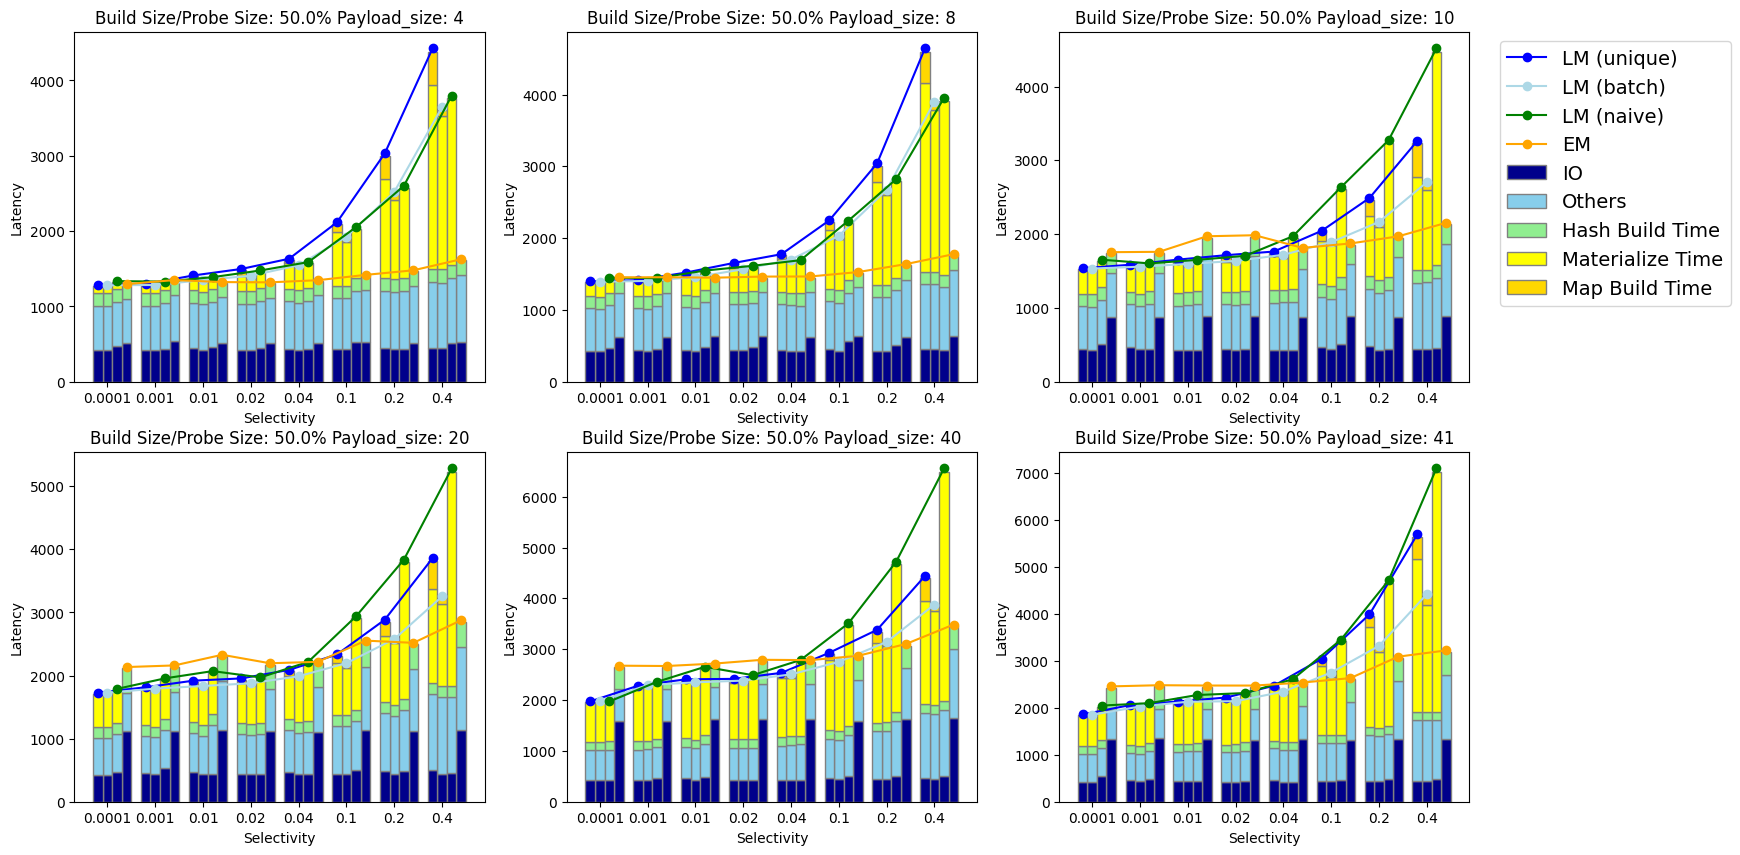

In [12]:
plot_data(df_total)

# OOM

In [2]:
import pandas as pd

def parse_file(file_path):
    # 定义列名
    columns = ["result_size", "mem_lim", "mode", "thread", "probe_side", "build_side", "sel", "payload", "dist", "hit_ratio", "build_dis", "probe_dis", "latency"]
    
    # 读取文件并创建DataFrame
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            early_mat = lines[i].strip().split()
            late_mat = lines[i+1].strip().split()
            data.append(early_mat)
            data.append(late_mat)
    
    df = pd.DataFrame(data, columns=columns)
    df = df.replace(to_replace='None', value=np.nan).dropna()
    strat = []
    for i in range(0,len(df),2):
        strat.append(0)
        strat.append(1)
        
    # 将数值列转换为合适的类型
    df["result_size"] = df["result_size"].astype(float)
    df["mem_lim"] = df["mem_lim"]
    df["thread"] = df["thread"].astype(int)
    df["probe_side"] = df["probe_side"].astype(int)
    df["build_side"] = df["build_side"].astype(int)
    df["sel"] = df["sel"].astype(float)
    df["payload"] = df["payload"].astype(int)
    df["hit_ratio"] = df["hit_ratio"].astype(float)
    df["latency"] = df["latency"].astype(float)
    df['mat_strat'] = strat

    df = df[df['result_size']!=0]
    return df

def group_data(df):
    grouped = df.groupby(["payload", "sel", "build_side"])
    return grouped





In [114]:
def plot_group(group, name):
    early_mat = group[group["mat_strat"] == 0]
    late_mat = group[group["mat_strat"] == 1]
    
    plt.figure()
    plt.plot(early_mat["mem_lim"], early_mat["latency"], label="Early Mat", marker='o')
    plt.plot(late_mat["mem_lim"], late_mat["latency"], label="Late Mat", marker='o')
    plt.xlabel("Memory Limit (mem_lim)")
    plt.ylabel("Latency")
    plt.title(f"Group: payload={name[0]}, sel={name[1]}, build_side={name[2]}")
    plt.legend()
    plt.show()

Group: payload=10, sel=0.001, build_side=1000000


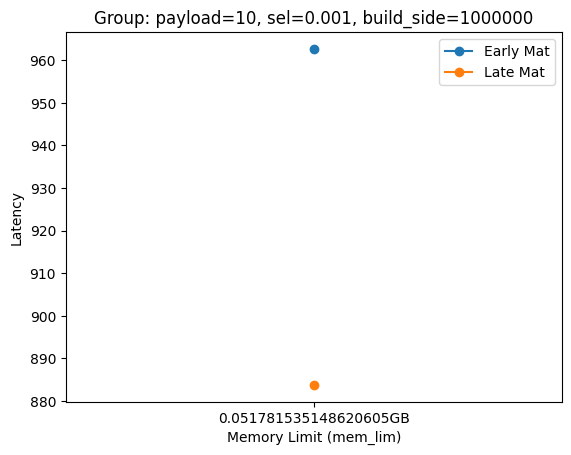

Group: payload=10, sel=0.001, build_side=10000000


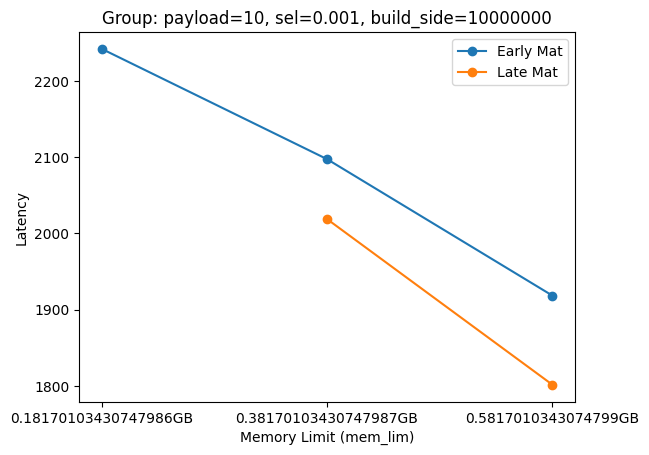

Group: payload=10, sel=0.001, build_side=15000000


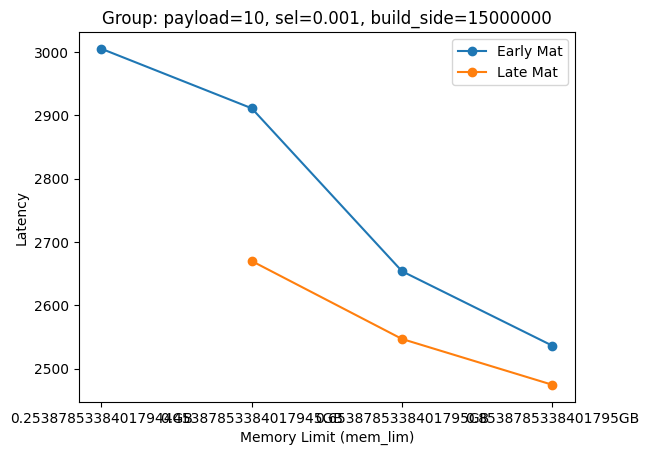

Group: payload=10, sel=0.01, build_side=1000000


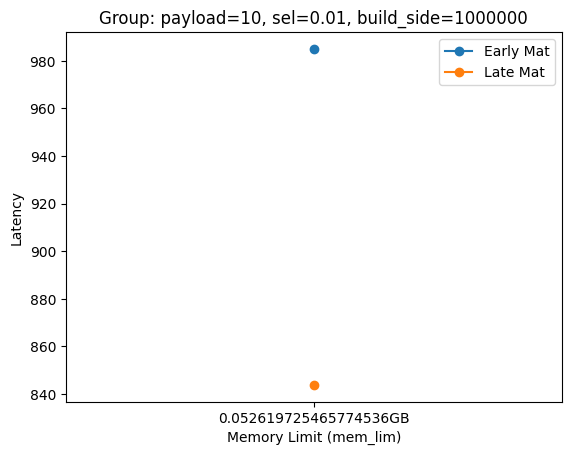

Group: payload=10, sel=0.01, build_side=10000000


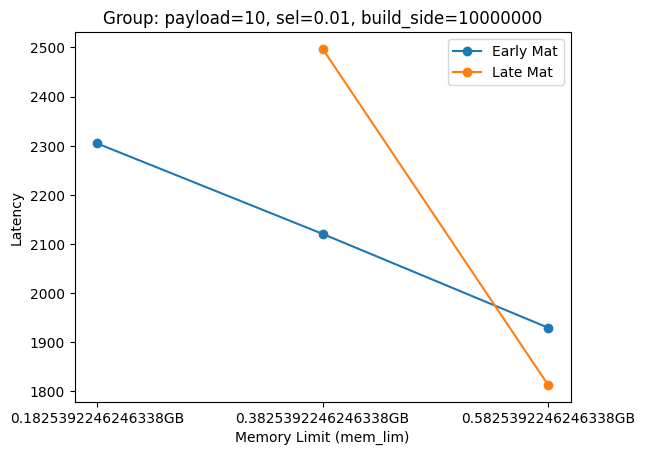

Group: payload=10, sel=0.01, build_side=15000000


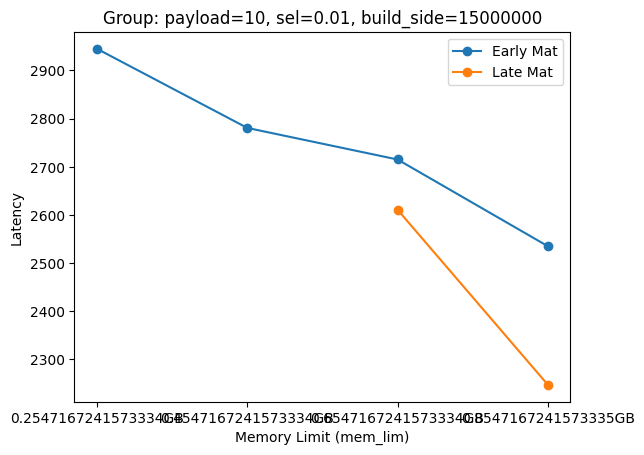

Group: payload=10, sel=0.1, build_side=1000000


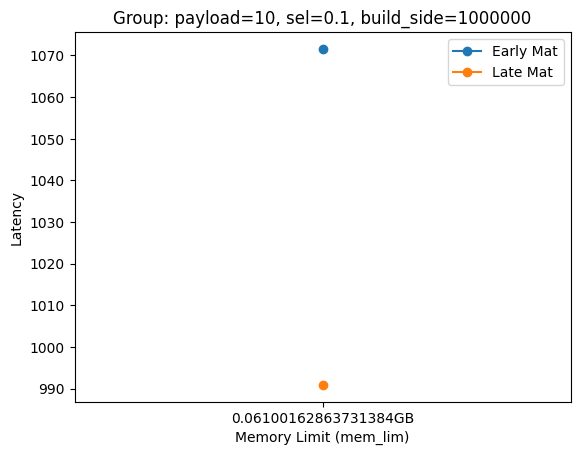

Group: payload=10, sel=0.1, build_side=10000000


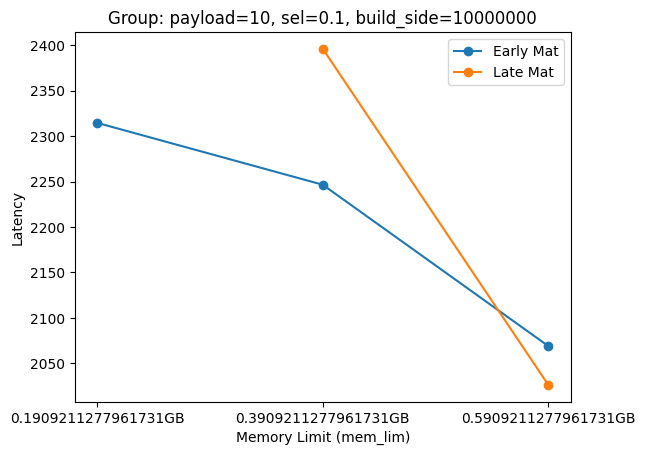

Group: payload=10, sel=0.1, build_side=15000000


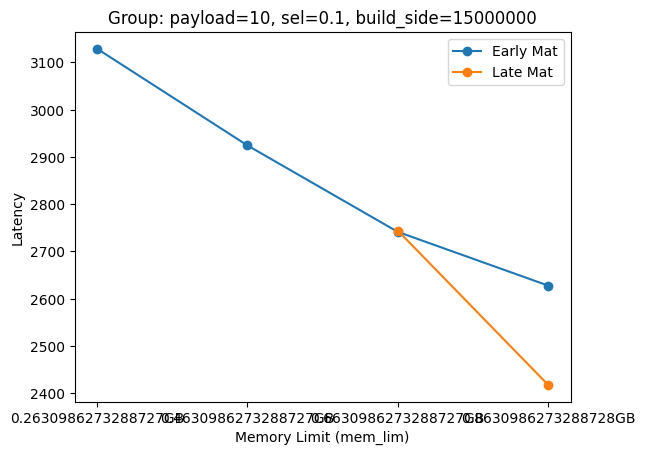

Group: payload=10, sel=0.2, build_side=1000000


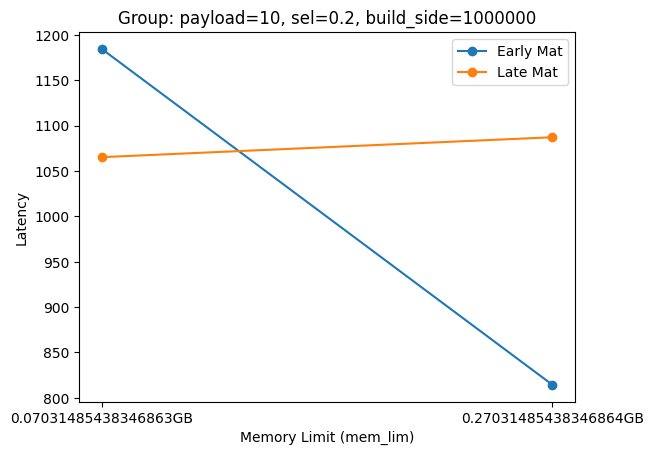

Group: payload=10, sel=0.2, build_side=10000000


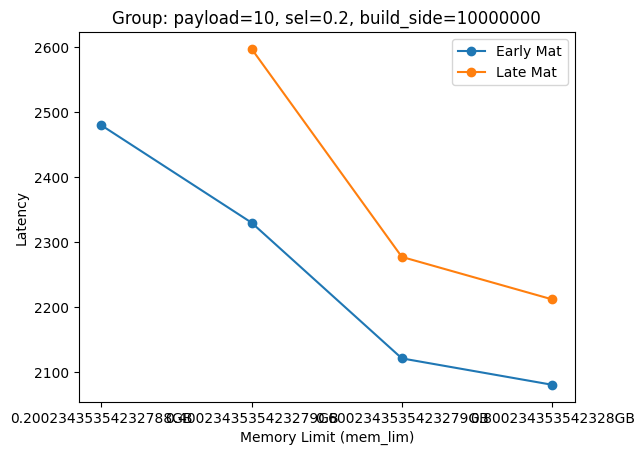

Group: payload=10, sel=0.2, build_side=15000000


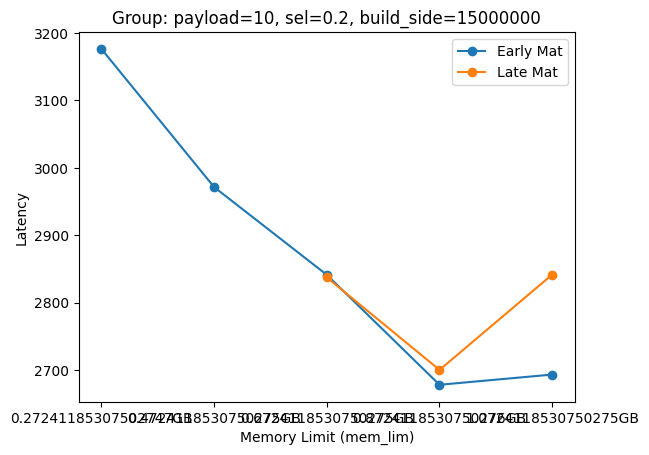

Group: payload=20, sel=0.001, build_side=1000000


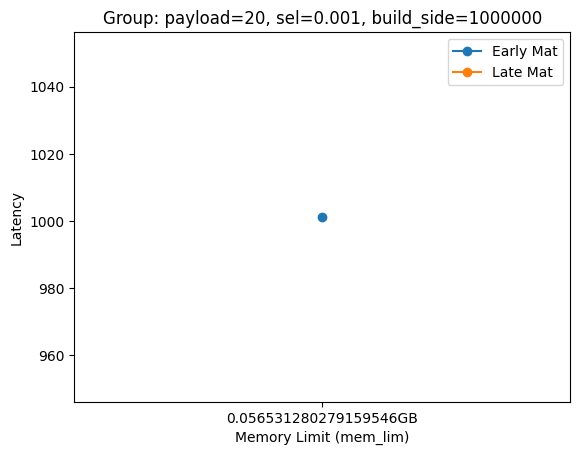

Group: payload=20, sel=0.001, build_side=10000000


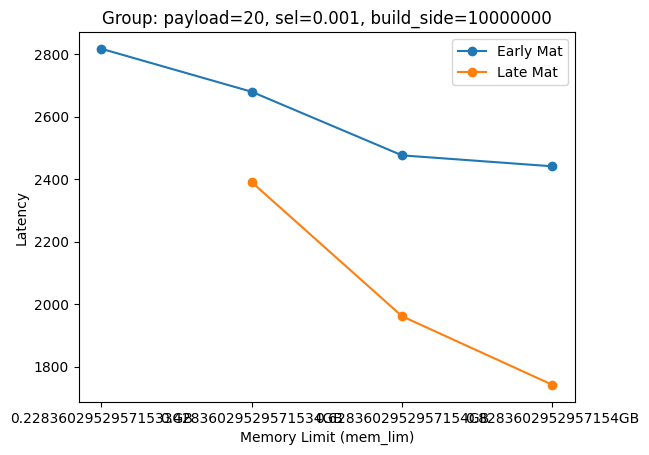

Group: payload=20, sel=0.001, build_side=15000000


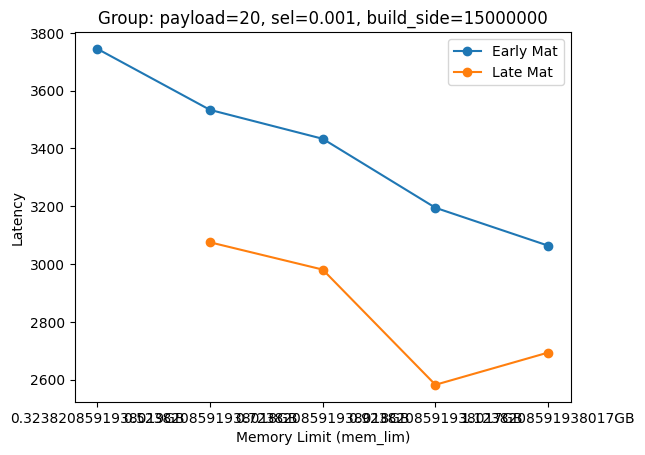

Group: payload=20, sel=0.01, build_side=1000000


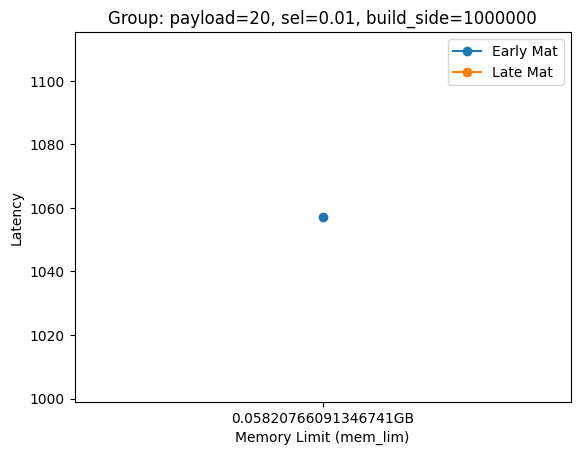

Group: payload=20, sel=0.01, build_side=10000000


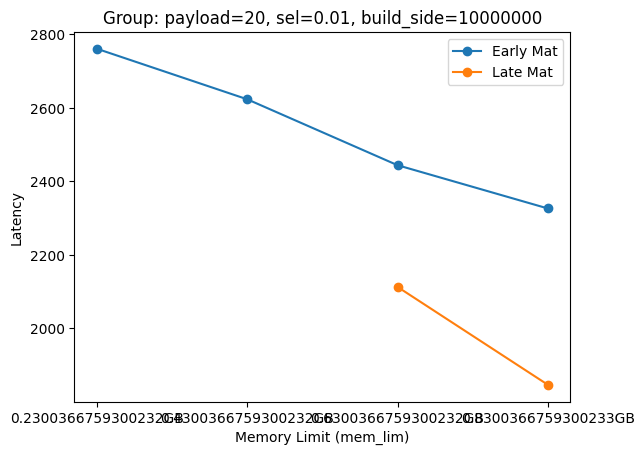

Group: payload=20, sel=0.01, build_side=15000000


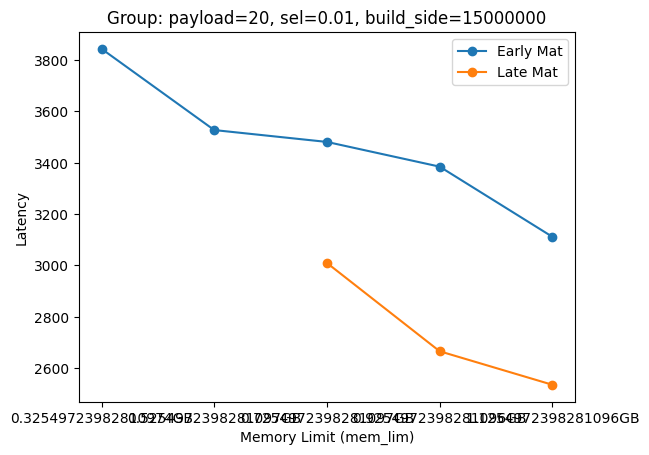

Group: payload=20, sel=0.1, build_side=1000000


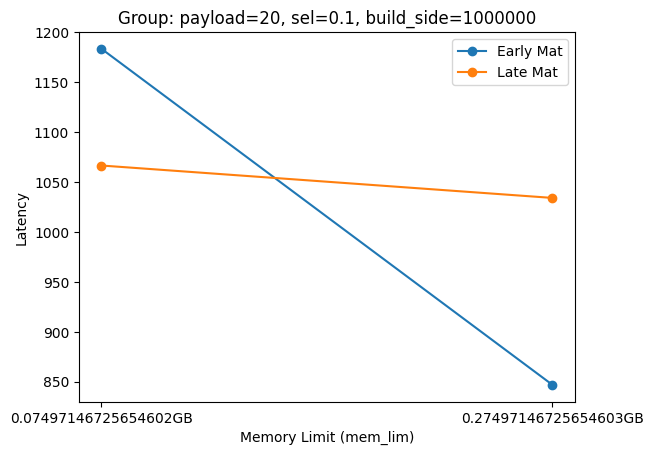

Group: payload=20, sel=0.1, build_side=10000000


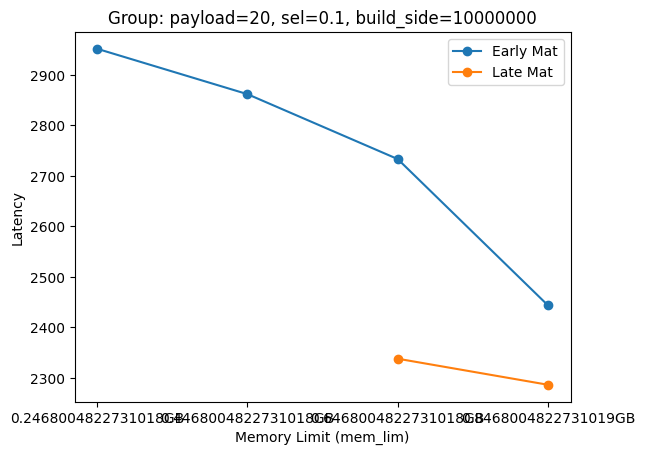

Group: payload=20, sel=0.1, build_side=15000000


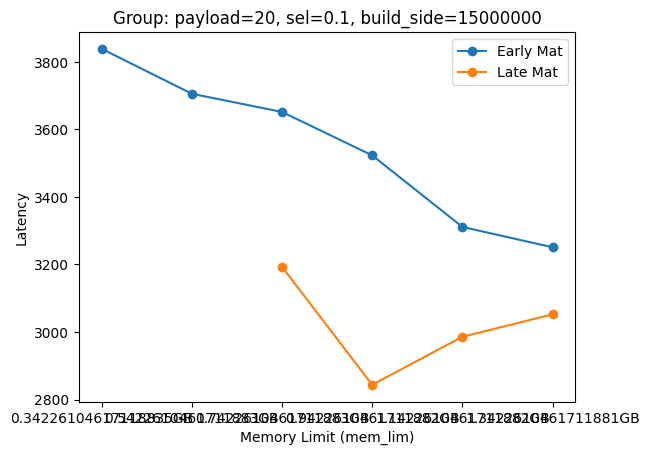

Group: payload=20, sel=0.2, build_side=1000000


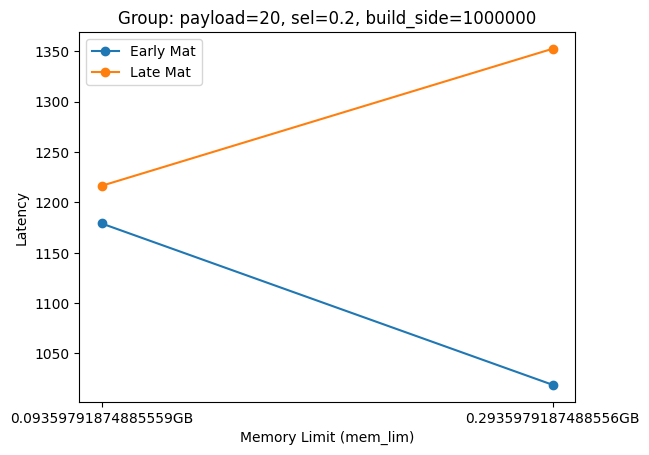

Group: payload=20, sel=0.2, build_side=10000000


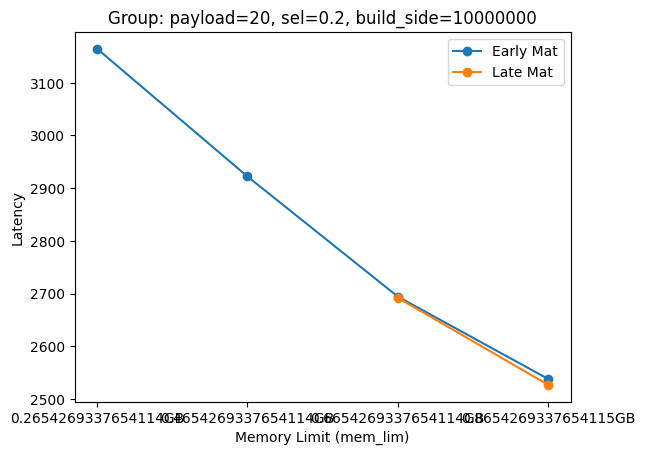

Group: payload=20, sel=0.2, build_side=15000000


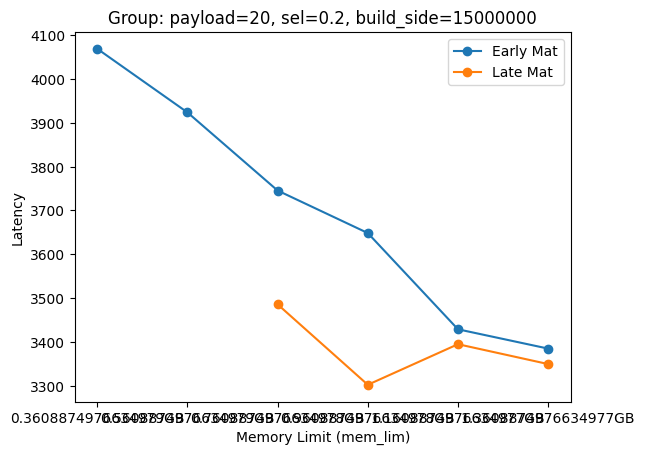

Group: payload=40, sel=0.001, build_side=1000000


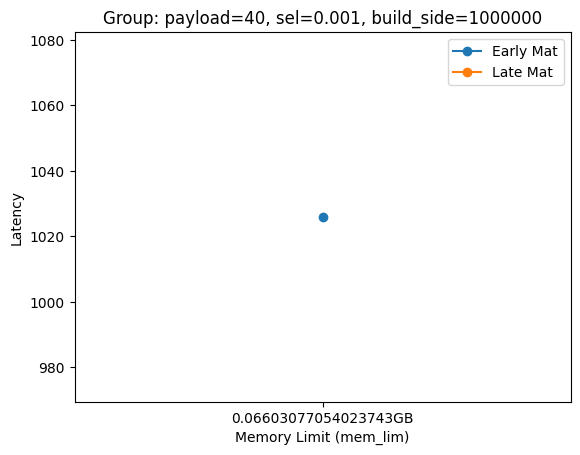

Group: payload=40, sel=0.001, build_side=10000000


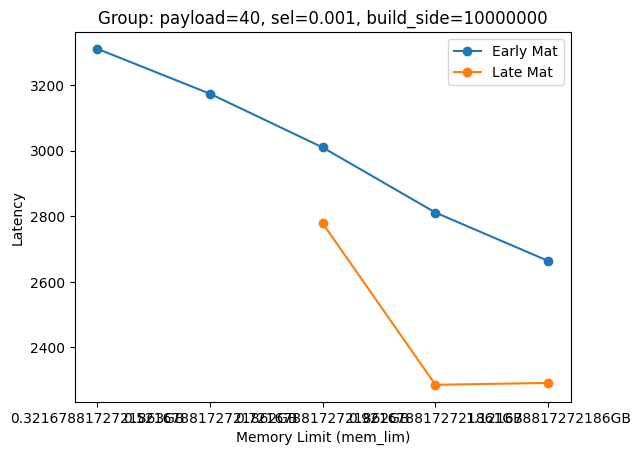

Group: payload=40, sel=0.001, build_side=15000000


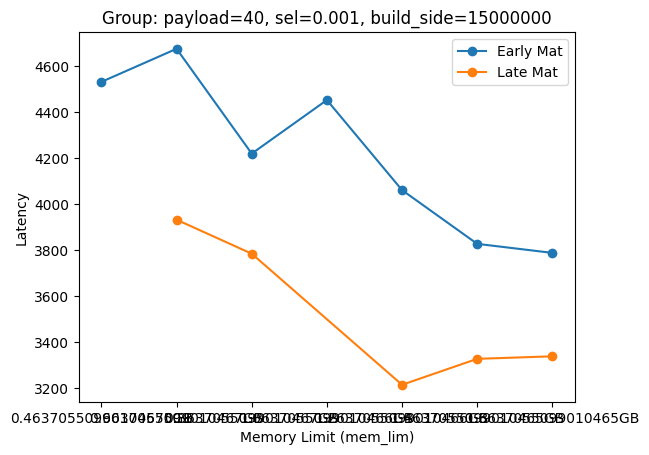

Group: payload=40, sel=0.01, build_side=1000000


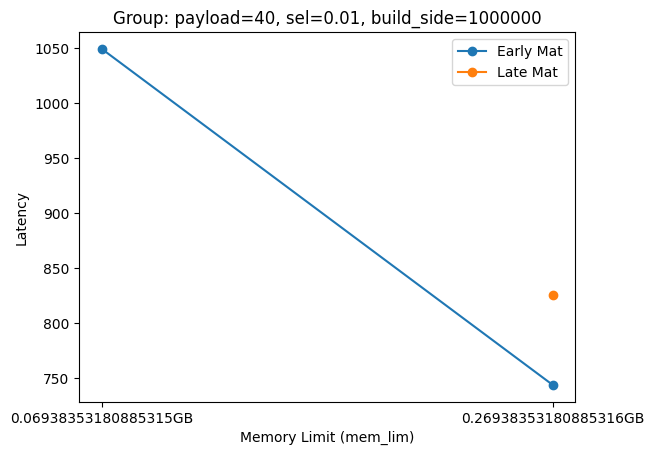

Group: payload=40, sel=0.01, build_side=10000000


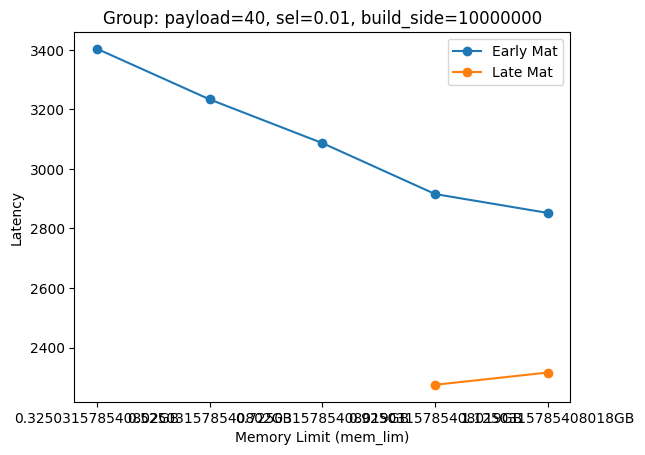

Group: payload=40, sel=0.01, build_side=15000000


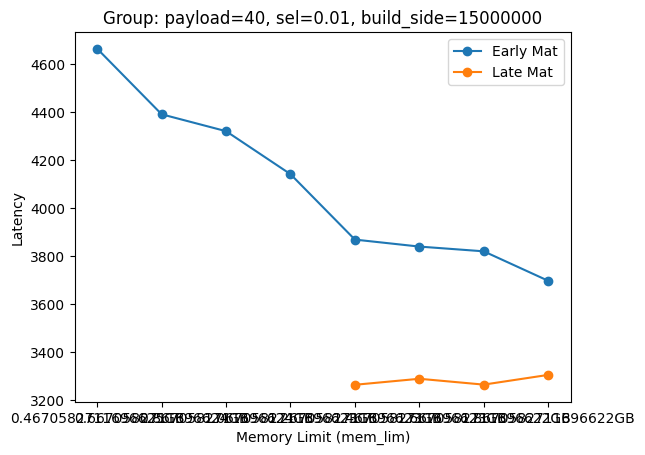

Group: payload=40, sel=0.1, build_side=1000000


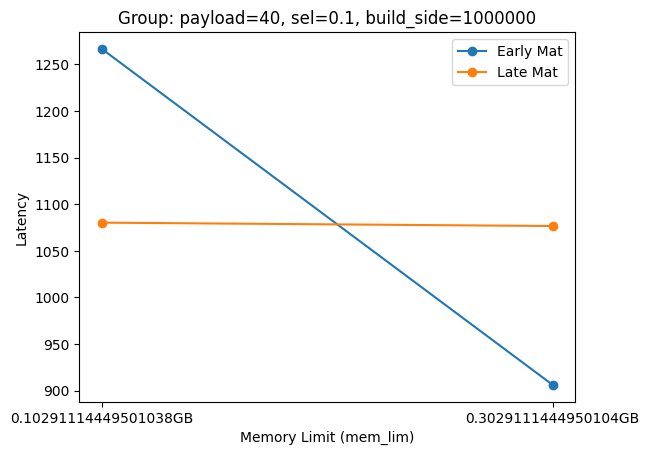

Group: payload=40, sel=0.1, build_side=10000000


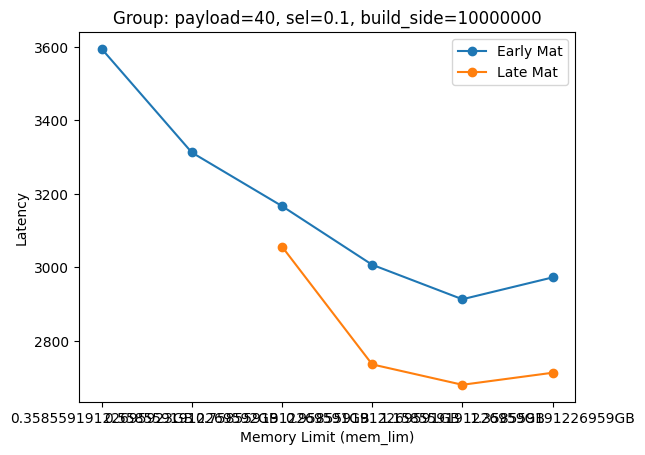

Group: payload=40, sel=0.1, build_side=15000000


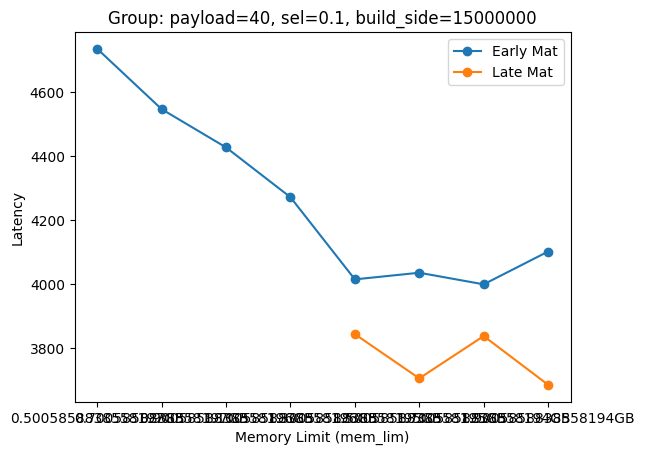

Group: payload=40, sel=0.2, build_side=1000000


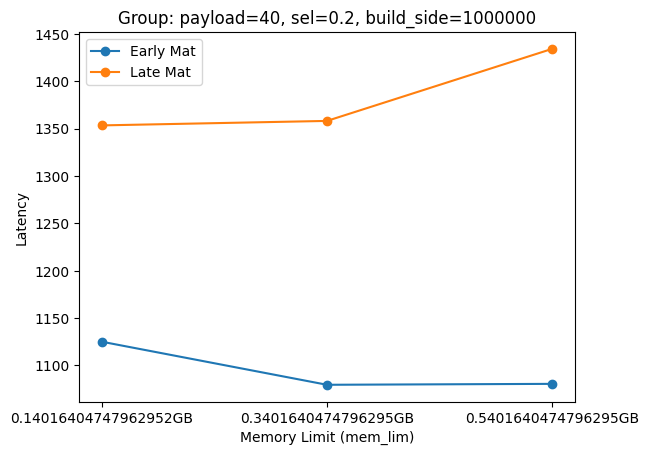

Group: payload=40, sel=0.2, build_side=10000000


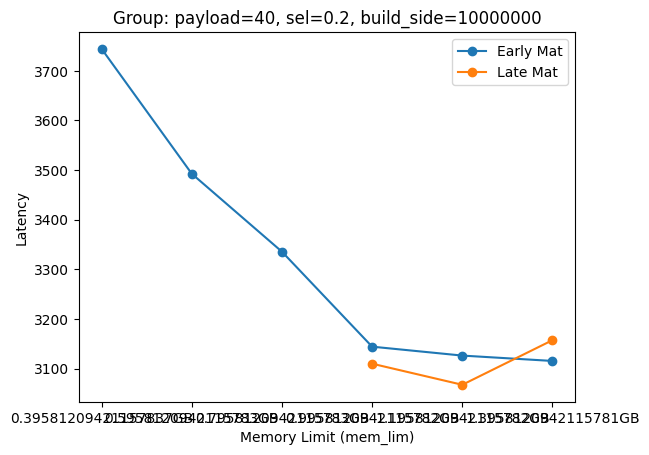

Group: payload=40, sel=0.2, build_side=15000000


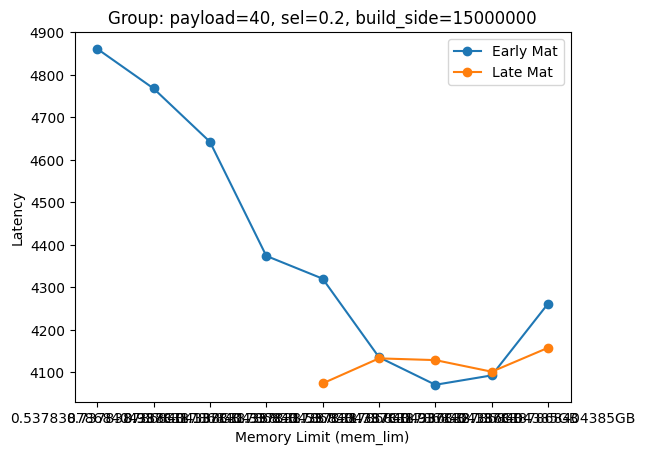

Group: payload=100, sel=0.001, build_side=1000000


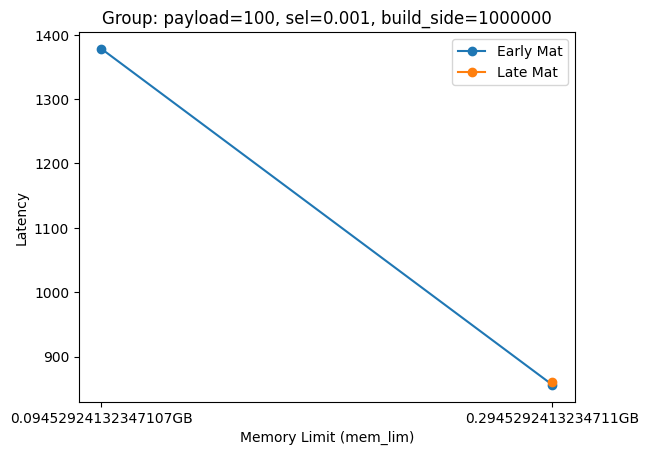

Group: payload=100, sel=0.001, build_side=10000000


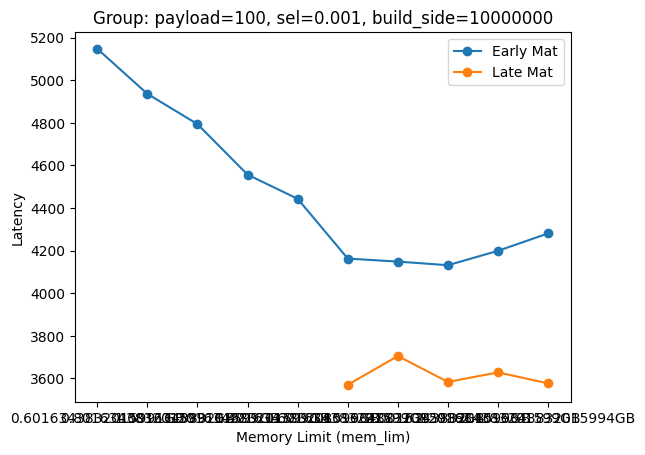

Group: payload=100, sel=0.001, build_side=15000000


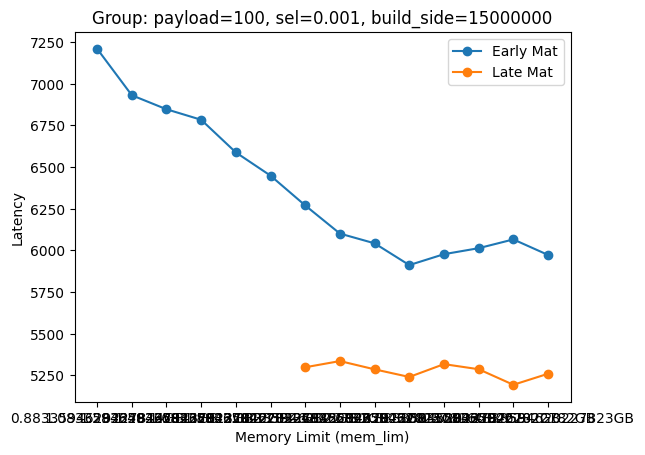

Group: payload=100, sel=0.01, build_side=1000000


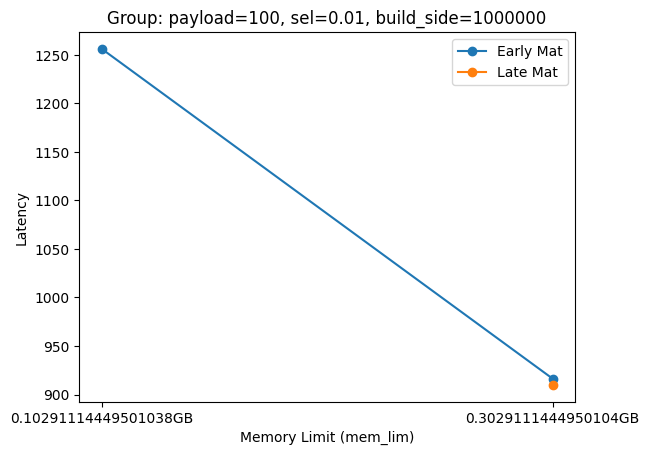

Group: payload=100, sel=0.01, build_side=10000000


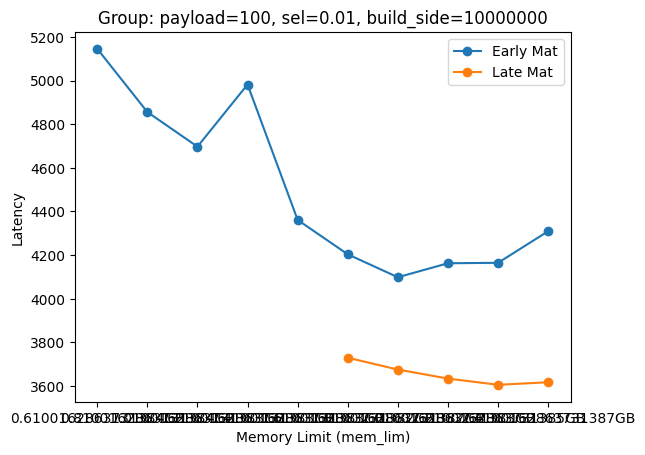

Group: payload=100, sel=0.01, build_side=15000000


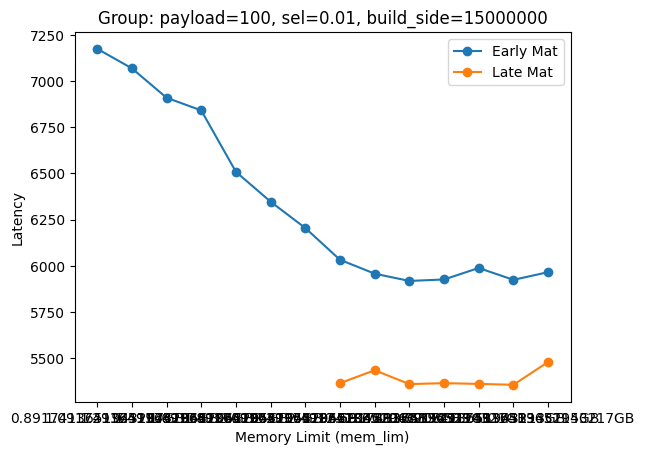

Group: payload=100, sel=0.1, build_side=1000000


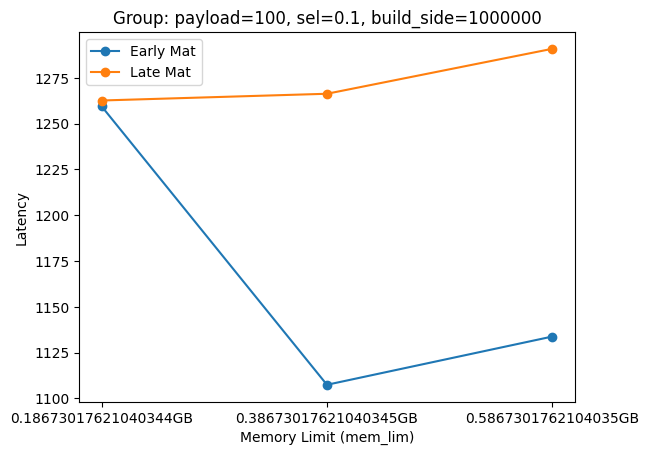

Group: payload=100, sel=0.1, build_side=10000000


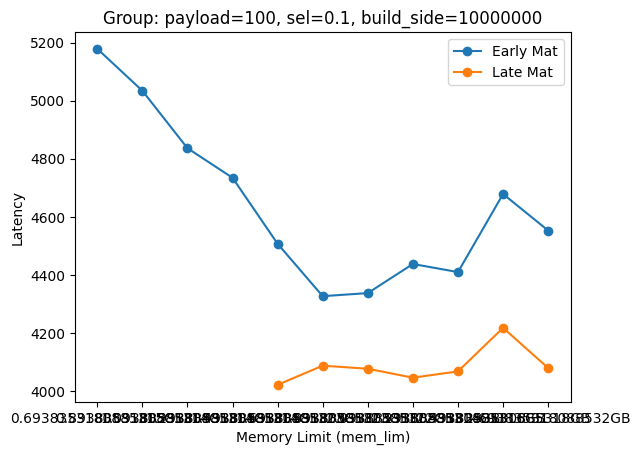

Group: payload=100, sel=0.1, build_side=15000000


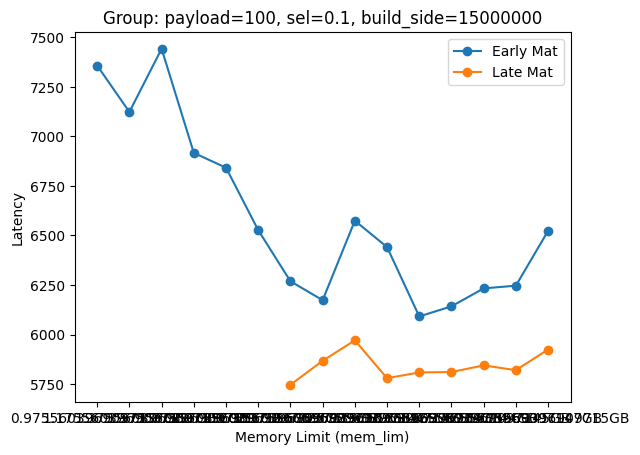

Group: payload=100, sel=0.2, build_side=1000000


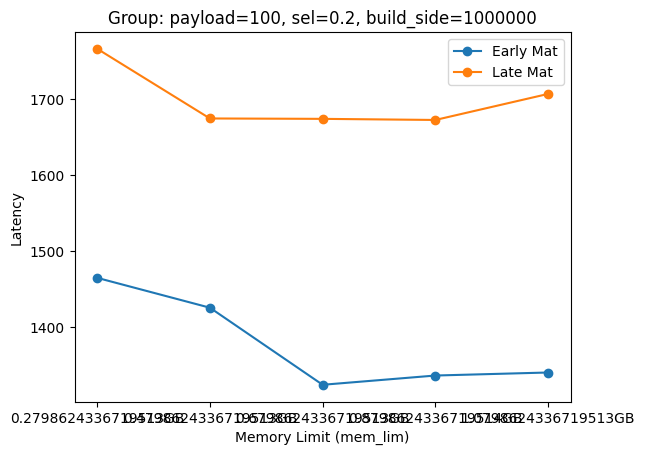

Group: payload=100, sel=0.2, build_side=10000000


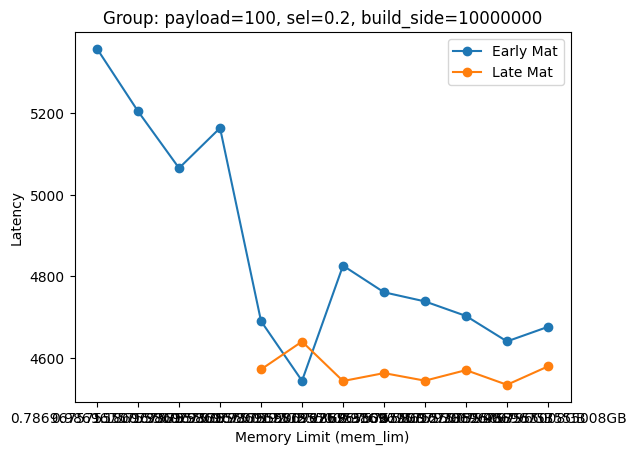

Group: payload=100, sel=0.2, build_side=15000000


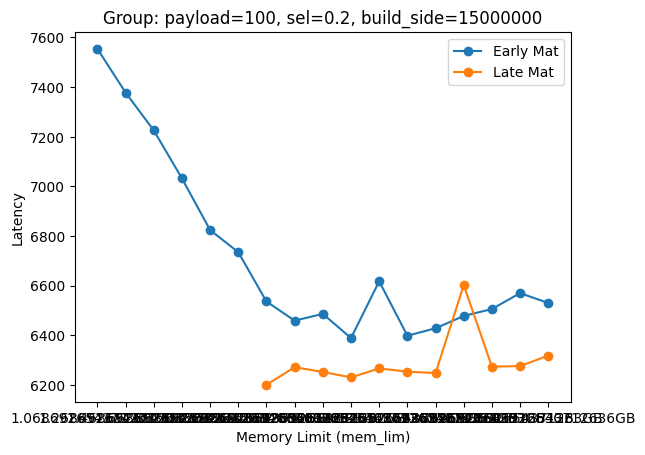

In [118]:
file_path = '/home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/run_oom.log' 
df = parse_file(file_path)
grouped = group_data(df)

for name, group in grouped:
    print(f"Group: payload={name[0]}, sel={name[1]}, build_side={name[2]}")
    plot_group( group,name)


In [17]:
columns = ["result_size", "mem_lim", "mode", "thread", "probe_side", "build_side", "sel", "payload", "dist", "hit_ratio", "build_dis", "probe_dis","mat_strat","queue_thr", "latency"]
ff = open('/home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/run_oom_skew.log','r')
lines = [l for l in ff.readlines()]
with open ('/home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/run_oom_skew_.log','w') as f:
    for l in lines:
        if "Segmentation" not in l:
            f.write(l)


df = pd.read_csv('/home/yihao/duckdb/ht/duckdb/examples/embedded-c++/release/run_oom_skew_.log',sep=' ',header=None, names=columns)

df = df[df['result_size']!=0]

In [42]:
grouped = df.groupby(["payload", "sel", "build_side"])

def plot_group(group, name):
    early_mat = group[group["mat_strat"] == 0]
    late_mat = group[group["mat_strat"] == 1].groupby(["mem_lim"]).agg({'latency': 'min'}).reset_index()
    
    plt.figure(figsize=(6,3))
    plt.plot(early_mat["mem_lim"], early_mat["latency"], label="Early Mat", marker='o')
    plt.plot(late_mat["mem_lim"], late_mat["latency"], label="Late Mat", marker='o')
    plt.xlabel("Memory Limit (mem_lim)")
    plt.ylabel("Latency")
    memory_limit = [float(mem[:-2]) for mem in early_mat["mem_lim"]]
    mem_str = [str(round(mem,2)) for mem in memory_limit]
    plt.xticks(np.arange(len(mem_str)),mem_str)
    plt.ylim([0,max(early_mat["latency"])+100])
    plt.title(f"Group: payload={name[0]}, sel={name[1]}, build_side={name[2]}")
    plt.legend()
    
    plt.show()

Group: payload=10.0, sel=0.0001, build_side=1000000.0


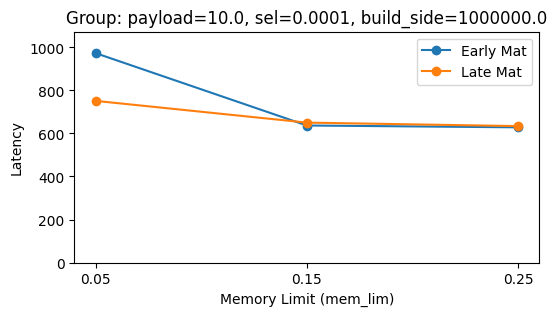

Group: payload=10.0, sel=0.0001, build_side=10000000.0


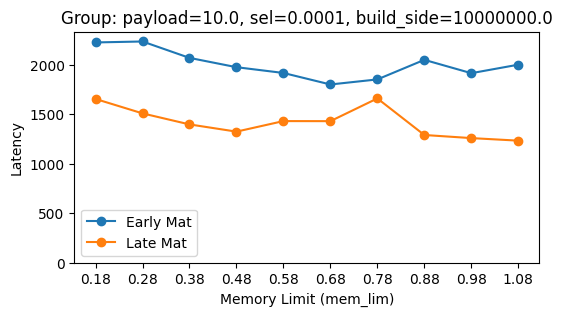

Group: payload=10.0, sel=0.0001, build_side=15000000.0


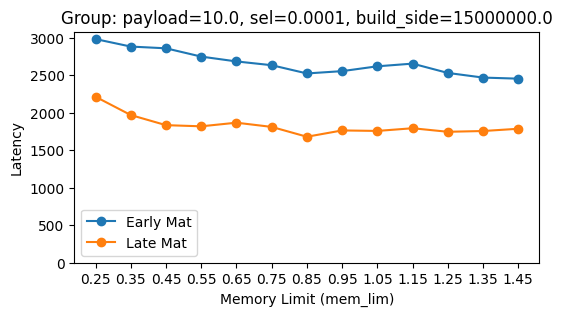

Group: payload=10.0, sel=0.0001, build_side=18000000.0


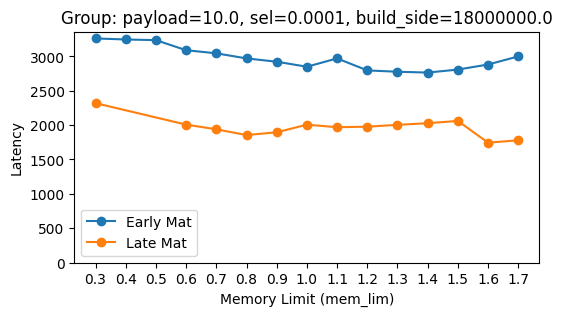

Group: payload=10.0, sel=0.001, build_side=1000000.0


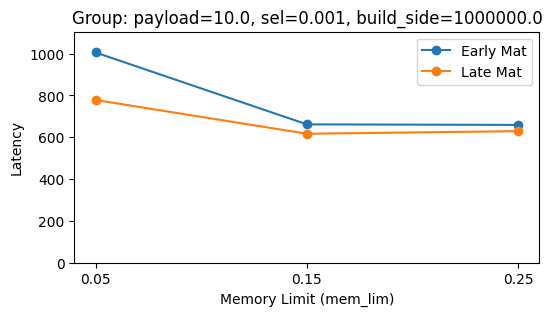

Group: payload=10.0, sel=0.001, build_side=10000000.0


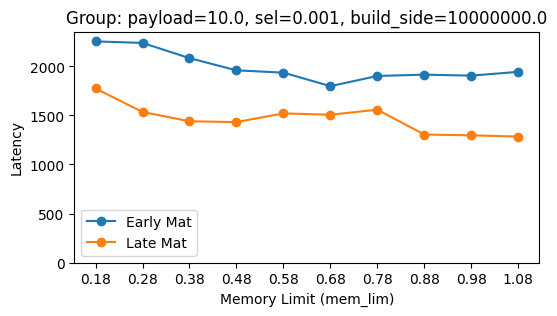

Group: payload=10.0, sel=0.001, build_side=15000000.0


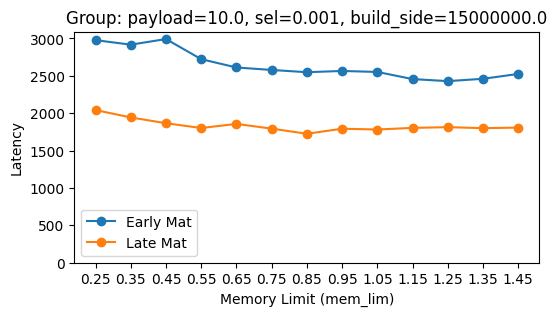

Group: payload=10.0, sel=0.001, build_side=18000000.0


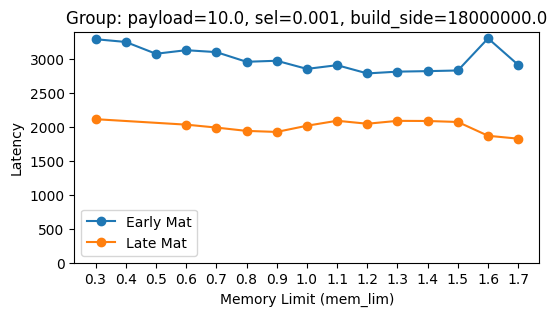

Group: payload=10.0, sel=0.01, build_side=1000000.0


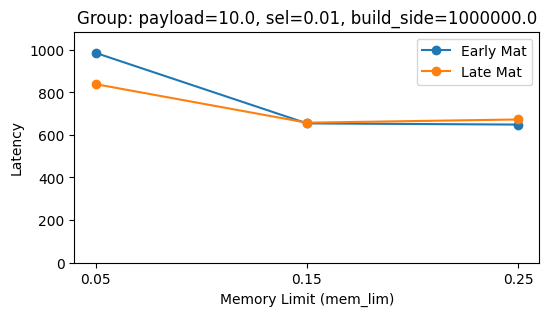

Group: payload=10.0, sel=0.01, build_side=10000000.0


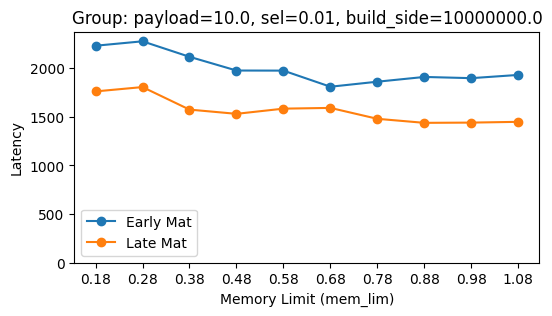

Group: payload=10.0, sel=0.01, build_side=15000000.0


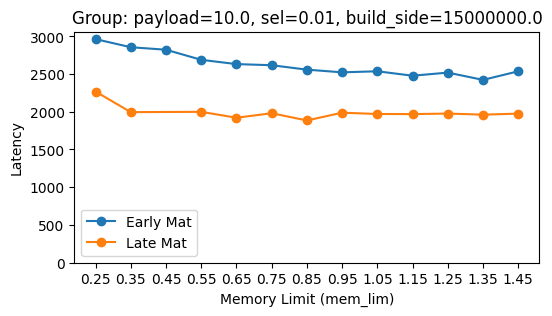

Group: payload=10.0, sel=0.01, build_side=18000000.0


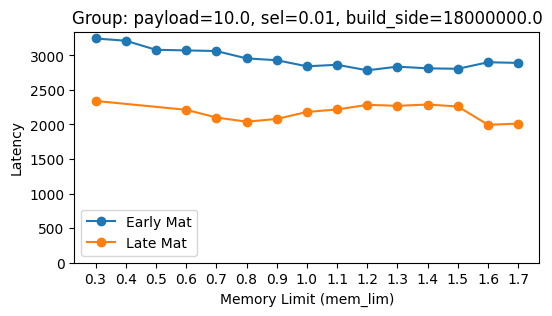

Group: payload=10.0, sel=0.1, build_side=1000000.0


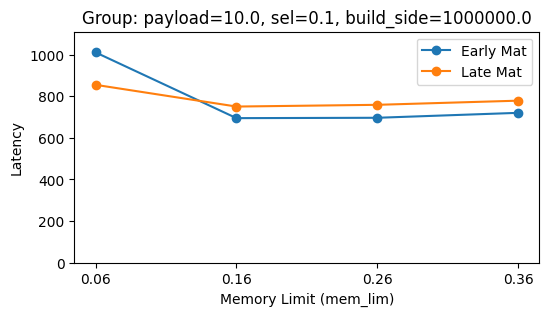

Group: payload=10.0, sel=0.1, build_side=10000000.0


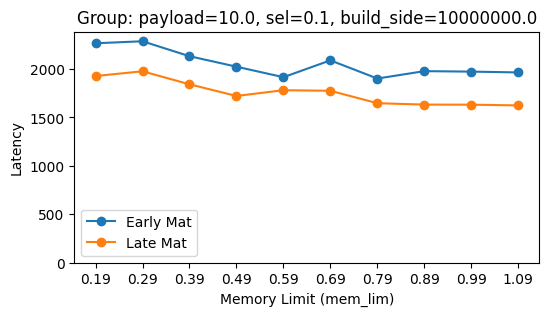

Group: payload=10.0, sel=0.1, build_side=15000000.0


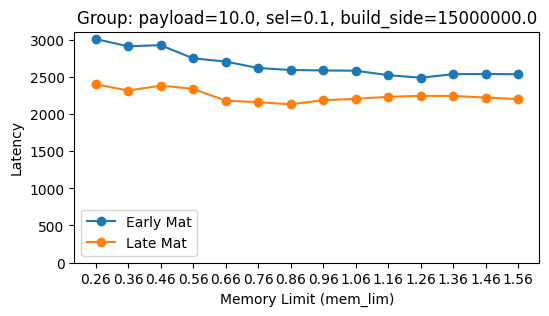

Group: payload=10.0, sel=0.1, build_side=18000000.0


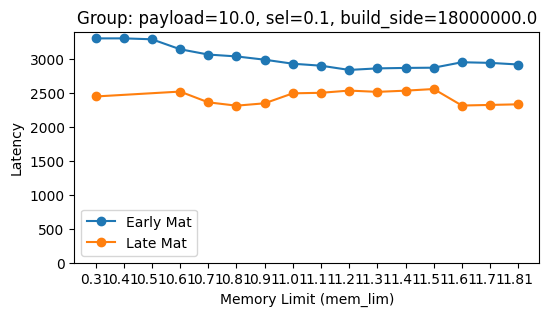

Group: payload=10.0, sel=0.2, build_side=1000000.0


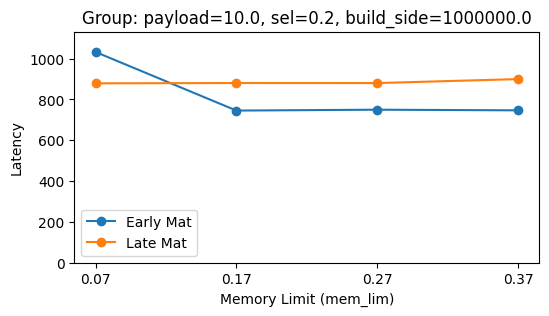

Group: payload=10.0, sel=0.2, build_side=10000000.0


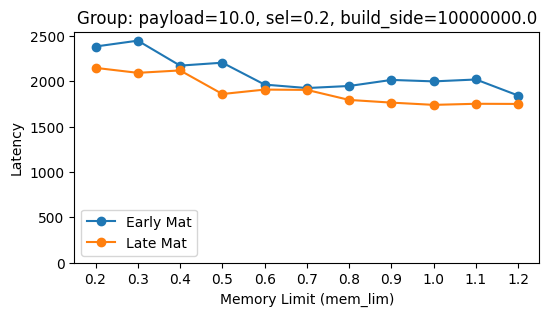

Group: payload=10.0, sel=0.2, build_side=15000000.0


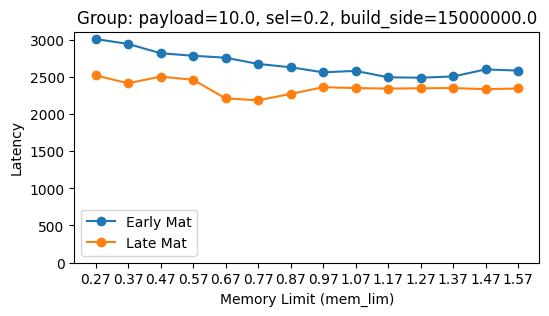

Group: payload=10.0, sel=0.2, build_side=18000000.0


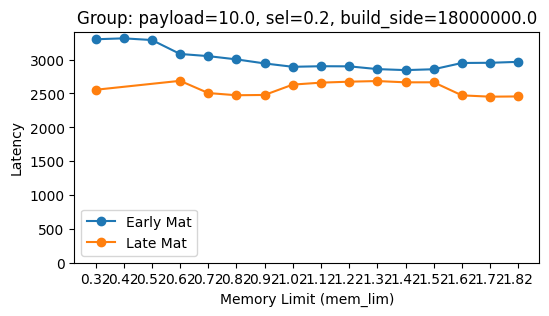

Group: payload=20.0, sel=0.0001, build_side=1000000.0


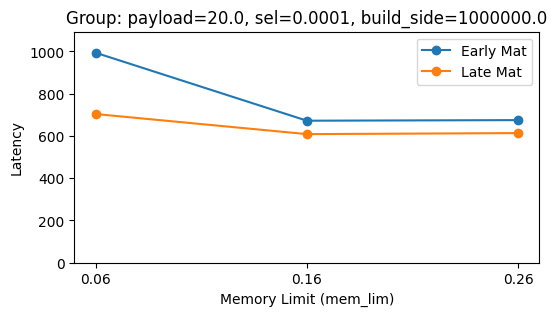

Group: payload=20.0, sel=0.0001, build_side=10000000.0


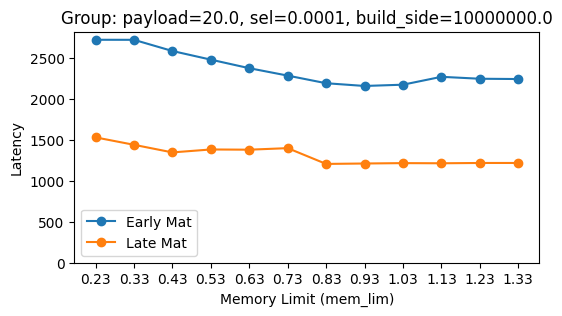

Group: payload=20.0, sel=0.0001, build_side=15000000.0


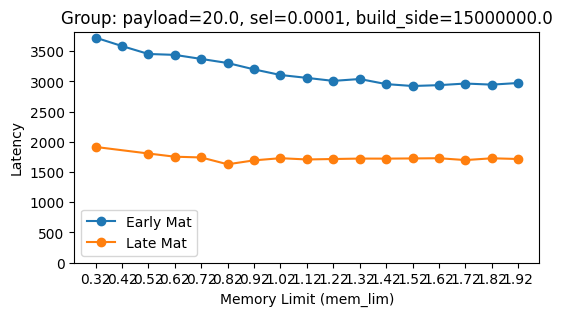

Group: payload=20.0, sel=0.0001, build_side=18000000.0


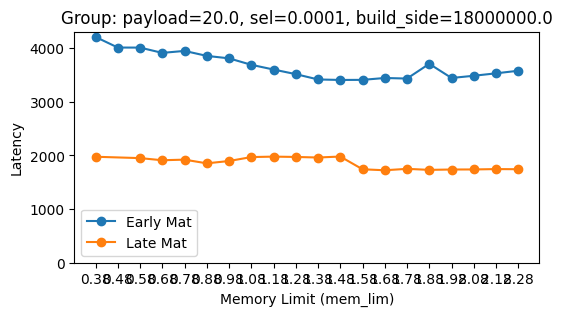

Group: payload=20.0, sel=0.001, build_side=1000000.0


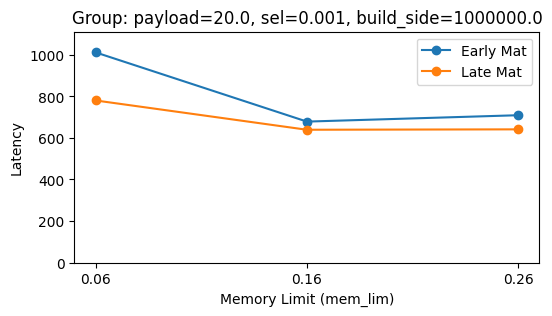

Group: payload=20.0, sel=0.001, build_side=10000000.0


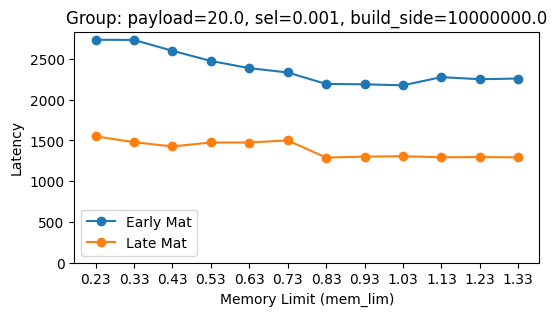

Group: payload=20.0, sel=0.001, build_side=15000000.0


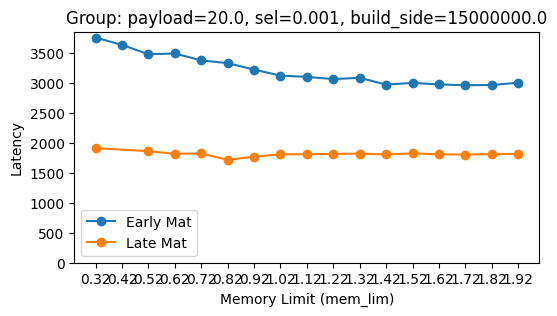

Group: payload=20.0, sel=0.001, build_side=18000000.0


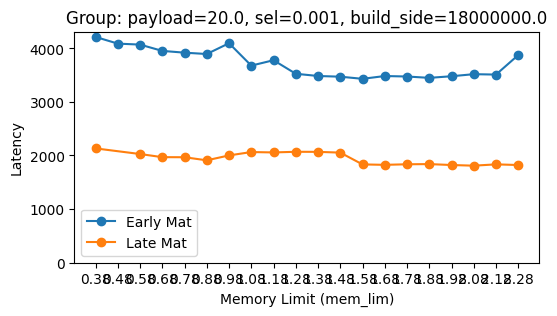

Group: payload=20.0, sel=0.01, build_side=1000000.0


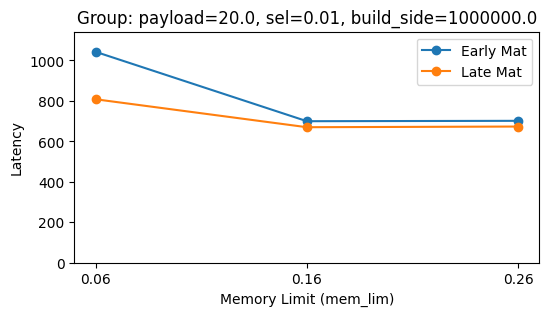

Group: payload=20.0, sel=0.01, build_side=10000000.0


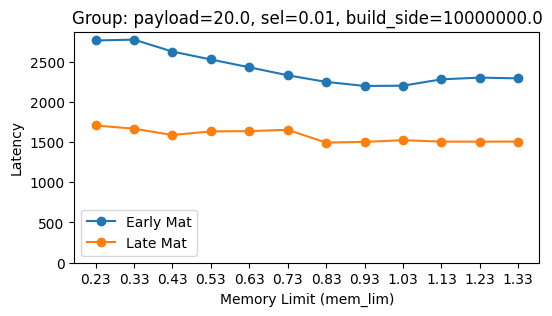

Group: payload=20.0, sel=0.01, build_side=15000000.0


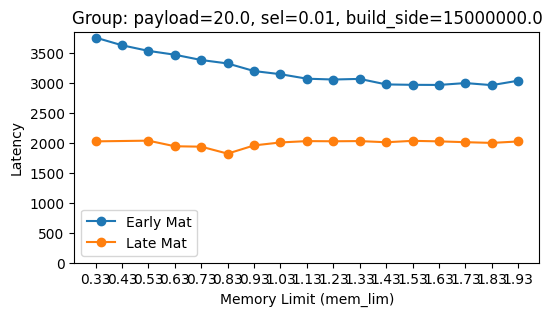

Group: payload=20.0, sel=0.01, build_side=18000000.0


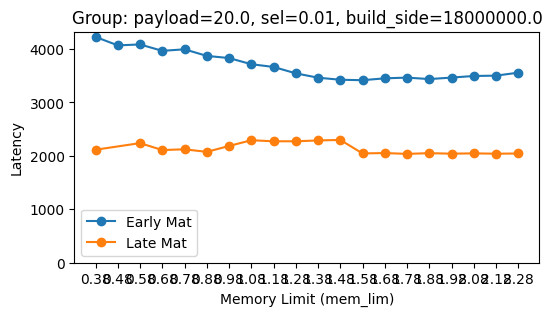

Group: payload=20.0, sel=0.1, build_side=1000000.0


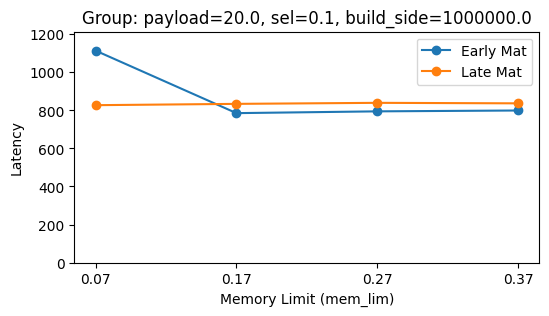

Group: payload=20.0, sel=0.1, build_side=10000000.0


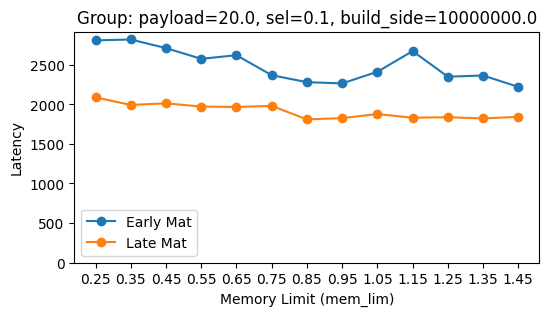

Group: payload=20.0, sel=0.1, build_side=15000000.0


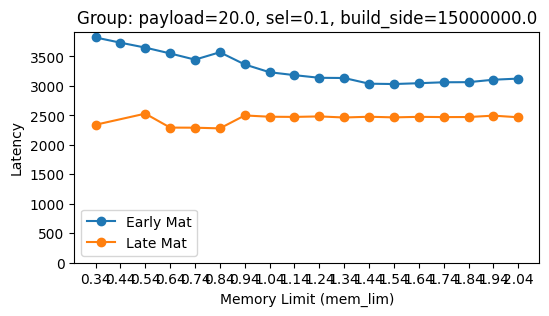

Group: payload=20.0, sel=0.1, build_side=18000000.0


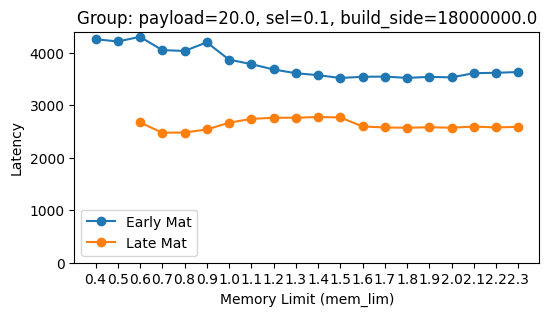

Group: payload=20.0, sel=0.2, build_side=1000000.0


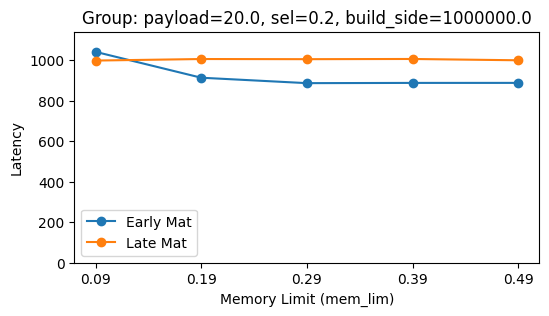

Group: payload=20.0, sel=0.2, build_side=10000000.0


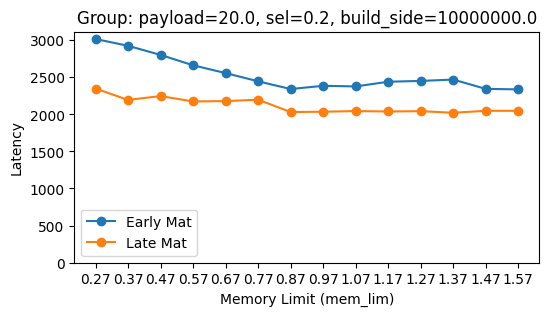

Group: payload=20.0, sel=0.2, build_side=15000000.0


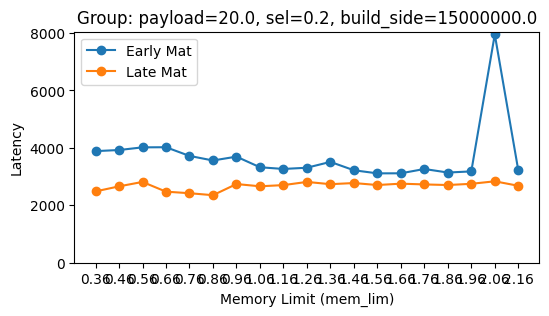

Group: payload=20.0, sel=0.2, build_side=18000000.0


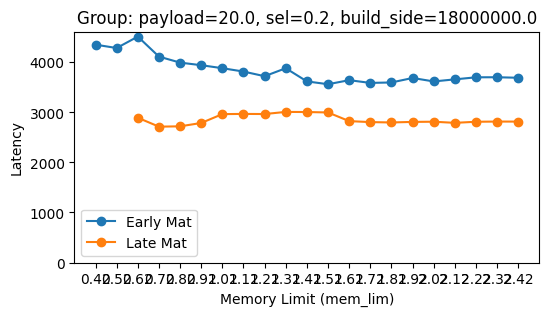

Group: payload=40.0, sel=0.0001, build_side=1000000.0


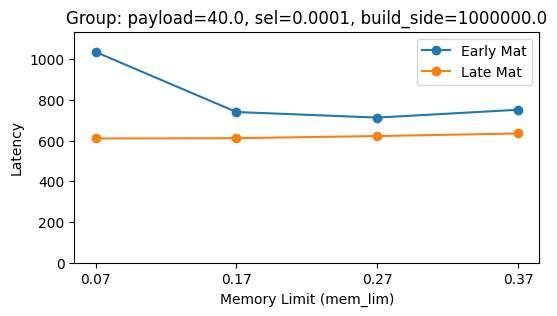

Group: payload=40.0, sel=0.0001, build_side=10000000.0


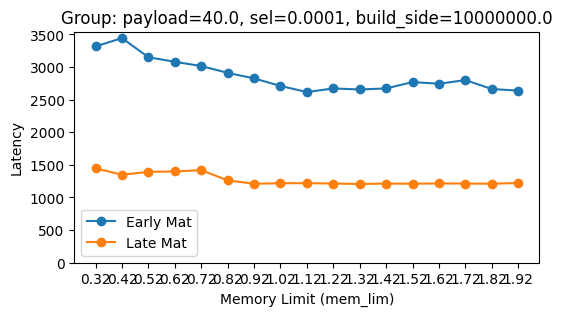

Group: payload=40.0, sel=0.0001, build_side=15000000.0


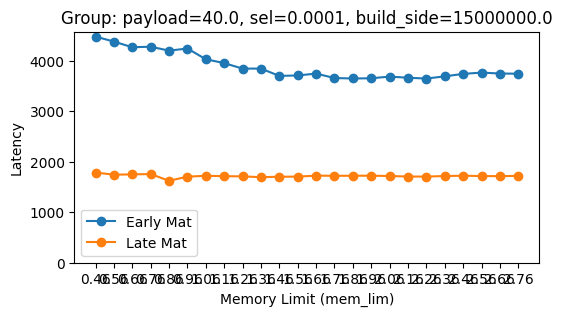

Group: payload=40.0, sel=0.0001, build_side=18000000.0


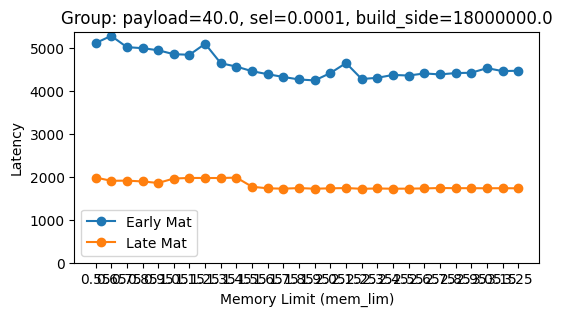

Group: payload=40.0, sel=0.001, build_side=1000000.0


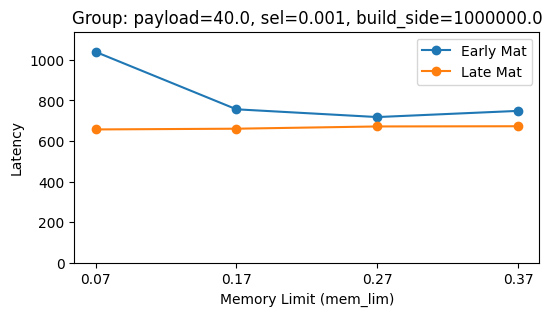

Group: payload=40.0, sel=0.001, build_side=10000000.0


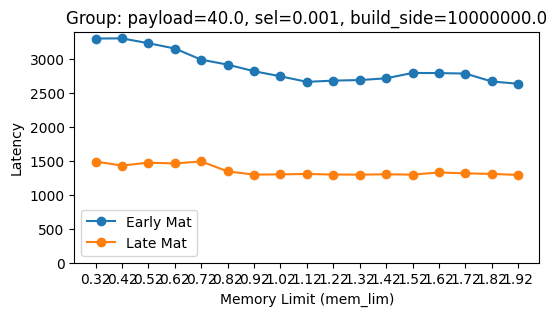

Group: payload=40.0, sel=0.001, build_side=15000000.0


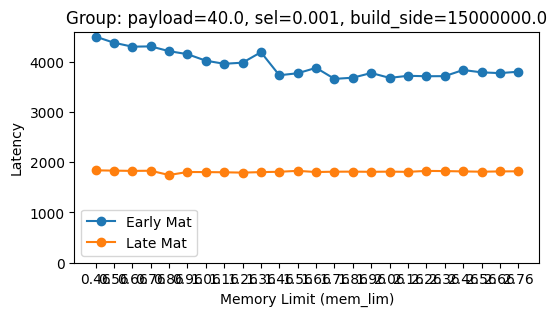

Group: payload=40.0, sel=0.001, build_side=18000000.0


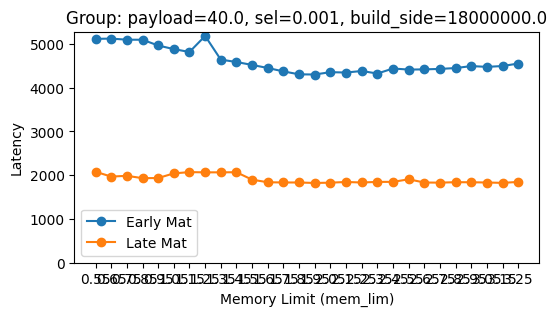

Group: payload=40.0, sel=0.01, build_side=1000000.0


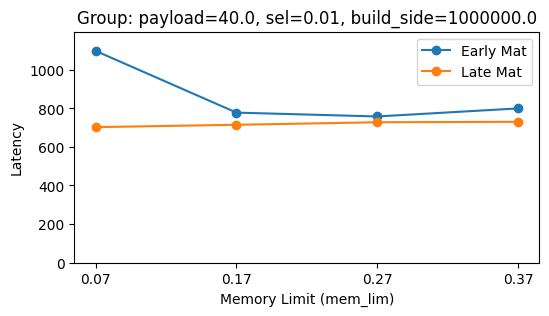

Group: payload=40.0, sel=0.01, build_side=10000000.0


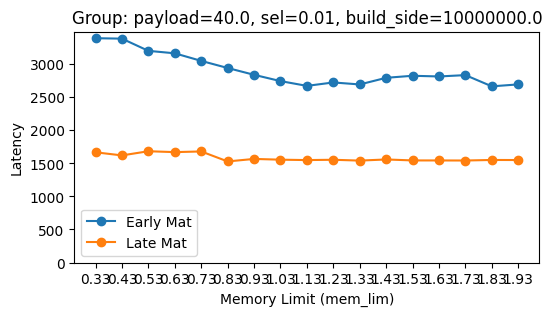

Group: payload=40.0, sel=0.01, build_side=15000000.0


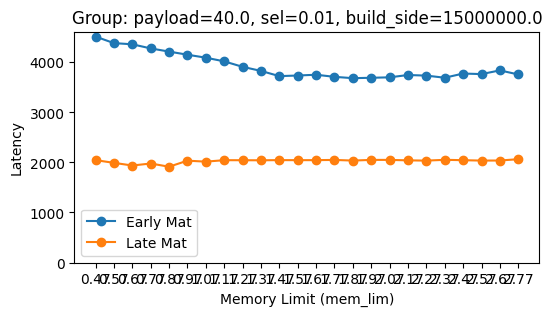

Group: payload=40.0, sel=0.01, build_side=18000000.0


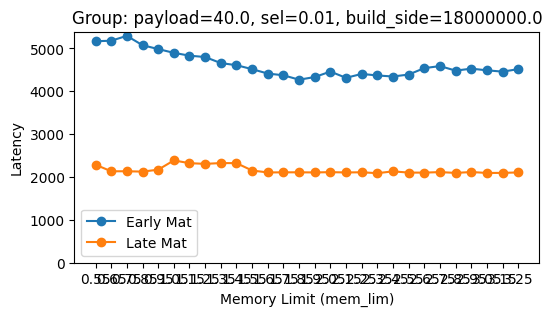

Group: payload=40.0, sel=0.1, build_side=1000000.0


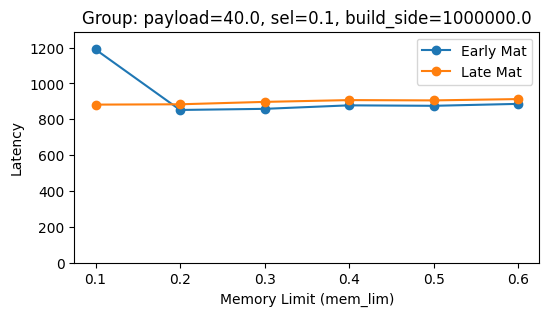

Group: payload=40.0, sel=0.1, build_side=10000000.0


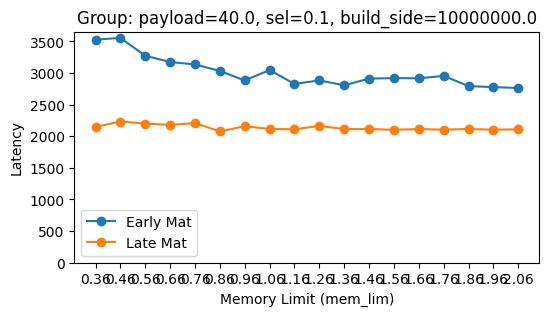

Group: payload=40.0, sel=0.1, build_side=15000000.0


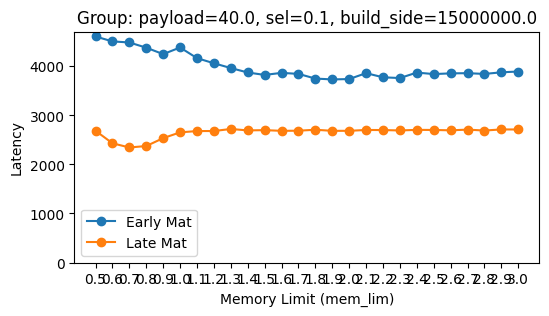

Group: payload=40.0, sel=0.1, build_side=18000000.0


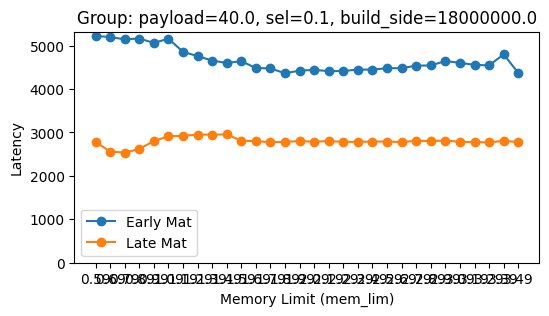

Group: payload=40.0, sel=0.2, build_side=1000000.0


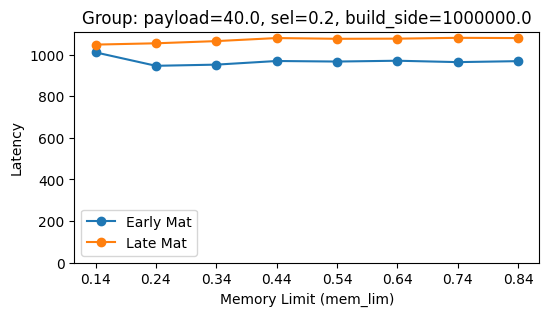

Group: payload=40.0, sel=0.2, build_side=10000000.0


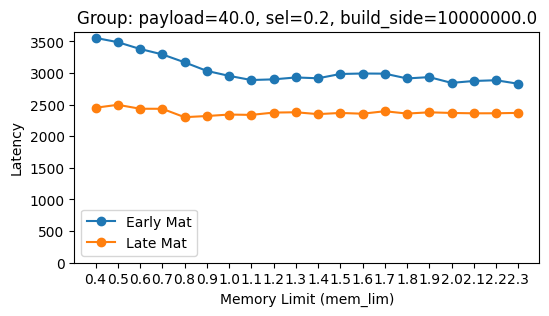

Group: payload=40.0, sel=0.2, build_side=15000000.0


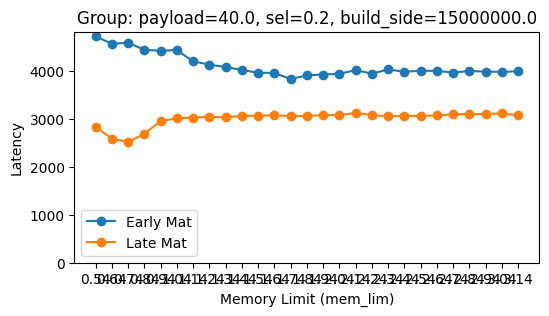

Group: payload=40.0, sel=0.2, build_side=18000000.0


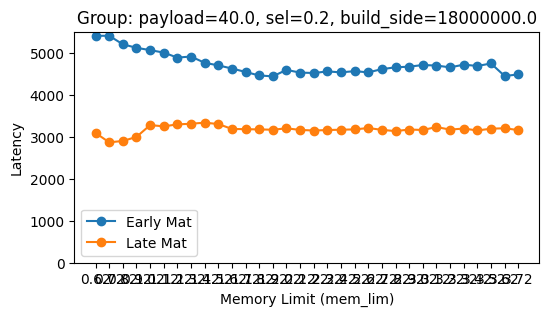

Group: payload=100.0, sel=0.0001, build_side=1000000.0


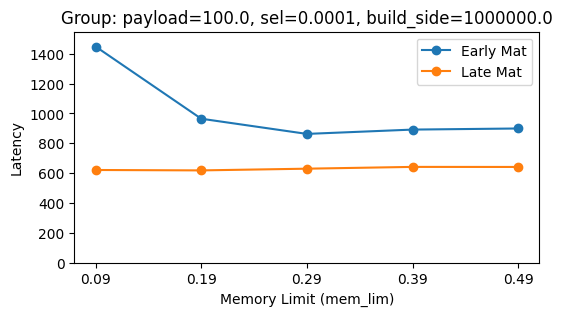

Group: payload=100.0, sel=0.0001, build_side=10000000.0


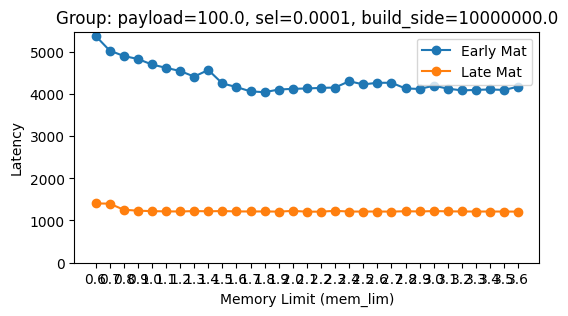

Group: payload=100.0, sel=0.0001, build_side=15000000.0


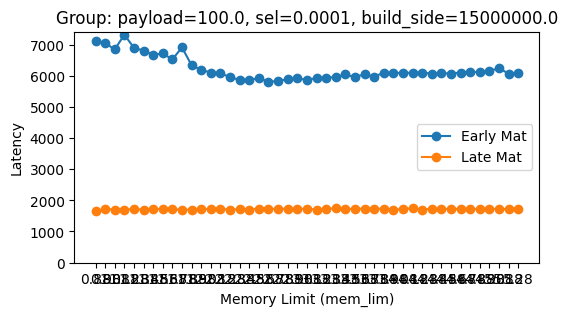

Group: payload=100.0, sel=0.0001, build_side=18000000.0


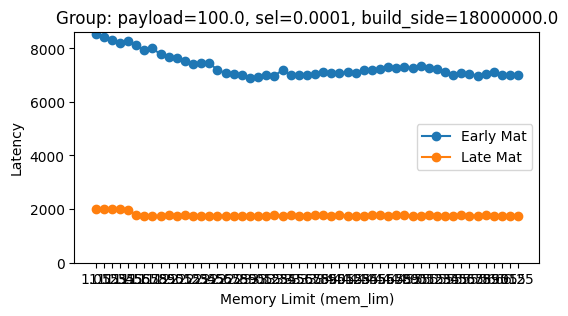

Group: payload=100.0, sel=0.001, build_side=1000000.0


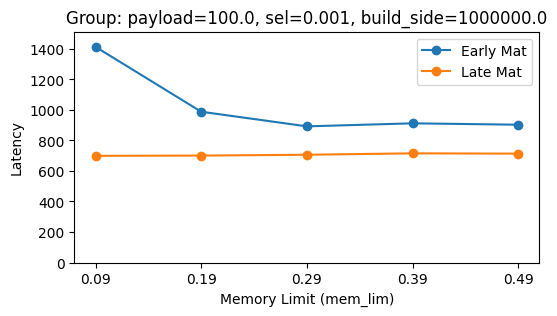

Group: payload=100.0, sel=0.001, build_side=10000000.0


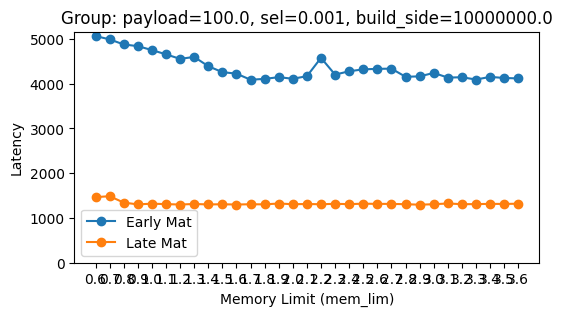

Group: payload=100.0, sel=0.001, build_side=15000000.0


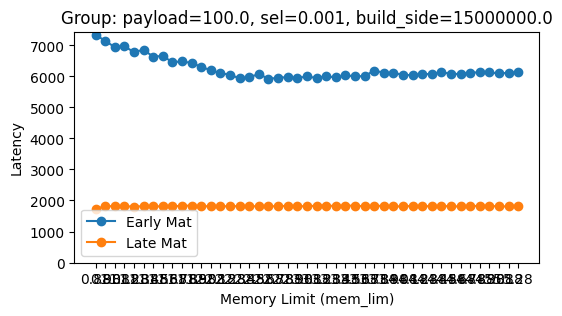

Group: payload=100.0, sel=0.001, build_side=18000000.0


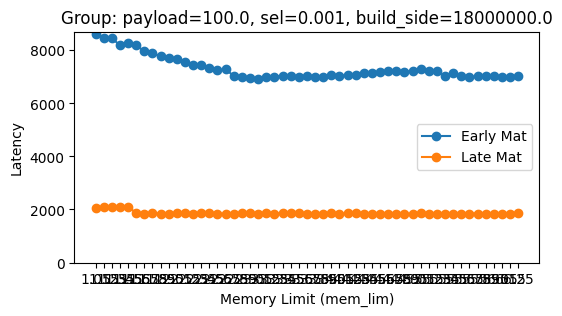

Group: payload=100.0, sel=0.01, build_side=1000000.0


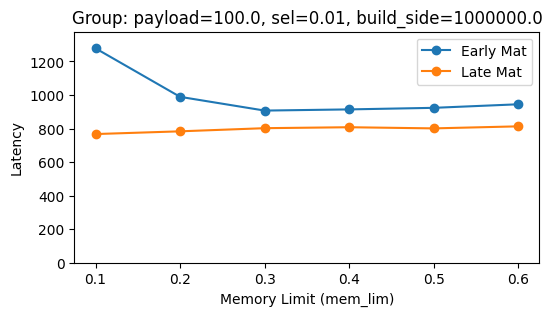

Group: payload=100.0, sel=0.01, build_side=10000000.0


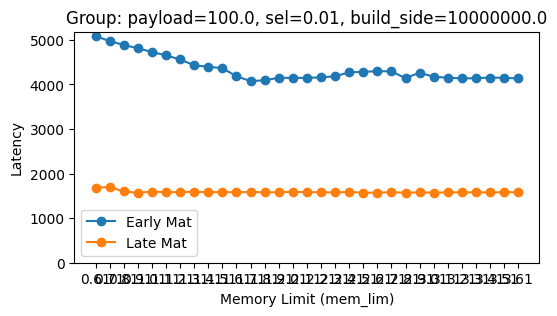

Group: payload=100.0, sel=0.01, build_side=15000000.0


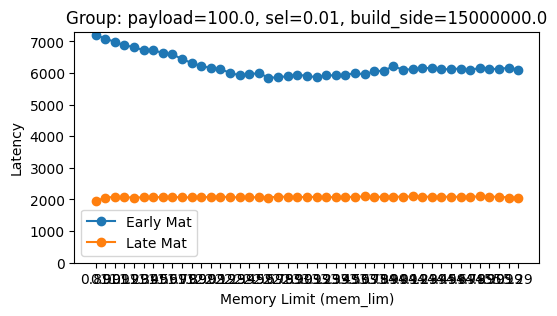

Group: payload=100.0, sel=0.01, build_side=18000000.0


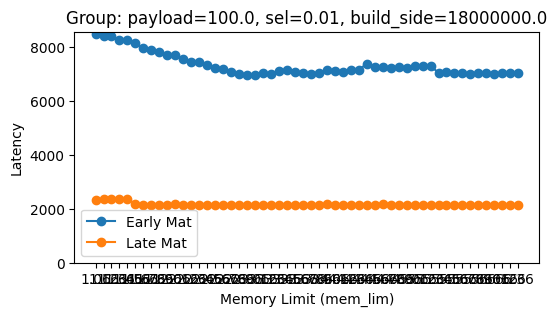

Group: payload=100.0, sel=0.1, build_side=1000000.0


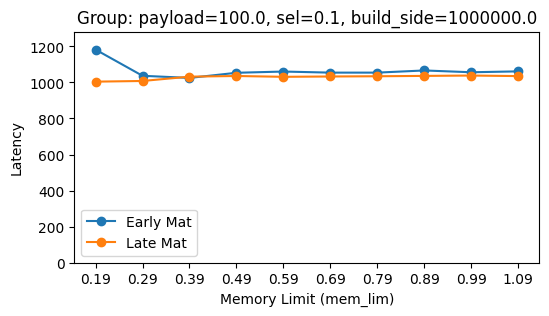

Group: payload=100.0, sel=0.1, build_side=10000000.0


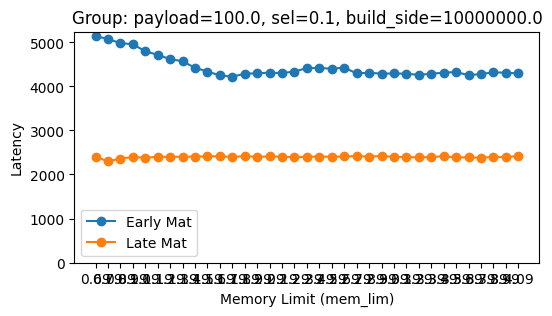

Group: payload=100.0, sel=0.1, build_side=15000000.0


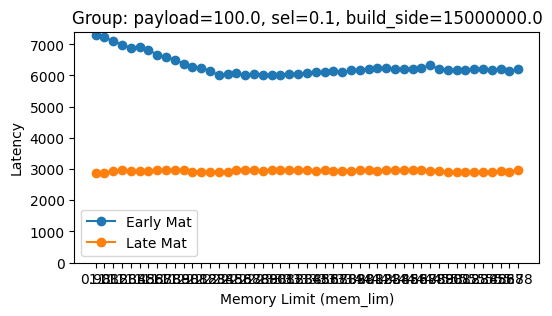

Group: payload=100.0, sel=0.1, build_side=18000000.0


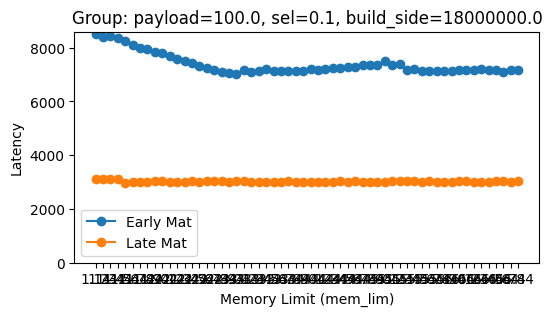

Group: payload=100.0, sel=0.2, build_side=1000000.0


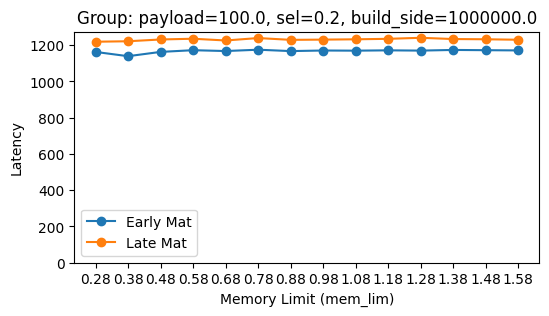

Group: payload=100.0, sel=0.2, build_side=10000000.0


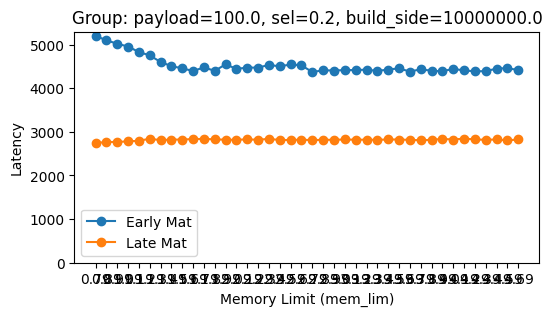

Group: payload=100.0, sel=0.2, build_side=15000000.0


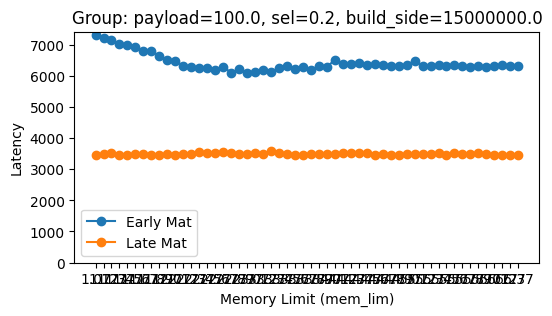

Group: payload=100.0, sel=0.2, build_side=18000000.0


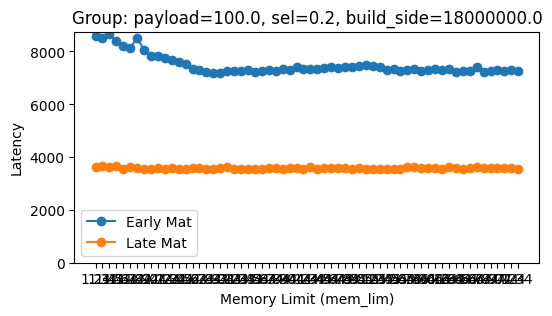

In [43]:
for name, group in grouped:
    print(f"Group: payload={name[0]}, sel={name[1]}, build_side={name[2]}")
    plot_group( group,name)
